In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import math
import datetime
import unicodedata
import warnings
import re
import missingno as msno 
import plotly.express as px
import json
import os
warnings.filterwarnings("ignore")
from clasificacion import *

#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
# carga de datos
#df = pd.read_excel("drive/MyDrive/Recorvet/Enfermedades en formulas.xlsx")

# carga de datos
df = pd.read_excel("Enfermedades en formulas.xlsx")

df.head(5)

,id,id.1,nombre,observacion,pronostico,recomendacion,fecha_ingreso,fecha_atencion,enfermedad,Unnamed: 9,Unnamed: 10
0,2,1,Bull Terrier,NaN,OK,OK,2018-09-07 19:50:41,2018-09-07 00:00:00,Gastritis,NaT,NaT
1,4,3,Schnauzer,gdfgd,NaN,NaN,2018-09-13 12:45:00,2018-09-14 12:45:00,Moquillo,NaT,NaT
2,5,NaN,Criollo o Mestizo,presenta adceso en la region craneal,bueno,limpieza de la herida,2018-09-13 15:50:00,2018-09-13 15:50:00,Absceso,NaT,NaT
3,6,NaN,Shih Tzu,NaN,BUENO,Administrar después de haber comido,2018-09-14 15:27:43,2018-09-14 15:27:43,Infección De Vias Urinarias Bajas,NaT,NaT
4,7,4,Schnauzer,fdgdfg,NaN,NaN,2018-09-21 11:03:00,2018-09-22 11:03:00,Leptospirosis,NaT,NaT


In [3]:
#eliminamos columnas que no aportan nada al modelo
df.drop(columns=["id", "id.1", "Unnamed: 9","Unnamed: 10"], inplace=True)

In [4]:
df.shape

(26890, 7)

In [5]:
df.describe()

,nombre,observacion,pronostico,recomendacion,fecha_ingreso,fecha_atencion,enfermedad
count,26877,11119,14744,26568,26862,26862,26747
unique,190,9945,774,23477,26447,26382,6343
top,Criollo o Mestizo,...,Reservado,.,2018-09-28 12:42:13,2018-09-28 12:42:13,Hemoparásitos
freq,10875,98,2187,192,64,64,453


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26890 entries, 0 to 26889
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   nombre          26877 non-null  object
 1   observacion     11119 non-null  object
 2   pronostico      14744 non-null  object
 3   recomendacion   26568 non-null  object
 4   fecha_ingreso   26862 non-null  object
 5   fecha_atencion  26862 non-null  object
 6   enfermedad      26747 non-null  object
dtypes: object(7)
memory usage: 1.4+ MB


In [7]:
# El objetivo es revisar cada columna del DataFrame (df) y mostrar el nombre de las variables junto con todos los valores únicos que contiene.

for i in df.columns:
    print(i)
    print(df[i].unique())

nombre
['Bull Terrier' 'Schnauzer' 'Criollo o Mestizo' 'Shih Tzu' 'Beagle'
 'Mastín' 'Labrador Retriever' 'American Pitbull Terrier' 'Pastor Alemán'
 'Común Europeo' 'Mini Pig' 'Samoyedo' 'Dachshund' 'Bichón Maltés'
 'Pinscher' 'Fila Brasileiro' 'Pug' 'Cornish Rex' 'Akita Inu'
 'Boston Terrier' 'Golden Retriever' 'American Bully' 'Bulldog francés'
 'Akita' 'Schnauzer Miniatura' 'Angora Turco' 'Rottweiler'
 'Bulldog Americano' 'Cocker Spaniel' 'American Shorthair'
 'Caniche (Poodle)' 'French Poodle' 'Balines' 'Poodle'
 'Braco Francés de Tipo Pirineos' 'Bulldog Inglés' 'Schnauzer Gigante'
 'Persa' 'Bengalí' 'Husky Siberiano' 'Cocker Spaniel Americano'
 'Pinscher miniatura' 'Azul Ruso' 'Bulldog' 'Siames Tradicional'
 'West Highland' 'Chihuahua' 'Yorkshire Terrier' 'Doberman'
 'Jack Russell Terrier' 'Basset Hound' 'Springer' 'Shar Pei'
 'Springer Spaniel Inglés' 'Abisinio' 'Pomerania' 'Pastor Belga'
 'Akita Americano' 'Exotic Shorthair' 'Galgo Italiano' 'Alano Español'
 'Chartreux' 'Dogo A

In [8]:
#list(df["nombre"].unique())

Normalización y estandarización variable "nombre"
Esta variable contiene las especies y razas de los animales, la idea es normalizar y estandarizar para luego sacar una variable llamada
"especie" y otra "raza" de la especie de más frecuencia

In [9]:
# --- 1. Función de Normalización (Mejorada con Regex)
def normalize_for_comparison(name_str):
    """Normaliza una cadena para la comparación (minúsculas, sin acentos, limpia espacios)."""
    if not isinstance(name_str, str):
        return None
        
    processed_name = name_str.lower()
    
    # Paso 1: Reemplazar caracteres especiales y acentos
    processed_name = processed_name.replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    processed_name = processed_name.replace('ñ', 'n')
    processed_name = processed_name.replace('–', '-').replace('(', '').replace(')', '').replace('®', '')
    
    # Paso 2: Usar Regex para manejar todos los tipos de espacios en blanco (incluyendo \xa0)
    # \s+ coincide con uno o más caracteres de espacio en blanco.
    processed_name = re.sub(r'\s+', ' ', processed_name).strip()
    
    return processed_name

# --- 2. Función Integrada de Extracción
def extraer_info_integrada(original_entry):
    """
    Toma el valor original de 'nombre' y devuelve una tupla (especie, raza).
    """
    
    # --- Validación y Normalización ---
 
    if original_entry is None or (isinstance(original_entry, float) and math.isnan(original_entry)):
        return (None, None) 
    
    if not isinstance(original_entry, str):
        return (None, None)

    processed_original = normalize_for_comparison(original_entry)

    # --- Entradas no relacionadas con mascotas / irrelevantes ---
    irrelevant_keywords = ["toma de examen", "dieta", "cuidados pos operatorios", "atomizador", "ingiera pasto", "espalda"]
    if any(keyword in processed_original for keyword in irrelevant_keywords):
        return (None, None)

    # --- Otros animales ---
    if processed_original == "caballo criollo": return ("Caballo", None)
    elif processed_original == "conejo": return ("Conejo", None)
    elif processed_original == "huron": return ("Hurón", None)
    elif processed_original == "aves": return ("Aves", None)
    elif processed_original == "tortuga": return ("Tortuga", None)
    elif processed_original == "cobayo": return ("Cobayo", None)
    elif processed_original == "hamster": return ("Hámster", None)
    elif processed_original == "erizo": return ("Erizo", None)
    elif processed_original == "mini pig": return ("Mini Pig", None)

    # --- Razas de Perros (Devuelve "Perro" y la Raza Canónica) ---
    
    elif "Alano Español" in processed_original: return ("Perro", "Alano Español")
    elif processed_original in ["beagle harrier", "beagle – harrier"]: return ("Perro", "Beagle-Harrier")
    elif processed_original in ["pug", "carlino"]: return ("Perro", "Pug (Carlino)")
    elif processed_original in ["perro de montana bernes", "boyero de berna"]: return ("Perro", "Boyero de Berna (Perro de Montaña Bernés)")
    elif processed_original == "cocker spaniel": return ("Perro", "Cocker Spaniel") # Nueva regla
    elif processed_original in ["cocker spaniel americano", "cocker americano"]: return ("Perro", "Cocker Spaniel Americano")
    elif processed_original == "beagle": return ("Perro", "Beagle") # Nueva regla
    elif processed_original in ["beagle-harrier", "beagle – harrier"]: return ("Perro", "Beagle-Harrier") # Nueva regla/ajuste
    elif processed_original in ["poodle", "caniche", "french poodle", "caniche poodle"]: return ("Perro", "Poodle (Caniche)") # Ajuste para "Caniche (Poodle)"
    elif processed_original == "basset hound": return ("Perro", "Basset Hound") # Nueva regla
    elif processed_original == "boxer": return ("Perro", "Bóxer") # Nueva regla
    elif processed_original in ["pequines", "pekines"]: return ("Perro", "Pekinés") # Ajuste de ortografía
    elif processed_original == "pastor de shetland": return ("Perro", "Pastor de Shetland") # Nueva regla
    elif processed_original == "australian silky terrier": return ("Perro", "Australian Silky Terrier") # Nueva regla
    elif processed_original == "bandog": return ("Perro", "Bandog") # Nueva regla
    elif processed_original == "cairn terrier": return ("Perro", "Cairn Terrier") # Nueva regla
    elif processed_original == "perro de pastor del caucaso": return ("Perro", "Pastor del Cáucaso") # Nueva regla
    elif processed_original == "american foxhound": return ("Perro", "American Foxhound") # Nueva regla
    
    elif processed_original == "american pitbull terrier": return ("Perro", "American Pitbull Terrier")
    elif processed_original == "american staffordshire terrier": return ("Perro", "American Staffordshire Terrier")
    elif processed_original == "bull terrier miniatura": return ("Perro", "Bull Terrier Miniatura")
    elif processed_original == "perro de montana bernes": return ("Perro", "Boyero de Berna (Perro de Montaña Bernés)")
    elif processed_original == "fox terrier de pelo duro": return ("Perro", "Fox Terrier de Pelo Duro")
    elif processed_original == "fox terrier de pelo liso": return ("Perro", "Fox Terrier de Pelo Liso")
    elif processed_original == "fox terrier toy": return ("Perro", "Fox Terrier Toy")
    elif processed_original == "pastor polaco de tierras bajas": return ("Perro", "Pastor Polaco de Tierras Bajas")
    elif processed_original in ["rhodesian ridgeback", "ridgeback de rodesia"]: return ("Perro", "Rhodesian Ridgeback")
    elif processed_original == "sabueso tricolor serbio": return ("Perro", "Sabueso Tricolor Serbio")
    elif "saluki" in processed_original: return ("Perro", "Saluki")
    elif processed_original == "spaniel continental enano": return ("Perro", "Spaniel Continental Enano")
    elif processed_original == "springer spaniel ingles": return ("Perro", "Springer Spaniel Inglés")
    elif processed_original == "springer spaniel gales": return ("Perro", "Springer Spaniel Galés")
    elif processed_original == "staffordshire bull terrier": return ("Perro", "Staffordshire Bull Terrier")
    elif processed_original == "terrier de airedale": return ("Perro", "Airedale Terrier")
    elif processed_original == "terrier cazador aleman": return ("Perro", "Terrier Cazador Alemán")
    elif processed_original == "basset azul de gascuna": return ("Perro", "Basset Azul de Gascuña")
    elif processed_original == "bichon bolones": return ("Perro", "Bichón Boloñés")
    elif processed_original == "bichon frise": return ("Perro", "Bichón Frisé")
    elif processed_original == "bichon habanero": return ("Perro", "Bichón Habanero")
    elif processed_original == "bichon maltes": return ("Perro", "Bichón Maltés")
    elif processed_original == "boyero australiano": return ("Perro", "Boyero Australiano")
    elif processed_original == "braco frances de tipo pirineos": return ("Perro", "Braco Francés de Tipo Pirineos")
    elif processed_original in ["braco de weimar", "weimaraner"]: return ("Perro", "Weimaraner (Braco de Weimar)")
    elif processed_original == "bullmastiff": return ("Perro", "Bullmastiff")
    elif processed_original in ["cavalier king charles", "cavalier king charles spaniel"]: return ("Perro", "Cavalier King Charles Spaniel")
    elif processed_original == "corgi gales pembroke": return ("Perro", "Corgi Galés Pembroke")
    elif processed_original == "coton de tulear": return ("Perro", "Coton de Tulear")
    elif processed_original in ["dachshund", "teckel"]: return ("Perro", "Dachshund (Teckel)")
    elif processed_original == "dogo argentino": return ("Perro", "Dogo Argentino")
    elif processed_original == "dogo de burdeos": return ("Perro", "Dogo de Burdeos")
    elif processed_original == "fila brasileiro": return ("Perro", "Fila Brasileiro")
    elif processed_original == "galgo italiano": return ("Perro", "Galgo Italiano")
    elif processed_original == "golden retriever": return ("Perro", "Golden Retriever")
    elif processed_original == "gran danes": return ("Perro", "Gran Danés")
    elif processed_original == "husky siberiano": return ("Perro", "Husky Siberiano")
    elif processed_original == "jack russell terrier": return ("Perro", "Jack Russell Terrier")
    elif processed_original == "labrador retriever": return ("Perro", "Labrador Retriever")
    elif processed_original == "mastin napolitano": return ("Perro", "Mastín Napolitano")
    elif processed_original == "pastor aleman": return ("Perro", "Pastor Alemán")
    elif processed_original == "pastor australiano": return ("Perro", "Pastor Australiano")
    elif processed_original == "pastor blanco suizo": return ("Perro", "Pastor Blanco Suizo")
    elif processed_original == "pastor catalan": return ("Perro", "Pastor Catalán")
    elif processed_original == "pastor del caucaso": return ("Perro", "Pastor del Cáucaso")
    elif processed_original == "pastor ganadero australiano": return ("Perro", "Pastor Ganadero Australiano")
    elif processed_original == "perro de pastor islandes": return ("Perro", "Pastor Islandés")
    elif processed_original == "perro pastor maremmano-abruzzese": return ("Perro", "Pastor Maremmano-Abruzzese")
    elif processed_original == "perro pastor mallorquin": return ("Perro", "Pastor Mallorquín")
    elif processed_original == "perro crestado chino": return ("Perro", "Perro Crestado Chino")
    elif processed_original == "perro sin pelo del peru": return ("Perro", "Perro sin Pelo del Perú")
    elif processed_original == "perro lobo checoslovaco": return ("Perro", "Perro Lobo Checoslovaco")
    elif processed_original == "pinscher miniatura": return ("Perro", "Pinscher Miniatura")
    elif processed_original == "pinscher austriaco": return ("Perro", "Pinscher Austríaco")
    elif processed_original == "pointer ingles": return ("Perro", "Pointer Inglés")
    elif processed_original == "pug": return ("Perro", "Pug (Carlino)")
    elif processed_original == "ratonero bodeguero andaluz": return ("Perro", "Ratonero Bodeguero Andaluz")
    elif processed_original == "sabueso artesiano": return ("Perro", "Sabueso Artesiano")
    elif processed_original == "sabueso austriaco": return ("Perro", "Sabueso Austríaco")
    elif processed_original == "san bernardo": return ("Perro", "San Bernardo")
    elif processed_original == "schnauzer miniatura": return ("Perro", "Schnauzer Miniatura")
    elif processed_original == "schnauzer gigante": return ("Perro", "Schnauzer Gigante")
    elif processed_original == "setter irlandes": return ("Perro", "Setter Irlandés")
    elif processed_original == "setter ingles": return ("Perro", "Setter Inglés")
    elif processed_original == "shih tzu": return ("Perro", "Shih Tzu")
    elif processed_original == "shiba inu": return ("Perro", "Shiba Inu")
    elif processed_original == "terrier australiano": return ("Perro", "Terrier Australiano")
    elif processed_original == "terrier escoces": return ("Perro", "Terrier Escocés")
    elif processed_original == "terrier gales": return ("Perro", "Terrier Galés")
    elif processed_original in ["west highland", "west highland white terrier"]: return ("Perro", "West Highland Terrier")
    elif processed_original == "yorkshire terrier": return ("Perro", "Yorkshire Terrier")
    elif processed_original == "akita inu": return ("Perro", "Akita Inu")
    elif processed_original == "akita americano": return ("Perro", "Akita Americano")
    elif processed_original == "akita": return ("Perro", "Akita Inu")
    elif processed_original in ["alaskan malamute", "malamute de alaska"]: return ("Perro", "Alaskan Malamute")
    elif processed_original == "american bully": return ("Perro", "American Bully")
    elif processed_original == "azawakh": return ("Perro", "Azawakh")
    elif processed_original == "basenji": return ("Perro", "Basenji")
    elif processed_original == "border collie": return ("Perro", "Border Collie")
    elif processed_original == "boston terrier": return ("Perro", "Boston Terrier")
    elif processed_original == "boyero de flandes": return ("Perro", "Boyero de Flandes")
    elif processed_original == "braco": return ("Perro", "Braco")
    elif processed_original == "bull terrier": return ("Perro", "Bull Terrier")
    elif processed_original == "bulldog americano": return ("Perro", "Bulldog Americano")
    elif processed_original == "bulldog frances": return ("Perro", "Bulldog Francés")
    elif processed_original == "bulldog ingles": return ("Perro", "Bulldog Inglés")
    elif processed_original == "bulldog": return ("Perro", "Bulldog")
    elif processed_original == "cane corso": return ("Perro", "Cane Corso")
    elif processed_original == "chihuahua": return ("Perro", "Chihuahua")
    elif processed_original == "chow chow": return ("Perro", "Chow Chow")
    elif processed_original == "clumber spaniel": return ("Perro", "Clumber Spaniel")
    elif processed_original == "collie barbudo": return ("Perro", "Collie Barbudo")
    elif processed_original == "collie": return ("Perro", "Collie")
    elif processed_original in ["criollo o mestizo", "indefinido canino", "criollo colombiano"]: return ("Perro", "Perro Mestizo")
    elif processed_original == "dalmata": return ("Perro", "Dálmata")
    elif processed_original == "doberman": return ("Perro", "Dóberman")
    elif processed_original == "eurasier": return ("Perro", "Eurasier")
    elif processed_original == "fox terrier": return ("Perro", "Fox Terrier")
    elif processed_original == "goldendoodle": return ("Perro", "Goldendoodle")
    elif processed_original == "greyhound": return ("Perro", "Greyhound")
    elif processed_original == "kishu": return ("Perro", "Kishu")
    elif processed_original == "maltipoo": return ("Perro", "Maltipoo")
    elif processed_original == "mastin": return ("Perro", "Mastín")
    elif processed_original == "pastor belga": return ("Perro", "Pastor Belga")
    elif processed_original == "pastor de beauce": return ("Perro", "Pastor de Beauce")
    elif processed_original == "pinscher": return ("Perro", "Pinscher")
    elif processed_original == "pomerania": return ("Perro", "Pomerania")
    elif processed_original == "pomsky": return ("Perro", "Pomsky")
    elif processed_original == "pudelpointer": return ("Perro", "Pudelpointer")
    elif processed_original == "sabueso": return ("Perro", "Sabueso")
    elif processed_original == "samoyedo": return ("Perro", "Samoyedo")
    elif processed_original == "schnauzer": return ("Perro", "Schnauzer")
    elif processed_original == "shar pei": return ("Perro", "Shar Pei")
    elif processed_original == "silky terrier": return ("Perro", "Silky Terrier")
    elif processed_original == "springer": return ("Perro", "Springer Spaniel")
    elif processed_original == "wheaten terrier": return ("Perro", "Wheaten Terrier")
    elif processed_original == "rottweiler": return ("Perro", "Rottweiler")
    elif processed_original == "affenpinscher": return ("Perro", "Affenpinscher")
    elif processed_original == "alano español": return ("Perro", "Alano Español")
    elif processed_original == "pointer": return ("Perro", "Pointer")
    elif processed_original == "terranova": return ("Perro", "Terranova")

    # --- Razas de Gatos (Devuelve "Gato" y None para la raza) ---
    elif processed_original == "abisinio": return ("Gato", None) # Nueva regla (Gato)
    elif processed_original == "american shorthair": return ("Gato", None)
    elif processed_original == "angora turco": return ("Gato", None)
    elif processed_original == "azul ruso": return ("Gato", None)
    elif processed_original == "balines": return ("Gato", None)
    elif processed_original == "bengali": return ("Gato", None)
    elif processed_original in ["bobtail americano", "gato bobtail americano", "bobtail"]: return ("Gato", None)
    elif processed_original == "bombay": return ("Gato", None)
    elif processed_original == "bosque de noruega": return ("Gato", None)
    elif processed_original == "british shorthair": return ("Gato", None)
    elif processed_original == "burmes": return ("Gato", None)
    elif processed_original == "chantilly": return ("Gato", None)
    elif processed_original == "chartreux": return ("Gato", None)
    elif processed_original == "cornish rex": return ("Gato", None)
    elif processed_original == "exotic shorthair": return ("Gato", None)
    elif processed_original == "himalayo": return ("Gato", None)
    elif processed_original == "maine coon": return ("Gato", None)
    elif processed_original == "ocicat": return ("Gato", None)
    elif processed_original == "persa": return ("Gato", None)
    elif processed_original == "ragdoll": return ("Gato", None)
    elif processed_original == "sagrado de birmania": return ("Gato", None)
    elif processed_original == "savannah": return ("Gato", None)
    elif processed_original == "scottish fold": return ("Gato", None)
    elif processed_original == "siberiano": return ("Gato", None)
    elif processed_original in ["siames tradicional", "siames moderno", "siames"]: return ("Gato", None)
    elif processed_original == "snowshoe": return ("Gato", None)
    elif processed_original == "sphynx": return ("Gato", None)
    elif processed_original == "toyger": return ("Gato", None)
    elif processed_original == "comun europeo": return ("Gato", None)
    elif processed_original == "domestico pelo corto": return ("Gato", None)
    elif processed_original == "domestico pelo largo": return ("Gato", None)
    elif processed_original in ["domestico", "indefinido felino"]: return ("Gato", None)

    # --- Fallback para todo lo demás ---
    return (None, None)


# --- 3. Aplicación en el DataFrame

print("Aplicando la limpieza integrada...")

# CORRECCIÓN: Usamos df.apply con axis=1 y result_type='expand' 
# para aplicar la función y dividir la tupla (especie, raza) en dos columnas.

df[['especie', 'raza']] = df.apply(
    lambda row: extraer_info_integrada(row['nombre']), 
    axis=1, 
    result_type='expand'
)

print("¡Limpieza completada!")
print(df[['nombre', 'especie', 'raza']].head(10))

# Ahora puedes ver el desglose
print("\nConteo de especies ANTES de reclasificar None:")
# Usamos dropna=False para ver explícitamente cuántos registros quedaron como None.
print(df['especie'].value_counts(dropna=False))


Aplicando la limpieza integrada...
¡Limpieza completada!
              nombre especie           raza
0       Bull Terrier   Perro   Bull Terrier
1          Schnauzer   Perro      Schnauzer
2  Criollo o Mestizo   Perro  Perro Mestizo
3           Shih Tzu   Perro       Shih Tzu
4          Schnauzer   Perro      Schnauzer
5  Criollo o Mestizo   Perro  Perro Mestizo
6  Criollo o Mestizo   Perro  Perro Mestizo
7  Criollo o Mestizo   Perro  Perro Mestizo
8  Criollo o Mestizo   Perro  Perro Mestizo
9  Criollo o Mestizo   Perro  Perro Mestizo

Conteo de especies ANTES de reclasificar None:
especie
Perro       25143
Gato         1559
Conejo         87
Aves           24
None           19
Mini Pig       16
Cobayo         14
Hámster        14
Hurón           5
Erizo           4
Tortuga         3
Caballo         2
Name: count, dtype: int64


🐾 Especies más frecuentes:
                Frecuencia  Porcentaje (%)
especie                                   
Perro                25143           93.50
Gato                  1559            5.80
Conejo                  87            0.32
Aves                    24            0.09
Sin Clasificar          19            0.07
Mini Pig                16            0.06
Cobayo                  14            0.05
Hámster                 14            0.05
Hurón                    5            0.02
Erizo                    4            0.01
Tortuga                  3            0.01
Caballo                  2            0.01


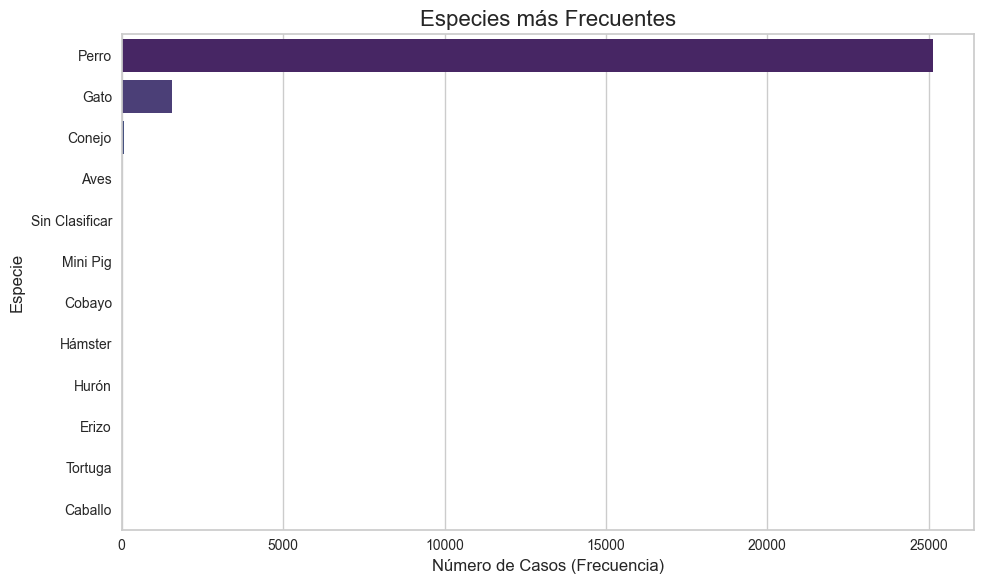

In [10]:
## 1. Análisis y Gráfico de Especies

df['especie'] = df['especie'].fillna('Sin Clasificar')

# Contar la frecuencia de todas las especies clasificadas
especies_conteo = df['especie'].value_counts()

# Filtrar para obtener el top N de especies (por ejemplo, 10), excluyendo los NaN/None
top_especies_conteo = especies_conteo.head(15).dropna()

# Calcular el porcentaje para el Top 
porcentajes_especies = (top_especies_conteo / especies_conteo.sum()) * 100

# Crear un DataFrame para la presentación tabular
top_especies_df = pd.DataFrame({
    'Frecuencia': top_especies_conteo,
    'Porcentaje (%)': porcentajes_especies.round(2)
})

print("🐾 Especies más frecuentes:")
print(top_especies_df)

# Gráfico de barras para el Top 10 de Especies
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_especies_conteo.values, 
    y=top_especies_conteo.index, 
    palette='viridis'
)
plt.title('Especies más Frecuentes', fontsize=16)
plt.xlabel('Número de Casos (Frecuencia)', fontsize=12)
plt.ylabel('Especie', fontsize=12)
plt.tight_layout()
plt.show()




🐕 Top 10 Razas de Perros más frecuentes:
                          Frecuencia  Porcentaje (%)
raza                                                
Perro Mestizo                  10882           43.28
Poodle (Caniche)                1601            6.37
Pinscher                        1357            5.40
American Pitbull Terrier        1138            4.53
Schnauzer                        828            3.29
Golden Retriever                 815            3.24
Shih Tzu                         804            3.20
Cocker Spaniel                   715            2.84
Labrador Retriever               626            2.49
Beagle                           602            2.39


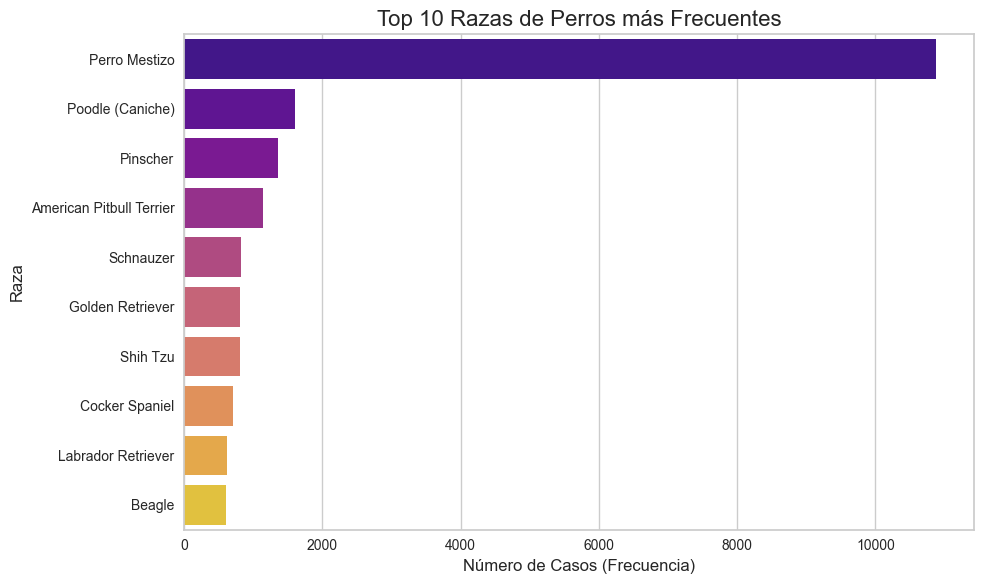

In [11]:
## 2. Análisis y Gráfico de Razas de Perros Frecuentes

# 1. Filtrar el DataFrame para obtener solo registros donde la especie original sea 'Perro'
df_perros = df[df['especie'] == 'Perro']
df = df[df['especie'] == 'Perro']

# 2. Contar la frecuencia de las razas de perros
razas_perros_conteo = df_perros['raza'].value_counts()

# 3. Obtener el Top 10 de razas de perros y eliminar los nulos (razas no identificadas dentro de los "Perro")
top_razas_conteo = razas_perros_conteo.head(10).dropna()

# 4. Calcular el porcentaje dentro de la población de perros clasificados
porcentajes_razas = (top_razas_conteo / razas_perros_conteo.sum()) * 100

# Crear un DataFrame para la presentación tabular
top_razas_df = pd.DataFrame({
    'Frecuencia': top_razas_conteo,
    'Porcentaje (%)': porcentajes_razas.round(2)
})

print("\n🐕 Top 10 Razas de Perros más frecuentes:")
print(top_razas_df)

# Gráfico de barras para el Top 10 de Razas de Perros
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_razas_conteo.values, 
    y=top_razas_conteo.index, 
    palette='plasma'
)
plt.title('Top 10 Razas de Perros más Frecuentes', fontsize=16)
plt.xlabel('Número de Casos (Frecuencia)', fontsize=12)
plt.ylabel('Raza', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
#se evidencia que el df tiene dos nuevas variables, "especie" y "raza" de caninos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25143 entries, 0 to 26889
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   nombre          25143 non-null  object
 1   observacion     10427 non-null  object
 2   pronostico      13874 non-null  object
 3   recomendacion   24898 non-null  object
 4   fecha_ingreso   25134 non-null  object
 5   fecha_atencion  25134 non-null  object
 6   enfermedad      25093 non-null  object
 7   especie         25143 non-null  object
 8   raza            25143 non-null  object
dtypes: object(9)
memory usage: 1.9+ MB


Estandarización Variable "enfemedad"
Se realiza un diccionario de la variable "enfermedad" para la especie de caninos para corrigir, normalizar, estandarizar y luego agrupar en una nueva variable llamada "enfermedades" 

In [13]:
enf = {
    # ENFERMEDADES INFECCIOSAS (Caninos)
    "Moquillo": "Distemper Canino",
    "Moquillo Canino": "Distemper Canino",
    "Distemper": "Distemper Canino",
    "Distemper Canino": "Distemper Canino",
    "Dx Confirmado: Distemper O Moquillo Canino": "Distemper Canino",
    "Distemper Virus Canino": "Distemper Canino",
    "Diagnostico Presuntivo Distemper Canino": "Distemper Canino",
    "Presunto Moquillo Canino": "Distemper Canino",
    "Secuela Distemper": "Secuelas de Distemper Canino",
    "Secuelas Distemper": "Secuelas de Distemper Canino",

    "Parvovirosis": "Parvovirosis Canina",
    "Parvovirus Canino": "Parvovirosis Canina",
    "Parvovirosis Canina": "Parvovirosis Canina",
    "Parvovirus": "Parvovirosis Canina",
    "Diagnostico Presuntivo Parvovirus": "Parvovirosis Canina",
    
    "Leptospirosis": "Leptospirosis",
    "Posible Leptospira": "Leptospirosis",
    "Leptospira": "Leptospirosis",

    "Rabia": "Rabia",
    
    "Hepatitis Canina": "Hepatitis Infecciosa Canina",
    "Hepatitis": "Hepatitis Infecciosa Canina", # Presumiendo canina si no se especifica
    
    # ----------------------------------------------------------------------
    # HEMOPARASITOSIS Y ENFERMEDADES VECTORIALES
    # ----------------------------------------------------------------------
    "Hemoparásitos": "Hemoparasitosis (General)",
    "Hemoparásito Presuntivo": "Hemoparasitosis (General)",
    "Dxp Enfermedad Hemoparasitaria": "Hemoparasitosis (General)",
    "Dxp Enfermedad Hemotropica": "Hemoparasitosis (General)",
    "Tratamiento Hemoparásitos": "Hemoparasitosis (General)",
    "Posible Hemoparásitos": "Hemoparasitosis (General)",
    "Hemoparasitismo": "Hemoparasitosis (General)",
    "Dx Presuntivo Por Agentes Hemotropicos": "Hemoparasitosis (General)",
    "Enf Hemoparasitaria": "Hemoparasitosis (General)",
    "Hemoplasma": "Hemoparasitosis (General)",
    "Tick Borne Disease": "Hemoparasitosis (General)",
    "Diagnostico Diferencial Hemoparasitismo": "Hemoparasitosis (General)",

    "Ehrlichia Canis": "Ehrlichiosis Canina",
    "Ehrlichia": "Ehrlichiosis Canina",
    "Erliquia": "Ehrlichiosis Canina",
    "Presuntivamente Erliquiosis": "Ehrlichiosis Canina",
    "E.Canis": "Ehrlichiosis Canina",
    "Resultados Compatibles Con Ehrlichia Canis": "Ehrlichiosis Canina",
    "Erlichiosis Monocitotropica Canina": "Ehrlichiosis Canina",
    "Presuntivamente Erliquiosis Canina": "Ehrlichiosis Canina", # Agregado por patrón

    "Babesia": "Babesiosis Canina",
    "Babesia Canis": "Babesiosis Canina",
    "Babesiosis": "Babesiosis Canina",
    "Anaplasmosis": "Anaplasmosis",
    "Erhlichia Y Anaplasma": "Co-Infección Ehrlichiosis/Anaplasmosis",

    # ----------------------------------------------------------------------
    # ENFERMEDADES RESPIRATORIAS (Caninos)
    # ----------------------------------------------------------------------
    "Tos De Las Perreras": "Traqueobronquitis Infecciosa Canina",
    "Bordetella": "Traqueobronquitis Infecciosa Canina",
    "Traqueo Bronquitis": "Traqueobronquitis Infecciosa Canina",
    "Traqueobronquitis Infecciosa": "Traqueobronquitis Infecciosa Canina",
    "Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Gripe": "Traqueobronquitis Infecciosa Canina",
    "Tos Seca": "Traqueobronquitis Infecciosa Canina",
    "Traqueítis": "Traqueobronquitis Infecciosa Canina",
    "Laringotraqueitis": "Laringotraqueitis",
    "Bronquitis Cronica": "Bronquitis Crónica",
    "Bronquitis Aguda": "Bronquitis Aguda",
    "Colapso Traqueal": "Colapso Traqueal",
    
    
    # ----------------------------------------------------------------------
    # ENFERMEDADES GASTROINTESTINALES (GENÉRICAS Y ESPECÍFICAS)
    # ----------------------------------------------------------------------
    "Gastroenteritis Infecciosa": "Gastroenteritis Infecciosa",
    "Gastroenteritis Bacteriana": "Gastroenteritis Infecciosa",
    "Enteritis Bacteriana": "Gastroenteritis Infecciosa",
    "Enterocolitis Bacteriana": "Gastroenteritis Infecciosa",
    "Gastroenteritis A Especificar": "Gastroenteritis No Especificada (GENE)",
    "Gastroenteritis De Origen Desconocido": "Gastroenteritis No Especificada (GENE)",
    "Gastroenteritis": "Gastroenteritis No Especificada (GENE)",
    "Gastritis": "Gastroenteritis No Especificada (GENE)",
    "Gastritis Crónica": "Gastritis Crónica",
    "Gastritis Por Ayuno Prolongado": "Gastritis Crónica",
    "Gastritis Por Indiscreción Alimentaria": "Gastritis por Indiscreción Alimentaria",
    "Indiscreción Alimentaria": "Gastritis por Indiscreción Alimentaria",
    "Indigestión Alimentaria": "Gastritis por Indiscreción Alimentaria",
    "Indiscreción Dietaria": "Gastritis por Indiscreción Alimentaria",
    "Gastroenteritis Alimentaria": "Gastritis por Indiscreción Alimentaria",
    "I. Indiscreción Alimenticia": "Gastritis por Indiscreción Alimentaria",
    "Gastroenteritis Hemorrágica": "Gastroenteritis Hemorrágica",
    "Gastroenteritis Hemorrágica De Origen Desconocido": "Gastroenteritis Hemorrágica",
    "Gastroenteritis Parasitaria": "Gastroenteritis Parasitaria",
    "G.E. Parasitaria": "Gastroenteritis Parasitaria",
    "Enteritis Parasitaria": "Gastroenteritis Parasitaria",
    "Colitis": "Colitis",
    "Diarrea De Intestino Grueso": "Colitis",
    "Diarrea": "Diarrea",
    "Vómito": "Vómito",
    "Giardiasis": "Giardiasis",
    "Coccidiosis": "Coccidiosis",
    "Entamoeba Histolytica": "Amebiasis",
    "Amebiasis": "Amebiasis",
    "Parasitosis": "Parasitosis Gastrointestinal (General)",
    "Parasitosis Intestinal": "Parasitosis Gastrointestinal (General)",
    "Poliparasitismo Intestinal": "Parasitosis Gastrointestinal (General)",
    "Toxocara Canis": "Toxocariasis",
    "Ancylostoma": "Anquilostomiasis",
    "Piometra": "Piometra",
    "Piometra Cuello Abierto": "Piometra",

    # ----------------------------------------------------------------------
    # ENFERMEDADES DERMATOLÓGICAS (Alergias)
    # ----------------------------------------------------------------------
    "Dermatitis Alérgica A La Picadura De Pulga": "Dermatitis Alérgica por Picadura de Pulga (DAPP)",
    "Alergia A La Picadura De La Pulga": "Dermatitis Alérgica por Picadura de Pulga (DAPP)",
    "Alergia Por Pulgas": "Dermatitis Alérgica por Picadura de Pulga (DAPP)",
    "DAPP": "Dermatitis Alérgica por Picadura de Pulga (DAPP)",
    "Dermatitis Alérgica": "Dermatitis Alérgica (Inespecífica)",
    "Alergia": "Dermatitis Alérgica (Inespecífica)",
    "Alergia Atópica": "Dermatitis Atópica Canina (DAC)",
    "Dermatitis Atópica": "Dermatitis Atópica Canina (DAC)",
    "Atopia": "Dermatitis Atópica Canina (DAC)",
    "Dermatistis Atopica": "Dermatitis Atópica Canina (DAC)",
    "Alergia Alimentaria": "Hipersensibilidad Alimentaria",
    "Hipersensibilidad Alimentaria": "Hipersensibilidad Alimentaria",
    "Sospechoso Hipersensibilidad": "Hipersensibilidad Alimentaria",
    
    # ----------------------------------------------------------------------
    # ENFERMEDADES DERMATOLÓGICAS (Otras/Agentes)
    # ----------------------------------------------------------------------
    "Dermatofitosis": "Dermatofitosis (Tiña)",
    "Dermatomicosis": "Dermatofitosis (Tiña)",
    "Hongos En Piel": "Dermatofitosis (Tiña)",
    "Pioderma Superficial": "Pioderma Bacteriano",
    "Pioderma Profundo": "Pioderma Bacteriano",
    "Pioderma Con Pus": "Pioderma Bacteriano",
    "Piodermatitis": "Pioderma Bacteriano",
    "Dermatitis Bacteriana": "Pioderma Bacteriano",
    "Foliculitis Bacteriana": "Pioderma Bacteriano",
    "Hot Spot": "Dermatitis Húmeda Aguda (Hot Spot)",
    "Dermatitis Húmeda": "Dermatitis Húmeda Aguda (Hot Spot)",
    "Seborrea Húmeda": "Dermatitis Seborreica",
    "Seborrea Seca": "Dermatitis Seborreica",
    "Dermatitis Seborreica": "Dermatitis Seborreica",
    "Sarna": "Sarna (No especificada)", # Dejar como general si no se especifica el tipo
    "Sarna Demodécica": "Demodicosis Canina (Sarna Demodécica)",
    "Demodicosis": "Demodicosis Canina (Sarna Demodécica)",
    "Pulgas Y Garrapatas": "Ectoparásitos (Pulgas/Garrapatas)",
    "Pulicosis": "Ectoparásitos (Pulgas/Garrapatas)",
    "Ectoparásitos": "Ectoparásitos (Pulgas/Garrapatas)",

    # ----------------------------------------------------------------------
    # ENFERMEDADES DEL TRACTO URINARIO
    # ----------------------------------------------------------------------
    "Cistitis": "Infección del Tracto Urinario (ITU)/Cistitis",
    "Cistitis Bacteriana": "Infección del Tracto Urinario (ITU)/Cistitis",
    "Infección Urinaria": "Infección del Tracto Urinario (ITU)/Cistitis",
    "Infección De Vias Urinarias Bajas": "Infección del Tracto Urinario (ITU)/Cistitis",
    "Sedimento Urinario Y Cistitis": "Infección del Tracto Urinario (ITU)/Cistitis",
    "Infección Urinaria Y Urolitiasis": "Urolitiasis/Cálculos Urinarios",
    "Urolitiasis": "Urolitiasis/Cálculos Urinarios",
    "Cristaluria": "Urolitiasis/Cálculos Urinarios",

    # ----------------------------------------------------------------------
    # MISCELÁNEA
    "Intoxicación": "Intoxicación/Envenenamiento",
    "Envenenamiento": "Intoxicación/Envenenamiento",
    "Intoxicación Por Organofosforados": "Intoxicación/Envenenamiento",
    "Intoxicación Alimentaria": "Intoxicación/Envenenamiento",
    "Trauma De Tejidos Blandos": "Trauma de Tejidos Blandos (T.T.B.)",
    "Herida Abierta Por Mordedura": "Herida por Mordedura (T.T.B.)",
    "Mordedura Por Perro": "Herida por Mordedura (T.T.B.)",
    "Lesión Por Mordedura Infectada": "Herida por Mordedura (T.T.B.)",
    "Trauma Por Mordedura": "Herida por Mordedura (T.T.B.)",
    "Absceso": "Absceso",
    "Otitis Media": "Otitis Media",
    "Otitis Bacteriana": "Otitis Externa/Media",
    "Otitis Fúngica": "Otitis Externa/Media",
    "Otitis Por Malassezia": "Otitis Externa/Media",
    "Otitis Mixta": "Otitis Externa/Media",
    "Otitis": "Otitis Externa/Media",
    "Conjuntivitis Bacteriana": "Conjuntivitis Bacteriana",
    "Conjuntivitis": "Conjuntivitis No Especificada",
    "Gingivitis": "Enfermedad Periodontal",
    "Calculo Dental": "Enfermedad Periodontal",
    "Sarro Dental Grado Ii": "Enfermedad Periodontal",
    "Enfermedad Periodontal Grado Iii": "Enfermedad Periodontal",
    "Estomatitis Por Calculo Dental": "Enfermedad Periodontal",
    "Esterilización": "Procedimiento Electivo (Esterilización)",
    "Castración": "Procedimiento Electivo (Castración)",
    "Ovh (Ovariohisterectomía)": "Procedimiento Electivo (Esterilización)",
    "Ovariohisterectomia": "Procedimiento Electivo (Esterilización)",
    "Castración Electiva": "Procedimiento Electivo (Castración)",
    "Orquiectomía": "Procedimiento Electivo (Castración)",
    "Profilaxis Dental": "Procedimiento Electivo (Profilaxis Dental)",
    "NULL": "Diagnóstico Pendiente/No Aplicable",
    "Ninguna": "Diagnóstico Pendiente/No Aplicable",
    "En Estudio": "Diagnóstico Pendiente/No Aplicable",
    "Indeterminado": "Diagnóstico Pendiente/No Aplicable",
    "Desconocido": "Diagnóstico Pendiente/No Aplicable",
    "Sin Diagnostico Final": "Diagnóstico Pendiente/No Aplicable",
    "Tvt Venéreo En Pene": "Tumor Venéreo Transmisible (TVT)",
    "Tumor Venero Transmisible": "Tumor Venéreo Transmisible (TVT)",
    "Tvt": "Tumor Venéreo Transmisible (TVT)",


    #  ENFERMEDADES INFECCIOSAS VIRALES CANINAS (Distemper y Parvo)
    "Moquillo": "Distemper Canino",
    "Moquillo Canino": "Distemper Canino",
    "Distemper": "Distemper Canino",
    "Distemper Canino": "Distemper Canino",
    "Presunto Distemper": "Distemper Canino",
    "Distemper Virus Canino": "Distemper Canino",
    "Diagnostico Presuntivo Distemper Canino": "Distemper Canino",
    "Distemper Tos De Perreras": "Distemper Canino y Complejo Respiratorio Canino",
    "Distemper Neurologico": "Secuelas Neurológicas de Distemper Canino",
    "Paciente Positivo A Distemper Canino (Moquillo)": "Distemper Canino",
    "Secuela Distemper": "Secuelas de Distemper Canino",
    "Secuales De Distemper Canino": "Secuelas de Distemper Canino",
    "Psible Distemper Canino": "Distemper Canino",
    "Distemper": "Distemper Canino",
    
    "Parvovirus": "Parvovirus Canino",
    "Parvovirosis Canina": "Parvovirus Canino",
    "Parvovirus Canino": "Parvovirus Canino",
    "Diagnosticado Parvovirus": "Parvovirus Canino",
    "Dx Anterior Parvovirosis": "Parvovirus Canino",
    
    # ENFERMEDADES INFECCIOSAS (HEMOPARÁSITOS Y OTRAS)
    "Ehrlichia Canis": "Ehrlichiosis Canina",
    "Erlichiosis": "Ehrlichiosis Canina",
    "E.Canis": "Ehrlichiosis Canina",
    "Presuntivamente Erliquiosis": "Ehrlichiosis Canina",
    "Erlichiosis Monocitotropica Canina": "Ehrlichiosis Canina",
    "Fiebre De La Garrrapata": "Ehrlichiosis Canina",
    "Babesia Canis": "Babesiosis Canina",
    "Babesia": "Babesiosis Canina",
    "Anaplasmosis": "Anaplasmosis Canina",
    "Mycoplasma": "Micoplasmosis",
    "Mycoplasma Haemofelis": "Micoplasmosis Felina",
    "Mycoplasma Felis": "Micoplasmosis Felina",
    "Mycoplasmosis Por Confirmar": "Micoplasmosis",
    "Posible Mycoplasma": "Micoplasmosis",
    "Hemoparasitosis": "Hemoparasitosis",
    "Hemoparásitos": "Hemoparasitosis",
    "Dx Presuntivo Hemoparásitos": "Hemoparasitosis (Presuntiva)",
    "Desafio Hemoparasitario": "Hemoparasitosis (En Estudio)",
    "Agente Hemotropicos": "Hemoparasitosis",
    "Hepatozoon": "Hepatozoonosis",
    "Dxp Enfermedad Hemotropica": "Hemoparasitosis (Diferencial)",
    "Dx Presuntivo Por Agentes Hemotropicos": "Hemoparasitosis (Presuntiva)",
    "Hemoparasitos Erlichia Canis": "Ehrlichiosis Canina y Hemoparasitosis",
    "Diagnostico Presuntivo Enfermedad Hemoparasitaria": "Hemoparasitosis (Presuntiva)",
    
    #  ENFERMEDADES RESPIRATORIAS (Tos de las Perreras)
    "Traqueo Bronquitis": "Traqueobronquitis Infecciosa Canina",
    "Traqueobronquitis Infecciosa": "Traqueobronquitis Infecciosa Canina",
    "Broncotraqueitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Traqueitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Tos De Las Perreras": "Traqueobronquitis Infecciosa Canina (Kennel Cough)",
    "Bronquitis": "Bronquitis",
    "Bronquitis Cronica": "Bronquitis Crónica",
    "Complejo Respiratorio Canino": "Traqueobronquitis Infecciosa Canina",
    "Leve Traqueobronquitis": "Traqueobronquitis Infecciosa Canina",
    "Traqueítis": "Traqueítis",
    "Estenosis Traqueal": "Estenosis Traqueal",
    "Presuntivo Colapso Traqueal": "Colapso Traqueal",

    #  ENFERMEDADES GASTROINTESTINALES (GI)
    "Gastritis Crónica": "Gastritis Crónica",
    "Gastritis": "Gastritis Aguda",
    "Gastritis Aguda": "Gastritis Aguda",
    "Cuadro De Gastritis": "Gastritis (Signología Inespecífica)",
    "Cuadro Gastroentérico": "Gastroenteritis (Signología Inespecífica)",
    "Gastroenteritis": "Gastroenteritis",
    "Gastroenteritis Bacteriana": "Gastroenteritis Bacteriana",
    "Gastroenteritis Emorragica": "Gastroenteritis Hemorrágica",
    "Gastroenteritis Hemorragica": "Gastroenteritis Hemorrágica",
    "Enteritis Alimentaria": "Enteritis Alimentaria",
    "Enteritis Bacteriana": "Enteritis Bacteriana",
    "Enterocolitis Bacteriana": "Enterocolitis Bacteriana",
    "Gastroenteritis De Origen Desconocido": "Gastroenteritis (Etiología Desconocida)",
    "Gastroenteritis Parasitaria": "Gastroenteritis Parasitaria",
    "Enteritis Parasitaria": "Gastroenteritis Parasitaria",
    "Parasitismo Gastrointestinal": "Parasitismo Gastrointestinal",
    "Parasitismo": "Parasitismo Gastrointestinal",
    "Parasitos Intestinales": "Parasitismo Gastrointestinal",
    "Giardiasis": "Giardiasis",
    "Giardia Intestinalis": "Giardiasis",
    "Coccidia": "Coccidiosis",
    "Cystoisospora": "Coccidiosis (Cystoisospora)",
    "Ancylostoma": "Anquilostomiasis",
    "Ancylostomiasis": "Anquilostomiasis",
    "Toxocara Canis": "Toxocariasis",
    "Indiscrecion Medicamentosa": "Indiscreción Alimentaria",
    "Indiscreción Alimentaria": "Indiscreción Alimentaria",
    "Dxp Indiscrecion Alimentaria": "Indiscreción Alimentaria (Presuntiva)",
    "Gastritis Por Indiscreción Alimentaria": "Indiscreción Alimentaria (Gastritis)",
    "Enteritis": "Enteritis",
    "Diarrea": "Diarrea (Signo Clínico)",
    "Colitis": "Colitis",
    "Síndrome De Mala Absorción": "Síndrome de Mala Absorción",
    "Enfermedad Inflamatoria Intestinal": "Enfermedad Inflamatoria Intestinal (EII)",
    "Eii": "Enfermedad Inflamatoria Intestinal (EII)",

    #  ENFERMEDADES DERMATOLÓGICAS Y ÓTICAS
    "Dermatitis": "Dermatitis (Inespecífica)",
    "Dermatitis Alérgica": "Dermatitis Alérgica",
    "Dermatitis Atópica": "Dermatitis Atópica Canina (DAC)",
    "Alergia Atópica": "Dermatitis Atópica Canina (DAC)",
    "Dermatitis Atópica Canina (Dac)": "Dermatitis Atópica Canina (DAC)",
    "Dxp Dermatitis Atopica": "Dermatitis Atópica Canina (DAC) (Presuntiva)",
    "Alergia Alimentaria": "Dermatitis por Alergia Alimentaria",
    "Dermatitis Atopicaalimentaria": "Dermatitis Atópica y Alimentaria",
    "Dermatitis Alérgica A La Picadura De Pulga": "Dermatitis Alérgica por Picadura de Pulga (DAPP)",
    "Alergia A La Picadura De La Pulga": "Dermatitis Alérgica por Picadura de Pulga (DAPP)",
    "Pulicosis": "Pulicosis (Infestación por Pulgas)",
    "Dxp Pioderma": "Pioderma Superficial",
    "Pioderma": "Pioderma Superficial",
    "Piodermia": "Pioderma Superficial",
    "I.Pioderma Superficial": "Pioderma Superficial",
    "Foliculitis Bacteriana": "Pioderma Superficial",
    "Dermatofitosis": "Dermatofitosis (Tiña)",
    "Dermatitis Fúngica": "Dermatofitosis/Micosis Cutánea",
    "Micosis Cutanea": "Dermatofitosis/Micosis Cutánea",
    "Levurosis": "Micosis/Levurosis Cutánea",
    "Dermatitis Por Hongos": "Micosis/Dermatitis Fúngica",
    "Otitis Mixta": "Otitis Externa (Mixta)",
    "Otitis Por Malassezia": "Otitis por Malassezia",
    "Dxp Otitis Por Malassezia Pachydermatis": "Otitis por Malassezia (Presuntiva)",
    "Otitis Bacteriana": "Otitis Bacteriana",
    "Otitis Bilateral": "Otitis (Bilateral)",
    "Otitis Media": "Otitis Media",
    "Otitis": "Otitis Externa",
    "Demodicosis Dermatofitosis": "Demodicosis y Dermatofitosis",
    "Dxp Sarna Demodecica": "Demodicosis Canina (Presuntiva)",
    "Demodecosis": "Demodicosis Canina",
    "Sarna": "Sarna Sarcóptica",
    "Sarna Sarcoptica": "Sarna Sarcóptica",
    "Dermatitis Acaroshongos": "Dermatitis por Ácaros y Hongos",
    "Hot Spot": "Dermatitis Húmeda Aguda (Hot Spot)",
    "Otodectes Cynotis": "Otitis por Ácaros (Otodectes Cynotis)",
    
    #  ENFERMEDADES ENDOCRINAS
    "Diabetes Mellitus": "Diabetes Mellitus",
    "Hipotiroidismo": "Hipotiroidismo Canino",
    "Hipotiroidismo Canino": "Hipotiroidismo Canino",
    "Síndrome De Cushing": "Hiperadrenocorticismo (Cushing)",
    "Hiperadrenocorticismo": "Hiperadrenocorticismo (Cushing)",
    
    #  ENFERMEDADES UROGENITALES
    "Erc": "Enfermedad Renal Crónica (ERC)",
    "Enfermedad Renal": "Enfermedad Renal Crónica (ERC)",
    "E.R.C": "Enfermedad Renal Crónica (ERC)",
    "Erc Avanzada": "Enfermedad Renal Crónica (ERC) Avanzada",
    "Iraerc": "Insuficiencia Renal Aguda sobre Crónica",
    "Insuficiencia Renal": "Enfermedad Renal",
    "Injuria Renal Aguda": "Injuria Renal Aguda (IRA)",
    "Pielonefritis": "Pielonefritis",
    "Infección Urinaria": "Infección de Vías Urinarias (IVU)",
    "Cistitis": "Cistitis",
    "Cistitis Bacteriana": "Cistitis Bacteriana",
    "Cistitis Urolitiasis": "Cistitis y Urolitiasis",
    "Urolitiasis": "Urolitiasis",
    "Cristaluria": "Cristaluria",
    "Flutd": "Enfermedad del Tracto Urinario Bajo Felina (FLUTD)",
    "Flutd (Enfermedad Del Tracto Urinario Inferior Felina)": "Enfermedad del Tracto Urinario Bajo Felina (FLUTD)",
    "Piometra": "Piometra",
    "Ovh Piometra": "Piometra",
    "Cirugía Piometra": "Cirugía por Piometra",
    "Hiperplasia Endometrial Quística": "Hiperplasia Endometrial Quística",
    
    # ORTOPÉDICOS / NEUROLÓGICOS
    "Luxación De Patela": "Luxación de Patela",
    "Displasia De Cadera": "Displasia de Cadera",
    "Presunta Displasia De Cadera": "Displasia de Cadera (Presuntiva)",
    "Ruptura De Ligamentocruzado Craneal": "Ruptura de Ligamento Cruzado Craneal (LCCr)",
    "Ruptura De Ligamento Cruzado Anterior": "Ruptura de Ligamento Cruzado Craneal (LCCr)",
    "Compresión Medular": "Compresión Medular",
    "Hernia Discal": "Hernia Discal",
    "Epilepsia Idiopática": "Epilepsia Idiopática",
    "Episodios Convulsivos": "Convulsiones (A estudio)",
    "Síndrome Vestibular Periférico": "Síndrome Vestibular Periférico",
    
    # OTROS ESPECÍFICOS Y SÍNTOMAS COMUNES
    "Pancreatitis": "Pancreatitis",
    "Hepatopatia": "Hepatopatía (A estudio)",
    "Lipidosis Hepática": "Lipidosis Hepática",
    "Carcinoma De Células Escamosas": "Carcinoma de Células Escamosas (CCE)",
    "Tumor Mamario": "Neoplasia Mamaria",
    "Osteosarcoma": "Osteosarcoma",
    "Tvt": "Tumor Venéreo Transmisible (TVT)",
    "Otitis Bilateral": "Otitis Externa Bilateral",
    "Absceso Por Mordeduras": "Absceso por Mordedura",
    "Herida Por Mordedura": "Herida por Mordedura",
    "Herida Por Mordedura": "Herida por Mordedura",
    "Herida Abierta": "Herida Abierta",
    "Trauma De Tejidos Blandos": "Trauma de Tejidos Blandos",
    "Politraumatismo": "Politraumatismo",
    "Intoxicación": "Intoxicación",
    "Miasis": "Miasis",
    "Otohematoma": "Otohematoma",
    "Queratoconjuntivitis Seca": "Queratoconjuntivitis Seca (QCS)",
    "Ojo Seco": "Queratoconjuntivitis Seca (QCS)",
    "Ulcera Corneal": "Úlcera Corneal",
    "Conjuntivitis": "Conjuntivitis",
    "Edema Pulmonar Cardiogenico": "Edema Pulmonar Cardiogénico",
    "Paciente Cardiopata": "Cardiopatía (A estudio)",
    "Soplo Cardiaco": "Soplo Cardíaco",
    "Anemia Hemoparásitos": "Anemia (Secundaria a Hemoparásitos)",
    "Anemia": "Anemia (A estudio)",
    "Castración Electiva": "Orquiectomía Electiva (Castración)",
    "Cirugía Orquiectomia": "Orquiectomía Electiva (Castración)",
    "Orquiectomía": "Orquiectomía Electiva (Castración)",
    "Castración": "Orquiectomía/Ovariohisterectomía",
    "Ovh Electiva": "Ovariohisterectomía Electiva",
    "Ovh (Ovariohisterectomía)": "Ovariohisterectomía Electiva",
    "Cirugía Ovh": "Ovariohisterectomía Electiva",
    "Ovariohisterectomia": "Ovariohisterectomía Electiva",
    "Retiro De Masas": "Retiro de Masas (Neoplasia/Quiste)",
    "Masa Tumoral": "Neoplasia (Masa)",
    "Posible Neoplasia": "Neoplasia (Presuntiva)",
    
    # SÍNTOMAS Y ESTADOS NO PATOLÓGICOS
    "Inapetencia": "Inapetencia/Anorexia (Signo Clínico)",
    "Dolor": "Dolor (Signo Clínico)",
    "Estrés": "Estrés/Ansiedad",
    "Obesidad Mórbida": "Obesidad Mórbida",
    "Obesidad": "Sobrepeso/Obesidad",
    "Aun Sin Diagnostico": "En Estudio/Sin Diagnóstico",
    "Pendiente Por Diagnostico": "En Estudio/Sin Diagnóstico",
    "En Estudio": "En Estudio/Sin Diagnóstico",
    "Espera De Resultados": "En Estudio/Sin Diagnóstico",
    "Post Quirúrgico": "Estado Postquirúrgico",
    "Postquirúrgico": "Estado Postquirúrgico",
    "Control": "Control Médico",
    "S.C.P.A. (Sin Cambio Patologico Aparente)": "Clínicamente Sano (SCPA)",
    "Paciente Clinicamente Sano": "Clínicamente Sano (SCPA)",
    "Ninguna": "Clínicamente Sano (SCPA)",
    "Primo-Consulta": "Clínicamente Sano (SCPA)",
    "Normal": "Clínicamente Sano (SCPA)",
    "Na": "No Aplica/Sin Diagnóstico Registrado",
    
    #---------------------------------------------
    
    # --- ENFERMEDADES INFECCIOSAS SISTÉMICAS ---
    "Ehrlichia Canis": "Ehrlichiosis Canina",
    "Posible Ehrlichia Canis": "Ehrlichiosis Canina",
    "Ehrlichia Fase Cronica": "Ehrlichiosis Canina",
    "Dx Confirmado: Ehrlichiosis Canina": "Ehrlichiosis Canina",
    "Presuntivo Ehrlichia Canis": "Ehrlichiosis Canina",
    "Anaplasmosis Canina Y Ehrlichiosis Canina": "Ehrlichiosis Canina/Anaplasmosis",

    "Diagnosticado Parvovirus": "Parvovirus Canino",
    "Dx Confirmado: Parvovirus Canino": "Parvovirus Canino",
    "Dx Confimado: Parvovirosis Canina": "Parvovirus Canino",
    "Posible Parvovirosis Canina": "Parvovirus Canino",

    "Dxp Distemper Canino": "Distemper Canino",
    "Distemper Canino": "Distemper Canino",
    "Distemper": "Distemper Canino",
    "Dx Confirmado: Distemper Canino": "Distemper Canino",
    "Posible Distemper Canino": "Distemper Canino",
    "Moquillo": "Distemper Canino",
    "Dx Pres: Moquillo": "Distemper Canino",

    "Hemoparásitos": "Hemoparasitosis",
    "Dx Presuntivo Hemoparásitos": "Hemoparasitosis",
    "Dx Pre. Hemoparasitos": "Hemoparasitosis",
    "Anemia Hemoparásitos": "Hemoparasitosis (con Anemia)",
    "Dx Hemoparasitos": "Hemoparasitosis",
    
    # --- ENFERMEDADES RESPIRATORIAS ---
    "Tos De Las Perreras": "Complejo Respiratorio Canino (CRC)",
    "Dxp Traqueobronquitis Infecciosa Canina": "Complejo Respiratorio Canino (CRC)",
    "Traqueobronquitis Infecciosa Canina": "Complejo Respiratorio Canino (CRC)",
    "Traqueo Bronquitis": "Complejo Respiratorio Canino (CRC)",
    "Traqueítis": "Complejo Respiratorio Canino (CRC)",
    "Broncotraqueitis Infecciosa Canina": "Complejo Respiratorio Canino (CRC)",
    "Dxp Traqueitis": "Complejo Respiratorio Canino (CRC)",
    "Presuntivo: Traqueobronquitis Infecciosa Canina": "Complejo Respiratorio Canino (CRC)",
    "Posible Traqueobronquitis": "Complejo Respiratorio Canino (CRC)",
    "Laringotraqueitis Infecciosa": "Complejo Respiratorio Canino (CRC)",
    "Bordetella Bronchiséptica": "Bordetella (CRC)",
    "Kennel Cough": "Complejo Respiratorio Canino (CRC)",
    "Gripe Canina": "Complejo Respiratorio Canino (CRC)",

    "Resfriado Comun": "Resfriado Común (Inespecífico)",
    "Bronquitis": "Bronquitis",
    "Bronconeumonia": "Bronconeumonía",
    "Enfermedad Respiratoria": "Enfermedad Respiratoria (Inespecífica)",

    # --- ENFERMEDADES GASTROINTESTINALES ---
    "Cuadro Gastroentérico": "Gastroenteritis (Inespecífica)",
    "Gastroenteritis": "Gastroenteritis (Inespecífica)",
    "Colitis Gastroenteritis": "Gastroenteritis/Colitis",
    "Alteracion Gastrointestinal": "Trastorno Gastrointestinal (Inespecífico)",
    "Enterocolitis": "Enterocolitis",
    "Enterocolitis Aguda": "Enterocolitis Aguda",
    "Enteritis": "Enteritis",
    "Diarrea": "Diarrea (Síntoma)",

    "Cuadro De Gastritis": "Gastritis",
    "Gastritis": "Gastritis",
    "Gastritis Crónica Leve": "Gastritis Crónica",
    "Gastritis Por Aines": "Gastritis Medicamentosa (AINES)",
    "Dxp Gastritis Medicamentosa": "Gastritis Medicamentosa",
    "Gastritis Alimentaria": "Gastritis Alimentaria",

    "Colitis Indiscrecion Alimentaria": "Indiscreción Alimentaria",
    "Intoxicacion Alimentaria Por Fermentacion": "Intoxicación Alimentaria",
    "Dxp Indiscrecion Alimentaria": "Indiscreción Alimentaria",
    "Enteritis Alimentaria": "Indiscreción Alimentaria",

    "Dxp Gastroenteritis Bacteriana": "Gastroenteritis Bacteriana",
    "Gasteroenteritis Bacterina": "Gastroenteritis Bacteriana",
    "Gastroenteritis Bacteriana Gastroenteritis Parasitaria": "Gastroenteritis Mixta (Bact/Par)",
    "Dx Presuntivo: Gastroenteritis Bacteriana Yo Parasitaria": "Gastroenteritis Mixta (Bact/Par)",

    "Giardiasis": "Giardiasis",
    "Giardiosis": "Giardiasis",
    "Giardia Intestinalis": "Giardiasis",
    "Gastritis Por Giardia": "Giardiasis (con Gastritis)",
    "Coccidiosis": "Coccidiosis",
    "Toxocariasis": "Toxocariasis",
    "Parasitos Intestinales": "Parasitosis Intestinal",
    "Dxp Parasitosis": "Parasitosis Intestinal",
    "Endoparasitismo": "Parasitosis Intestinal",
    "Dxp Gastroenteritis Parasitaria": "Parasitosis Gastrointestinal",
    "Dxp Presuntivo Parasitosis G.I.": "Parasitosis Gastrointestinal",
    "Ancylostomiasis": "Ancilostomiasis",
    "Miasis": "Miasis Cutánea/Tisular",
    "Cyniclomyces Guttulatus": "Cyniclomyces Guttulatus (Levadura)",

    "Pancreatitis": "Pancreatitis",
    "Pancreatitis Aguda Severa": "Pancreatitis Aguda",

    # --- ENFERMEDADES DERMATOLÓGICAS ---
    "Dermatitis Alérgica A La Picadura De Pulga": "Dermatitis Alérgica a la Picadura de Pulga (DAPP)",
    "Alergia A Pulgas": "Dermatitis Alérgica a la Picadura de Pulga (DAPP)",
    "Dermatitis Atópica": "Dermatitis Atópica Canina (DAC)",
    "Dermatistis Atopica": "Dermatitis Atópica Canina (DAC)",
    "Dermatitis Alérgica Atopia Canina": "Dermatitis Atópica Canina (DAC)",
    "Dxp Dac": "Dermatitis Atópica Canina (DAC)",

    "Dxp Pioderma": "Pioderma",
    "Pioderma Superficial": "Pioderma",
    "Pioderma Profundo": "Pioderma",
    "Dermatitis Bacteriana": "Pioderma",
    "Dapp Pioderma": "Pioderma y DAPP",
    "Foliculitis Bacteriana": "Pioderma",

    "Dermatofitosis": "Dermatofitosis (Micosis)",
    "Micosis Cutanea": "Dermatofitosis (Micosis)",
    "Dermatitis Fúngica": "Dermatofitosis (Micosis)",
    "Dermatitis Por Levurosis.": "Dermatitis por Malassezia",
    "Dxp Otitis Por Malassezia Pachydermatis": "Otitis por Malassezia",
    "Otitis Por Malassezia": "Otitis por Malassezia",

    "Sarna Sarcoptica": "Sarna Sarcóptica",
    "Dermatitis Por Ácaros": "Acarosis (Sarna)",
    "Dappdermatitis Por Acaros": "Acarosis y DAPP",
    "Dermatitis Acaroshongos": "Acarosis y Micosis",
    "Dermodecosis": "Demodicosis",

    "Hot Spot": "Dermatitis Húmeda (Hot Spot)",
    "Dxp Hot Spot": "Dermatitis Húmeda (Hot Spot)",
    "Eczema Humedo": "Dermatitis Húmeda (Hot Spot)",

    "Alergia": "Reacción Alérgica/Hipersensibilidad",
    "Hipersensibilidad Alimentaria": "Alergia Alimentaria",
    "Alergia Alimentaria": "Alergia Alimentaria",
    "Lupus Eritematoso": "Lupus Eritematoso Sistémico (LES)",
    "Posible Lupus Eritematoso": "Lupus Eritematoso Sistémico (LES) Presuntivo",

    # --- ENFERMEDADES URINARIAS Y RENALES ---
    "Enfermedad Renal Crónica": "Enfermedad Renal Crónica (ERC)",
    "Erc": "Enfermedad Renal Crónica (ERC)",
    "Irc": "Enfermedad Renal Crónica (ERC)",
    "Erc Iris 2": "Enfermedad Renal Crónica (ERC) E II",
    "Erc Iris 3": "Enfermedad Renal Crónica (ERC) E III",
    "Injuria Renal Aguda": "Injuria Renal Aguda (IRA)",
    "Ira": "Injuria Renal Aguda (IRA)",
    "Pielonefritis": "Pielonefritis",
    "Glomerulonefritis": "Glomerulonefritis",
    "Enfermedad Renal Poliquística": "Enfermedad Poliquística Renal",
    "Enfermedad Renal": "Enfermedad Renal (Inespecífica)",

    "Cistitis": "Cistitis",
    "Cistitis Bacteriana": "Cistitis Bacteriana",
    "Infección Urinaria": "Cistitis/Infección Urinaria",
    "Infeccion Urinaria Por Proteus Sp": "Cistitis Bacteriana (Proteus)",
    "Posible Urolitiasis": "Urolitiasis (Cálculos Urinarios)",
    "Urolitiasis Vesical": "Urolitiasis (Cálculos Urinarios)",
    "Cristaluria": "Urolitiasis (Cristaluria)",
    "Cistitis Por Cristales De Estruvita": "Urolitiasis (Cristales de Estruvita)",
    "Flutd Obstructivo": "FLUTD (Obstructivo)",
    "Cistitis Idiopatica": "FLUTD (Cistitis Idiopática Felina)",
    "Piometra": "Piometra",
    "Hiperplasia Endometrial Quisticapiometra": "Piometra (Forma QHE)",
    "Incompetencia Del Mecanismo Del Esfinter Uretral": "Incontinencia Urinaria",

    # --- CARDIOVASCULAR Y RESPIRATORIO NO INFECCIOSO ---
    "Cardiopatía": "Cardiopatía (Inespecífica)",
    "Enfermedad Mitral": "Enfermedad Valvular Mitral",
    "Insuficiencia Mitral": "Enfermedad Valvular Mitral",
    "Hipertensión Arterial": "Hipertensión Arterial",
    "Colapso Traqueal": "Colapso Traqueal",

    # --- ENDOCRINO Y METABÓLICO ---
    "Hipotiroidismo": "Hipotiroidismo Canino",
    "Hipotiroidismo Canino": "Hipotiroidismo Canino",
    "Hipotiroidismo Primario": "Hipotiroidismo Primario",
    "Diabetes": "Diabetes Mellitus",
    "Posible Cushing": "Síndrome de Cushing (Presuntivo)",
    "Hepatopatia.": "Hepatopatía (Enfermedad Hepática)",
    "Falla Hepatica": "Insuficiencia Hepática",
    "Dx Pres: Sobrecarga Hepatica": "Sobrecarga Hepática (Presuntiva)",
    "Ictericia": "Ictericia (Síntoma)",

    # --- ONCOLÓGICO ---
    "Tumores Cutaneos": "Masa/Tumor Cutáneo (Inespecífico)",
    "Tumores Sin Identificar": "Masa/Tumor (Inespecífico)",
    "Lipoma Cutáneo": "Lipoma Cutáneo (Benigno)",
    "Dxp Tumor Venéreo Transmisible": "Tumor Venéreo Transmisible (TVT)",
    "Tumor De Sticker": "Tumor Venéreo Transmisible (TVT)",
    "Neoformación Mamaria": "Neoplasia Mamaria (Masa)",
    "Neoplasia Intestinal": "Neoplasia Gastrointestinal",
    "Carcinoma De Células Escamosas": "Carcinoma de Células Escamosas (CCE)",
    "Linfoma": "Linfoma",

    # --- ODONTOLÓGICO Y OROFARINGEO ---
    "Enfermedad Periodontal Grado 4 De 4": "Enfermedad Periodontal (EP) G IV",
    "Enfermedad Periodontal Grado Iii": "Enfermedad Periodontal (EP) G III",
    "Enfermedad Periodontal Grado Iv": "Enfermedad Periodontal (EP) G IV",
    "Artropatia Y Enfermedad Periodontal Estadio 1": "EP (Estadio 1) y Artropatía",
    "Dx Presntivo. Enfermedad Periodonal": "Enfermedad Periodontal (EP)",
    "Gingivitis": "Gingivitis",
    "Dx Presuntivo: Gingivoestomatitis": "Gingivoestomatitis",
    "Papiloma Buca": "Papilomatosis Oral",
    "Dxp Papilomatosis": "Papilomatosis",

    # --- NEUROLÓGICO Y MUSCULOESQUELÉTICO ---
    "Epilepsia Idiopática": "Epilepsia Idiopática",
    "Posible Epilepsia Idiopatica": "Epilepsia Idiopática (Presuntiva)",
    "Convulsión": "Convulsión (Etiología Desconocida)",
    "Ataques Epilepticos": "Convulsión (Etiología Desconocida)",
    "Dxp Epilepsia Ideopatica": "Epilepsia Idiopática",
    "Lesión Medular Aguda": "Lesión Medular Aguda",
    "Displasia De Cadera": "Displasia de Cadera",
    "Displacia Cadera": "Displasia de Cadera",
    "Osteoartrosis Degenerativa": "Enfermedad Articular Degenerativa (EAD)",
    "Artrosis Canina": "Enfermedad Articular Degenerativa (EAD)",
    "Cauda Equina": "Síndrome de Cauda Equina",

    # --- TRAUMA Y PROCEDIMIENTOS ---
    "Herida Por Mordedura": "Trauma por Mordedura",
    "Lesion De Piel Por Mordedura": "Trauma por Mordedura",
    "Trauma Por Congenere": "Trauma por Mordedura (Intraespecie)",
    "Trauma De Tejidos Blandos": "Trauma de Tejidos Blandos",
    "Laceración": "Laceración (Herida)",
    "Politraumatismo": "Politraumatismo",
    "Otohematoma": "Otohematoma",

    "Cirugía Electiva: Orquiectomía": "Castración (Procedimiento Electivo)",
    "Castración Electiva": "Castración (Procedimiento Electivo)",
    "Post Orquectomia": "Postquirúrgico (Castración)",
    "Cirugía Esterilización": "Esterilización (Procedimiento Electivo)",
    "Cirugia Ovh": "OVH (Procedimiento Electivo)",
    "Cirugía De Ovh": "OVH (Procedimiento Electivo)",
    "Post Ovh": "Postquirúrgico (OVH)",
    "Ovh Electiva": "OVH (Procedimiento Electivo)",

    "Postquirúrgico": "Postquirúrgico (General)",
    "Post Quirúrgico": "Postquirúrgico (General)",
    "Cuidado Post-Quirúrgico": "Postquirúrgico (Cuidado)",
    "Post Profilaxis Dental": "Postquirúrgico (Dental)",
    "Cesarea Mas Ovariohisterectomía": "Cesárea + OVH (Procedimiento)",

    # --- OFTALMOLÓGICO ---
    "Opacidad Corneal": "Opacidad Corneal",
    "Dx Pre: Ulcera Corneal": "Úlcera Corneal",
    "Ulcera Corneal No Perforante": "Úlcera Corneal",
    "Queratitis Pigmentaria Del Pug": "Queratitis Pigmentaria",
    "Conjuntivitis": "Conjuntivitis",
    "Conjutivitis Bacteriana": "Conjuntivitis Bacteriana",
    "Queratoconjuntivitis Seca": "Queratoconjuntivitis Seca (QCS)",

    # --- GENERAL Y ESTATUS ---
    "Paciente Clinicamente Sano": "Paciente Clínicamente Sano",
    "Ninguna Actualmente": "Paciente Clínicamente Sano",
    "Ninguna": "Paciente Clínicamente Sano",
    "Cachorro Sano": "Paciente Clínicamente Sano",
    "En Estudio": "Diagnóstico Pendiente/En Estudio",
    "Aun Sin Diagnostico": "Diagnóstico Pendiente/En Estudio",
    "Sin Definir": "Diagnóstico Pendiente/En Estudio",
    "Indeterminado": "Diagnóstico Pendiente/En Estudio",
    "Na": "Diagnóstico Pendiente/En Estudio",
    "Fiebre": "Fiebre (Síntoma)",
    "Abdomen Agudo": "Abdomen Agudo",
    "Dolor": "Dolor (Síntoma)",
    "Intoxicación": "Intoxicación (Inespecífica)",
    "Bajo Peso": "Baja Condición Corporal",
    "Obesidad": "Obesidad",
    "Xerodermia": "Xerodermia (Piel Seca)",
    "Pseudogestación": "Pseudogestación (Embarazo Psicológico)",

    # --- DIAGNÓSTICOS MÚLTIPLES COMPLEJOS (Manejo específico) ---
    "Dxp: Hemoparásitoproceso Neoplásico": "Diagnóstico Múltiple (Hemoparásitos/Neoplasia)",
    "Ehrlichiosis Caninainsuficiencia Renalenfermedad Hepática": "Diagnóstico Múltiple (Ehr/Renal/Hepático)",
    
    #---------------------------------------------------------------
    
    # DISTEMPER CANINO (MOQUILLO)
    "Moquillo": "Distemper Canino",
    "Moquillo Canino": "Distemper Canino",
    "Distemper": "Distemper Canino",
    "Distemper Canino": "Distemper Canino",
    "Secuela Distemper": "Secuelas de Distemper Canino",
    "Dx Confirmado: Distemper O Moquillo Canino": "Distemper Canino",
    "Diagnostico: Moquillo": "Distemper Canino",
    "Paciente Positivo A Distemper Canino (Moquillo)": "Distemper Canino",
    "Posible Distemper Canino": "Distemper Canino",
    "Distemper Canino Enf Hemoparasitaria": "Distemper Canino",
    
    # PARVOVIRUS CANINO
    "Parvovirus Canino": "Parvovirus Canino",
    "Dx Confimado: Parvovirosis Canina": "Parvovirus Canino",
    "Parvovirosis": "Parvovirus Canino",
    "Diagnostico Presuntivo De Parvovirosis Canina": "Parvovirus Canino",
    "Posible Parvo": "Parvovirus Canino",
    "Dxp Parvovirosis Canina": "Parvovirus Canino",
    
    # ENFERMEDADES HEMOPARASITARIAS
    "Ehrlichia Canis": "Ehrlichiosis Canina",
    "Dx Confirmado: Ehrlichiosis Canina": "Ehrlichiosis Canina",
    "Erlichiosis": "Ehrlichiosis Canina",
    "Anaplasmosis Canina Y Ehrlichiosis Canina": "Ehrlichiosis y Anaplasmosis",
    "Dx: Posible Fiebre De Garrapata Erliquia": "Ehrlichiosis Canina",
    "Anaplasma": "Anaplasmosis",
    "Hemoparasitos Erlichia Canis": "Ehrlichiosis Canina",
    "Sospecha De Enfermedad Hemoparasitaria": "Enfermedad Hemoparasitaria",
    "Dxp Hemoparasitos": "Enfermedad Hemoparasitaria",
    "Dx Hemoparasitos": "Enfermedad Hemoparasitaria",
    "Dx Diferencial Hemoparasitosis": "Enfermedad Hemoparasitaria",
    "Diagnostico Presuntivo Enfermedad Hemoparasitaria": "Enfermedad Hemoparasitaria",
    
    # ENFERMEDADES RESPIRATORIAS INFECCIOSAS
    "Tos De Las Perreras": "Traqueobronquitis Infecciosa Canina",
    "Dxp Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Presuntivo: Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Posible Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Broncotraqueitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Indicios De Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Traqueobraonquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina",
    "Dxp Traqueitis": "Traqueítis",
    "Traqueítis": "Traqueítis",
    "Inflamacion De Traquea": "Traqueítis",
    "Traqueo Bronquitis": "Bronquitis y Traqueítis",
    "Bronquitis": "Bronquitis",
    "Traquobronquitis": "Bronquitis",
    "Epocbronquitis": "Bronquitis Crónica (EPOC)",
    "Dxp Traqueitis": "Traqueítis",

    # OTRAS INFECCIONES ESPECÍFICAS
    "Coccidiosis": "Coccidiosis",
    "Giardiasis": "Giardiasis",
    "Giardiosis": "Giardiasis",
    "Coccidiosis Y Giardiasis": "Coccidiosis y Giardiasis",
    "Ancylostoma": "Ancylostomiasis",
    "Ancylostomiasis": "Ancylostomiasis",
    "Campylobacteriosis": "Campylobacteriosis",
    "Clostridiosis": "Clostridiosis",
    "Clostridium Sp+": "Clostridiosis",
    "Papilomatosis Canina": "Papilomatosis Canina",
    "Papilomatosis": "Papilomatosis Canina",
    
    # ----------------------------------------------------------------------
    #  DERMATOLOGÍA Y PARASITOSIS EXTERNA
    # ----------------------------------------------------------------------
    
    # SARNA (ACAROSIS)
    "Sarna Notoedrica": "Sarna Notoédrica",
    "Dxp Sarna": "Sarna",
    "Acaros": "Acarosis",
    "Dematitis Por Acaros": "Acarosis",
    "Dermatitis Por Acaros Y Hongos": "Acarosis y Dermatofitosis",
    "Demodecosis Juvenil": "Sarna Demodécica Juvenil",
    "Demodex Canis": "Sarna Demodécica",
    "Dxp Sarna Demodecica": "Sarna Demodécica",
    "Sarna Demodécica": "Sarna Demodécica",
    "Dappdermatitis Por Acaros": "Dermatitis y Acarosis",
    
    # DERMATITIS Y ALERGIAS
    "Dermatitis": "Dermatitis Inespecífica",
    "Dermatitis Alérgica": "Dermatitis Alérgica",
    "Dermatitis Atópica": "Dermatitis Atópica Canina",
    "Dermatistis Atopica": "Dermatitis Atópica Canina",
    "Alopecia Sectorizada Por Dermatitis Atopica": "Dermatitis Atópica Canina",
    "Dermatitis Alérgica Atopia Canina": "Dermatitis Atópica Canina",
    "Alergia": "Reacción Alérgica",
    "Alergia A La Picadura De La Pulga": "Dermatitis Alérgica a Pulgas (DAPP)",
    "Dermatitis Alérgica A Pulgas": "Dermatitis Alérgica a Pulgas (DAPP)",
    "Dermatitis Alergica A La Picadura De Pulga": "Dermatitis Alérgica a Pulgas (DAPP)",
    "Dapp Gastroenteritis Bacteriana": "Dermatitis Alérgica a Pulgas y Gastroenteritis",
    "Dapppioderma Superficial": "Dermatitis Alérgica a Pulgas y Pioderma",
    "Dermatitis Alérgica Por Contacto": "Dermatitis por Contacto",
    "Dermatitis Por Contacto": "Dermatitis por Contacto",
    "Dermatitis Fungicabacteriana": "Dermatitis Mixta (Fúngica/Bacteriana)",
    "Pioderma": "Pioderma",
    "Pioderma Profundo": "Pioderma Profundo",
    "Pioderma Superficial": "Pioderma Superficial",
    "Piodermatitis": "Pioderma",
    "I.Pioderma Superficial": "Pioderma Superficial",
    "Foliculitits Bacteriana": "Foliculitis Bacteriana",
    "Dermatofitosis": "Dermatofitosis (Tiña)",
    "Dermatomicosis": "Dermatofitosis (Tiña)",
    "Dx Presuntivo: Dermatitis Fungica O Por Acaros": "Dermatitis Fúngica/Acarosis",
    "Dx Presuntivo: Dermatitis Por Hongos": "Dermatitis Fúngica",
    "Dx Pre: Dermatitis Bacteriana Yo Fungica": "Dermatitis Mixta (Bacteriana/Fúngica)",
    "Costras En Plano Nasal": "Lesión Dermatológica Nasal",
    "Queilitis Ulcerativa Mixta": "Queilitis",
    "Resequedad En La Piel": "Sequedad Cutánea Inespecífica",
    
    # ----------------------------------------------------------------------
    #  GASTROENTEROLOGÍA
    # ----------------------------------------------------------------------
    
    # GASTROENTERITIS/GASTRITIS/COLITIS
    "Cuadro Gastroentérico": "Trastorno Gastrointestinal Inespecífico",
    "Dx Pres: Gastroenteritis": "Gastroenteritis",
    "Gastroenteritis": "Gastroenteritis",
    "Gastroenteritis Aguda": "Gastroenteritis Aguda",
    "Gastritis": "Gastritis",
    "Gastritis Aguda": "Gastritis Aguda",
    "Cuadro De Gastritis": "Gastritis Inespecífica",
    "Reflujo Gastroesofágico": "Reflujo Gastroesofágico",
    "Colitis Gastroenteritis": "Enterocolitis",
    "Enteritis": "Enteritis",
    "Enterocolitis": "Enterocolitis",
    "Diarrea": "Diarrea Inespecífica",
    "Heces Con Moco": "Colitis Aguda",
    "Enteritis Alimentaria": "Indiscreción Alimentaria (Gastroenteritis)",
    "Gastroenteritis Alimentaria": "Indiscreción Alimentaria (Gastroenteritis)",
    "Indiscreción Alimentaria": "Indiscreción Alimentaria (Gastroenteritis)",
    "Colitis Indiscrecion Alimentaria": "Indiscreción Alimentaria (Colitis)",
    "Dxp Indiscrecion Alimentaria": "Indiscreción Alimentaria",
    "Gastroenteritis Bacteriana": "Gastroenteritis Bacteriana",
    "Gastroenteritis De Origen Parasitario": "Gastroenteritis Parasitaria",
    "Dxp Gastroenteritis Parasitaria": "Gastroenteritis Parasitaria",
    "Gastroenteritis Hemorragica Parasitaria": "Gastroenteritis Hemorrágica",
    "Enteritis Parasitaria": "Enteritis Parasitaria",
    "Dx Presuntivo: Gastroenteritis Infecciosa": "Gastroenteritis Infecciosa",
    "Enteritis Infecciosa": "Gastroenteritis Infecciosa",
    "Pancreatitis": "Pancreatitis",
    "Pancreatitis Aguda": "Pancreatitis Aguda",
    "Pos Dx: Pancreatitis": "Pancreatitis",
    "Dxp Pancreatitis Cronica": "Pancreatitis Crónica",
    "Gastritispancreatitis": "Gastritis y Pancreatitis",
    "Pancreatitissindrome De Mala Absorcion": "Pancreatitis y Síndrome de Mala Absorción",
    "Sindrome Cushing": "Hiperadrenocorticismo",
    "Hiperadrenocorticismo Hipofisario": "Hiperadrenocorticismo (Cushing)",
    
    # HÍGADO Y BAZO
    "Colangiohepatitis": "Colangiohepatitis",
    "Colangiohepatitis Cronica Felina": "Colangiohepatitis Crónica Felina",
    "Enfermedad Hepatica": "Hepatopatía Inespecífica",
    "Hepatopatia.": "Hepatopatía Inespecífica",
    "Congestion Hepática": "Congestión Hepática",
    "Posible Hepatopatia": "Hepatopatía Inespecífica",
    "Hígado Graso": "Lipidosis Hepática",
    "Tumor De Bazo": "Neoplasia Esplénica",
    "Tumor Esplenico Y Hepatico": "Neoplasia Esplénica y Hepática",
    
    # ----------------------------------------------------------------------
    #  ENFERMEDADES RENALES Y URINARIAS
    # ----------------------------------------------------------------------
    
    # ENFERMEDAD RENAL CRÓNICA (ERC)
    "Erc": "Enfermedad Renal Crónica (ERC)",
    "Erc Compensada": "Enfermedad Renal Crónica (ERC)",
    "Irc": "Enfermedad Renal Crónica (ERC)",
    "Enfermedad Renal Cronica": "Enfermedad Renal Crónica (ERC)",
    "Erc Iris 2": "Enfermedad Renal Crónica (ERC) Estadio II",
    "Erc Iris 3": "Enfermedad Renal Crónica (ERC) Estadio III",
    "Erc Iris 4": "Enfermedad Renal Crónica (ERC) Estadio IV",
    "Enfermedad Renal": "Nefropatía Inespecífica",
    "Dx Pres: Enfermedad Renal": "Nefropatía Inespecífica",
    "Leve Enfermedad Renal": "Nefropatía Leve",
    "Pielonefritis": "Pielonefritis",
    "Hidronefrosis Bilateral": "Hidronefrosis",
    
    # VÍAS URINARIAS BAJAS (FLUTD/CISTITIS/URILITIASIS)
    "Cistitis": "Cistitis",
    "Cistitis Bacteriana": "Cistitis Bacteriana",
    "Infección Urinaria": "Infección de Tracto Urinario (ITU)",
    "Infeccion Urinaria": "Infección de Tracto Urinario (ITU)",
    "Urolitiasis": "Urolitiasis",
    "Urolitiasis Vesical": "Urolitiasis Vesical",
    "Microurolitiasis": "Urolitiasis",
    "Calculos Renales Cistitis": "Urolitiasis y Cistitis",
    "Cistitis Urolitiasis": "Urolitiasis y Cistitis",
    "Obstruccion Tracto Urinario Inferior.": "Obstrucción de Tracto Urinario",
    "Cristales De Estruvita": "Urolitiasis (Cristales de Estruvita)",
    
    # ----------------------------------------------------------------------
    #  MÚSCULO-ESQUELÉTICO Y NEUROLÓGICO
    # ----------------------------------------------------------------------
    
    # ARTROPATÍAS Y OSTEOARTROSIS
    "Displasia De Cadera": "Displasia de Cadera",
    "Diagnostico Presuntivo: Displasia De Cadera": "Displasia de Cadera",
    "Displacia Cadera": "Displasia de Cadera",
    "Osteoartrosis Degenerativa": "Osteoartrosis Degenerativa (OAD)",
    "Osteoartrosis Generalizada": "Osteoartrosis Degenerativa (OAD)",
    "Osteoartritis": "Osteoartritis",
    "Dxp Enfermedad Articular Degenerativa": "Osteoartrosis Degenerativa (OAD)",
    "Enfermedad Degenerativa Articular": "Osteoartrosis Degenerativa (OAD)",
    "Artritis En Cadera": "Artritis",
    "Dolor En Caderas": "Dolor Articular",
    
    # CLAUDICACIÓN Y LUXACIONES
    "Claudicación": "Claudicación (Cojera) Inespecífica",
    "Claudicacion Mai": "Claudicación (Cojera)",
    "Claudicación M.P.I": "Claudicación (Cojera)",
    "Luxacion De Patela Bilateral Grado 2": "Luxación de Patela",
    "Luxación De Patela": "Luxación de Patela",
    "Luxacion De Patela Derecha": "Luxación de Patela",
    "Hernia Discal": "Hernia Discal",
    "Hernia Discal Toraco-Lumbar": "Hernia Discal",
    "Dxp Hernia Discaldegeneración Articularenfermedad Hepáticaproceso Neoplásico": "Proceso Degenerativo (Multifactorial)",
    
    # NEUROLÓGICO
    "Epilepsia Idiopática": "Epilepsia Idiopática",
    "Dx Epilepsia Idiopatica": "Epilepsia Idiopática",
    "Ataques Epilepticos": "Convulsiones (Epilepsia/Otras causas)",
    "Posible Epilepsia Idiopatica": "Epilepsia Idiopática",
    "Derrame Abdominal Y Pleural Convulsiones": "Derrame y Convulsiones",
    "Monoparesis Neuropática": "Monoparesis",
    
    # ----------------------------------------------------------------------
    #  NEOPLASIAS (TUMORES) Y OTRAS ESPECÍFICAS
    # ----------------------------------------------------------------------
    
    "Neoplasia": "Neoplasia (Tumor) Inespecífica",
    "Neoplasia": "Neoplasia (Tumor) Inespecífica",
    "Tumor De Células Escamosas": "Carcinoma de Células Escamosas",
    "Tumor A Nivel Maxiliar Infraorbitrario": "Neoplasia Facial",
    "Dxp Carcinoma": "Carcinoma",
    "Absceso En Glandula Perianal": "Absceso de Glándula Perianal",
    "Absceso De Glándula Perianal": "Absceso de Glándula Perianal",
    "Inflamacion E Infeccion De Glandulas Paranales": "Saculitis/Absceso Perianal",
    "Adenitis Paranal": "Saculitis/Absceso Perianal",
    "Saculitis Anal": "Saculitis Anal",
    "Piometra": "Piometra",
    "Posible Piometra": "Piometra",
    "Piometra Abierto Enfermedad Articular Degenerativa Otitis Por Malassezia": "Piometra y Comorbilidades",
    "Sospecha Piometra Muñon": "Piometra de Muñón",
    "Piometra De Muñon": "Piometra de Muñón",
    "Pseudociesis": "Pseudogestación (Embarazo Psicológico)",
    "Soplo Cardiaco": "Soplo Cardíaco",
    "Cardiomiopatia Dilatada": "Cardiomiopatía Dilatada (CMD)",
    "Enfermedad Valvular Mitral Degenerativa": "Endocardiosis (EMVD)",
    "Glaucoma Osulceras Corneales Superficiales Os": "Glaucoma y Úlceras Corneales",
    "Ojo Seco": "Queratoconjuntivitis Seca (QCS)",
    "Ojo De Cereza": "Prolapso de Glándula Lagrimal (Cherry Eye)",
    "Hipotiroidismo": "Hipotiroidismo Canino",
    "Dermatitis Por Hipotiroidismo": "Dermatitis por Hipotiroidismo",
    "Hipotiroidismo Canino": "Hipotiroidismo Canino",
    
    # ----------------------------------------------------------------------
    # SÍNTOMAS, TRAUMAS Y ESTADOS (Normalización a Categoría General)
    # ----------------------------------------------------------------------
    
    "Alt Aumentada": "Alteración Enzimática (ALT)",
    "Anemia De Origen Desconocido": "Anemia Inespecífica",
    "Anemia": "Anemia Inespecífica",
    "Anemia Hemolitica E Infeccion Urinaria": "Anemia Hemolítica y ITU",
    "Ii. Parasitismo Intestinal": "Parasitismo Intestinal",
    "Parasitosis Digestiva": "Parasitismo Intestinal",
    "Parasitos Gastrointestinales. Anemia": "Parasitismo Intestinal y Anemia",
    "Herida Por Mordedura": "Herida por Mordedura (Trauma)",
    "Lesión Por Mordedura Canina": "Herida por Mordedura (Trauma)",
    "Trauma Interespecie": "Trauma (Pelea/Accidente)",
    "Trauma Por Automotor": "Trauma por Accidente Automotor",
    "Dxp Politrauma Por Automotor": "Politrauma por Accidente Automotor",
    "Shock Anafilactico": "Shock Anafiláctico",
    "Dxp Intoxicación": "Intoxicación",
    "Trauma Por Quemadura": "Quemadura",
    "Inflamación": "Inflamación Localizada",
    "Dolor Lumbar": "Dolor (Lumbosacro)",
    "Dolor En Caderas": "Dolor (Articular)",
    "Decaimiento E Inapetencia": "Decaimiento/Anorexia",
    
    # OTITIS
    "Otitis": "Otitis Externa",
    "Otitis Bilateral": "Otitis Externa",
    "Otitis Y Dermatofitos": "Otitis y Dermatofitosis",
    "Otitis Bacteriana": "Otitis Bacteriana",
    "Otitis Por Malassezia": "Otitis por Malassezia",
    "Dx Presuntivo: Otitis Externa Por Malassezia Spp": "Otitis por Malassezia",
    "Otitis Media": "Otitis Media",
    "Oídos Sucios": "Otitis (Cerumen Excesivo)",
    "Ácaros En Oídos": "Otodectes (Ácaros en Oídos)",
    "Sindome Vestibular Por Otitis Media": "Síndrome Vestibular (Otitis Media)",
    
    # ----------------------------------------------------------------------
    # ESTATUS NO DIAGNÓSTICO (Procedimientos, Controles, o Sin Diagnóstico)
    # ----------------------------------------------------------------------
    
    "Aun Sin Diagnostico": "Diagnóstico Pendiente",
    "En Estudio": "Diagnóstico Pendiente",
    "Sin Definir": "Diagnóstico Pendiente",
    "Indeterminado": "Diagnóstico Pendiente",
    "Por Definir": "Diagnóstico Pendiente",
    "Control General Cachorro": "Control de Salud (Cachorro)",
    "Control Post Quirugico": "Control Postquirúrgico",
    "Control": "Chequeo de Rutina",
    "Revision General": "Chequeo de Rutina",
    "Paciente Clinicamente Sano": "Sano (Chequeo de Rutina)",
    "Cachorro Sano": "Sano (Cachorro)",
    "Ninguna": "Sin Patología Activa",
    "No Aplica": "Sin Patología Activa",
    "Postquirúrgico": "Estado Postquirúrgico",
    "Post Quirúrgico": "Estado Postquirúrgico",
    "Posquirurgico": "Estado Postquirúrgico",
    "Post Operatorio": "Estado Postquirúrgico",
    "Post Profilaxis Dental": "Estado Post-Profilaxis Dental",
    "Cirugia Ovh": "Procedimiento Quirúrgico Electivo (OVH)",
    "Cirugia De Ovariohisterectomia": "Procedimiento Quirúrgico Electivo (OVH)",
    "Ovh Electiva": "Procedimiento Quirúrgico Electivo (OVH)",
    "Cirugía Electiva: Ovariohisterectomía": "Procedimiento Quirúrgico Electivo (OVH)",
    "Castración Electiva": "Procedimiento Quirúrgico Electivo (Castración)",
    "Cirugía Electiva: Orquiectomía": "Procedimiento Quirúrgico Electivo (Castración)",
    "Orquiectomía": "Procedimiento Quirúrgico Electivo (Castración)",
    "Orquihectomia": "Procedimiento Quirúrgico Electivo (Castración)",
    "Castración": "Procedimiento Quirúrgico Electivo (Castración)",
    "Cirugía Esterilización": "Procedimiento Quirúrgico Electivo (Esterilización)",
    "Control De Desparasitación": "Control/Desparasitación",
    "Profilaxis Dental": "Procedimiento Profilaxis Dental",
    "Calculo Dental Y Gingivitis": "Enfermedad Periodontal (Gingivitis/Cálculo)",
    "Enfermedad Periodontal Grado Ii": "Enfermedad Periodontal Grado II",
    "Enfermedad Periodontal Grado Iii": "Enfermedad Periodontal Grado III",
    "Dx Pre: Enfermedad Periodontal Grado Iii": "Enfermedad Periodontal Grado III",
    "Enfermedad Periodontal Grado Iv": "Enfermedad Periodontal Grado IV",
    
    #------------------------------------------------------------------------
    
    # ENFERMEDADES INFECCIOSAS Y SISTÉMICAS
    # ----------------------------------------------------------------------
    "Moquillo": "Distemper Canino",
    "Moquillo Canino": "Distemper Canino",
    "Distemper": "Distemper Canino",
    "Distemper Canino": "Distemper Canino",
    "Dx Confirmado: Distemper O Moquillo Canino": "Distemper Canino",
    "Diagnostico Presuntivo De Distemper Canino": "Distemper Canino",
    "Secuela Distemper": "Secuelas de Distemper Canino",
    "Distemper Tos De Perreras": "Distemper Canino y TBCI",
    "Dx Pres: Moquillo": "Distemper Canino",

    "Dx Confirmado: Parvovirus Canino": "Parvovirosis Canina",
    "Dx Confimado: Parvovirosis Canina": "Parvovirosis Canina",
    "Diagnostico Presuntivo Parvovirus": "Parvovirosis Canina",

    "Dx Confirmado: Ehrlichiosis Canina": "Ehrlichiosis Canina",
    "Ehrlichia Canis": "Ehrlichiosis Canina",
    "Erhlichia Y Anaplasma": "Ehrlichiosis y Anaplasmosis",
    "FIEBRE DE GARRAPATA": "Ehrlichiosis Canina",
    "Hemoparasitos": "Hemoparasitosis",
    "Dx Diferencial Hemoparasitosis": "Hemoparasitosis (a descartar)",
    "Dxp Hemoparasitos": "Hemoparasitosis",
    "Anemia Hemoparásitos": "Anemia por Hemoparasitosis",
    "Babesia Canis": "Babesiosis",
    "Giardiosis": "Giardiasis",
    "Giardia Intestinalis": "Giardiasis",
    "POSIBLES GIARDIAS": "Giardiasis",

    # ----------------------------------------------------------------------
    #  ENFERMEDADES RESPIRATORIAS
    # ----------------------------------------------------------------------
    "Tos De Las Perreras": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Broncotraqueitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Gripe Canina": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Kennel Cough": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Dxp Traqueobronquitis Infecciosa Canina": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Traqueo Bronquitis": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Posible Tos De Las Perreras": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Complejo Respiratorio Canino": "Traqueobronquitis Infecciosa Canina (TBIC)",
    "Bronquitis": "Bronquitis",
    "Leve Traqueobronquitis": "Traqueobronquitis",
    "Dxp Traqueitis": "Traqueítis",
    "Estenosis Traqueal": "Estenosis Traqueal",
    "Afección De Vías Respiratorias Superiores": "Infección Respiratoria de Vías Altas",
    "Resfriado Comun": "Infección Respiratoria de Vías Altas",

    # ----------------------------------------------------------------------
    #  ENFERMEDADES GASTROINTESTINALES Y HEPÁTICAS
    # ----------------------------------------------------------------------
    "Cuadro Gastroentérico": "Gastroenteritis (a especificar)",
    "Alteracion Gastrointestinal": "Alteración Gastrointestinal (General)",
    "Dxp Gastroenteritis Bacteriana": "Gastroenteritis Bacteriana",
    "Dx Pres: Gastroenetritis Bacteriana": "Gastroenteritis Bacteriana",
    "Enteritis Bacteriana": "Gastroenteritis Bacteriana",
    "Gastroenteritis Por Indiscresión Alimentaria": "Gastroenteritis por Indiscreción Alimentaria",
    "Indiscrecion Alimentaria": "Indiscreción Alimentaria",
    "Indigestión Alimentaria": "Indiscreción Alimentaria",
    "Colitis Indiscrecion Alimentaria": "Colitis por Indiscreción Alimentaria",
    "Colitis Gastroenteritis": "Gastroenteritis y Colitis",
    "Gastritis Alimentaria": "Gastritis por Indiscreción Alimentaria",
    "Dx Pre: Gastritis Medicamentosa": "Gastritis Medicamentosa",
    "Diagnostico Presuntivo: Gastritis": "Gastritis",
    "Pancreatitis": "Pancreatitis",
    "Colangiohepatitis Cronica Felina": "Colangiohepatitis Felina",
    "Colangiohepatitis Cronica Canina": "Colangiohepatitis Canina",
    "Hepatopatia.": "Hepatopatía",
    "Higado Graso Vesiculitis": "Lipidosis Hepática (Hígado Graso)",
    "Parasitosis Intestinal": "Parasitosis Gastrointestinal",
    "Giardiasis": "Giardiasis",
    "Enteritis Por Cuerpo Extraño": "Cuerpo Extraño Gastrointestinal",
    "Obstrucción Por Cuerpo Extraño": "Cuerpo Extraño Gastrointestinal",
    "Enteritis": "Enteritis (a especificar)",
    "Disenteria": "Disentería",

    # ----------------------------------------------------------------------
    #  ENFERMEDADES RENALES Y URINARIAS (IVU)
    # ----------------------------------------------------------------------
    "Insuficiencia Renal": "Enfermedad Renal Crónica (ERC)",
    "Enfermedad Renal Aguda": "Injuria Renal Aguda (IRA)",
    "Erc": "Enfermedad Renal Crónica (ERC)",
    "Iraerc": "Insuficiencia Renal Aguda sobre Crónica (IRASC)",
    "Enfermedad Renal Cronica Estadio Ii": "Enfermedad Renal Crónica (ERC) - IRIS II",
    "Cistitis": "Cistitis (a especificar)",
    "Cistitis Idiopatica Felina": "Cistitis Idiopática Felina (CIF)",
    "Pos Dx: Cif": "Cistitis Idiopática Felina (CIF)",
    "Infección Urinaria": "Infección de Vías Urinarias (IVU)",
    "Dx Presuntivo: Infeccion Urinaria De Vias Bajas": "Infección de Vías Urinarias Bajas (IVU)",
    "Pielonefritis": "Pielonefritis",
    "Urolitiasis": "Urolitiasis",
    "Hidronefrosis Bilateral": "Hidronefrosis Bilateral",

    # ----------------------------------------------------------------------
    #  ENFERMEDADES DERMATOLÓGICAS Y ÓTICAS
    # ----------------------------------------------------------------------
    "Dermatitis Atópica Canina (Dac)": "Dermatitis Atópica Canina (DAC)",
    "Dermatitis Atópica": "Dermatitis Atópica Canina (DAC)",
    "Dermatistis Atopica": "Dermatitis Atópica Canina (DAC)",
    "Dermatitis Alérgica A La Picadura De Pulga": "Dermatitis Alérgica a la Picadura de Pulga (DAPP)",
    "Dermatosis Alergica": "Dermatitis Alérgica",
    "Alergia": "Dermatitis Alérgica",
    "Dapp Gastroenteritis Bacteriana": "DAPP y Gastroenteritis Bacteriana",
    "Piodermia": "Pioderma",
    "I.Pioderma Superficial": "Pioderma Superficial",
    "Dermatitis Por Dermatofitos": "Dermatofitosis (Tiña)",
    "Dermatofitosis": "Dermatofitosis (Tiña)",
    "Demodicosis": "Demodicosis Canina (Sarna Demodécica)",
    "Pulicosis": "Pulicosis (Infestación por Pulgas)",
    "Otitis": "Otitis Externa (a especificar)",
    "Otitis Por Malassezia": "Otitis por Malassezia",
    "Dx Confirmado: Mallasezia Sp": "Otitis por Malassezia",
    "Dermatitis": "Dermatitis Inespecífica",
    "Florida Spot": "Dermatitis Piógena (Hot Spot)",
    "Parche Caliente": "Dermatitis Piógena (Hot Spot)",
    "Dermatitis Acaroshongos": "Dermatitis por Ácaros y Hongos",
    "Sarna": "Sarna (a especificar)",

    # ----------------------------------------------------------------------
    #  CIRUGÍAS Y PROCEDIMIENTOS
    # ----------------------------------------------------------------------
    "Cirugia Ovh": "Ovariohisterectomía (OVH) - Procedimiento",
    "Cirugía De Ovh": "Ovariohisterectomía (OVH) - Procedimiento",
    "Ovh Electiva": "Ovariohisterectomía (OVH) - Procedimiento Electivo",
    "Cirugía De Piometra": "Piometra (Resolución Quirúrgica)",
    "Castración Electiva": "Orquiectomía (Castración) - Procedimiento Electivo",
    "Postquirurgico": "Postoperatorio (General)",
    "Post Quirúrgico": "Postoperatorio (General)",
    "Control De Desparasitación": "Control Parasitario (Profilaxis)",
    "Profilaxis": "Profilaxis (General)",
    "Post Profilaxis Dental": "Postoperatorio de Profilaxis Dental",
    "Enucleación": "Enucleación (Procedimiento)",
    "Mastectomia": "Mastectomía (Procedimiento)",
    "Cirugia Cuerpo Extraño": "Cirugía por Cuerpo Extraño",

    # ----------------------------------------------------------------------
    #  SINTOMÁTICOS, TRAUMAS Y OTROS
    # ----------------------------------------------------------------------
    "Cojera": "Claudicación (a especificar)",
    "Cojera En Estudio": "Claudicación (En Estudio)",
    "Dolor A Nivel De Miembro Toracico": "Dolor Musculoesquelético",
    "Absceso": "Absceso",
    "Intoxicación Glifosato": "Intoxicación por Glifosato",
    "Intoxicación Por Organofosforados": "Intoxicación por Organofosforados",
    "Tumor Venéreo Transmisible": "Tumor Venéreo Transmisible (TVT)",
    "Dx Pre: Tumor Testicular": "Neoplasia Testicular",
    "Adenitis Paranal": "Saculitis Anal",
    "Sin Determinar": "Diagnóstico Pendiente",
    "Aun Sin Diagnostico": "Diagnóstico Pendiente",
    "Sin Definir": "Diagnóstico Pendiente",
    "Paciente Sano": "Chequeo General/Paciente Sano",
    "Obesidad": "Obesidad",
    "Sindrome Dre Cuching": "Hiperadrenocorticismo (Cushing)",
    "Epilepsia Idiopática": "Epilepsia Idiopática",
    "Artritis": "Artritis",
    "Osteoartritis": "Osteoartritis",
    "Dxp Fractura De Femur": "Fractura de Fémur",
    "Lesión Por Mordedura": "Trauma por Mordedura"
}
    
df['enfermedades']=df['enfermedad'].map(enf)
    

In [14]:
#valores únicos de la nueva variable de "enfermedades"
df['enfermedades'].unique()

array(['Gastritis', 'Distemper Canino', 'Absceso',
       'Infección del Tracto Urinario (ITU)/Cistitis', 'Leptospirosis',
       'Rabia', 'Hepatitis Infecciosa Canina', nan, 'Piometra',
       'Ehrlichiosis Canina', 'Traqueobronquitis Infecciosa Canina',
       'Dermatofitosis (Tiña)', 'Otitis Media',
       'Procedimiento Electivo (Esterilización)', 'Gingivitis',
       'Gastroenteritis Infecciosa', 'Gastroenteritis',
       'Gastritis Crónica', 'Cistitis Bacteriana', 'Dolor (Articular)',
       'Alergia Alimentaria',
       'Enfermedad del Tracto Urinario Bajo Felina (FLUTD)',
       'Diarrea Inespecífica', 'Amebiasis', 'Micoplasmosis Felina',
       'Herida Abierta', 'Dermatitis Atópica Canina (DAC)',
       'Hemoparasitosis', 'Ectoparásitos (Pulgas/Garrapatas)',
       'Dermatitis Seborreica', 'Herida por Mordedura (T.T.B.)',
       'Dermatitis Alérgica', 'Giardiasis', 'Parvovirus Canino',
       'Gastroenteritis Hemorrágica', 'Trauma de Tejidos Blandos',
       'Otitis Bacteriana

In [15]:
#longitud de enferdedades unicas agrupadas
len(df['enfermedades'].unique())

381


🐕 Top 20 Enfermedades de Perros más frecuentes:
                                                   Frecuencia  Porcentaje (%)
enfermedades                                                                 
Hemoparasitosis                                           522            3.88
Traqueobronquitis Infecciosa Canina (TBIC)                467            3.47
Ehrlichiosis Canina                                       367            2.73
Dermatofitosis (Tiña)                                     311            2.31
Diagnóstico Pendiente                                     293            2.18
Gastroenteritis                                           278            2.07
Dermatitis Alérgica a la Picadura de Pulga (DAPP)         265            1.97
Dermatitis Alérgica                                       230            1.71
Gastroenteritis Bacteriana                                221            1.64
Gastroenteritis (a especificar)                           221            1.64
Enfermedad Rena

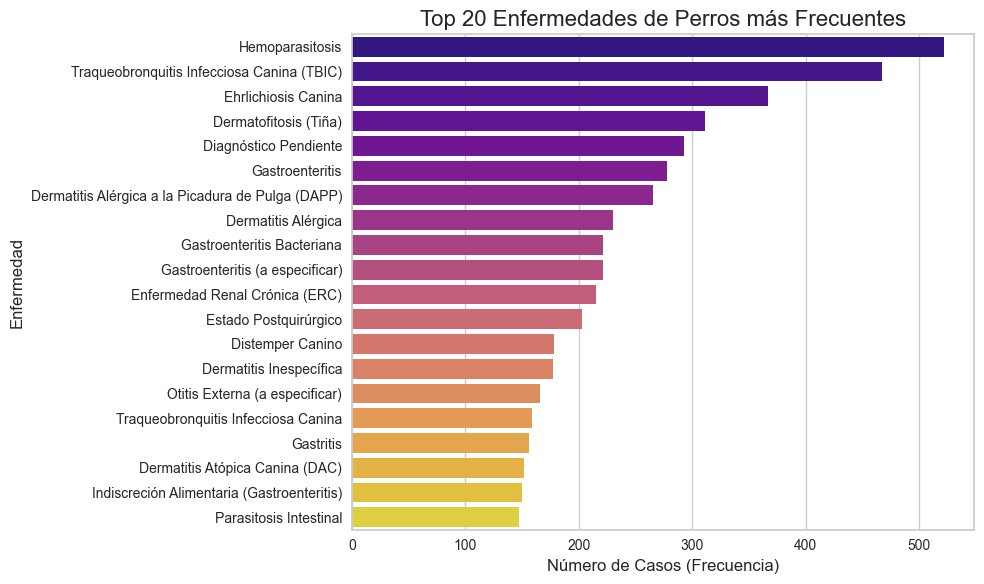

In [16]:
# 1. Filtrar el DataFrame para obtener solo registros donde la especie original sean 'Caninos'

# 2. Contar la frecuencia de las razas de perros
razas_perros_conteo = df['enfermedades'].value_counts()

# 3. Obtener el Top 10 de razas de perros y eliminar los nulos (razas no identificadas dentro de los "Perro")
top_razas_conteo = razas_perros_conteo.head(20).dropna()

# 4. Calcular el porcentaje dentro de la población de perros clasificados
porcentajes_razas = (top_razas_conteo / razas_perros_conteo.sum()) * 100

# Crear un DataFrame para la presentación tabular
top_razas_df = pd.DataFrame({
    'Frecuencia': top_razas_conteo,
    'Porcentaje (%)': porcentajes_razas.round(2)
})

print("\n🐕 Top 20 Enfermedades de Perros más frecuentes:")
print(top_razas_df)

# Gráfico de barras para el Top 10 de Razas de Perros
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_razas_conteo.values, 
    y=top_razas_conteo.index, 
    palette='plasma'
)
plt.title('Top 20 Enfermedades de Perros más Frecuentes', fontsize=16)
plt.xlabel('Número de Casos (Frecuencia)', fontsize=12)
plt.ylabel('Enfermedad', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25143 entries, 0 to 26889
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   nombre          25143 non-null  object
 1   observacion     10427 non-null  object
 2   pronostico      13874 non-null  object
 3   recomendacion   24898 non-null  object
 4   fecha_ingreso   25134 non-null  object
 5   fecha_atencion  25134 non-null  object
 6   enfermedad      25093 non-null  object
 7   especie         25143 non-null  object
 8   raza            25143 non-null  object
 9   enfermedades    13446 non-null  object
dtypes: object(10)
memory usage: 2.1+ MB


In [18]:
#Estandarización de variable pronóstico

In [19]:
pronostico_normalizado = {
    'bueno': 'FAVORABLE',
    'BUENO': 'FAVORABLE',
    'Bueno con manejo': 'FAVORABLE',
    'Bueno, favorable': 'FAVORABLE',
    'Bueno.': 'FAVORABLE',
    'BUENO, CON TRATAMIENTO': 'FAVORABLE',
    'Bueno con tratamiento. Podría quedar  como portador sano algunas semanas.': 'FAVORABLE',
    'Bueno': 'FAVORABLE',
    'BUENO SI SE REALIZA EL TRATAMIENTO ADECUADO.\nPUEDE RECIDIVAR SI VUELVE A TENER CONTACTO CON EL CONTAMINANTE': 'FAVORABLE',
    'Bueno con tratamiento y extracción de piezas dentales': 'FAVORABLE',
    'El pronostico es bueno': 'FAVORABLE',
    'ESTA BIEN': 'FAVORABLE',
    'ESTA EN BUEN ESTADO': 'FAVORABLE',
    'Bueno. Con tratamiento': 'FAVORABLE',
    'Bueno con diagnostico.': 'FAVORABLE',
    'BUENO, PERO SE DEBE SER CONSTANTE EN EL TRATAMIENTO Y CON LAS RECOMENDACIONES.': 'FAVORABLE',
    'Paciente se puede recuperar facilmente (Bueno)': 'FAVORABLE',
    'Bueno, requiere control para reevaluar su dolor': 'FAVORABLE',
    'BUENO.': 'FAVORABLE',
    'Buen Pronóstico.': 'FAVORABLE',
    'BUENO, PERO SE RECOMIENDA DIAGNOSTICAR.': 'FAVORABLE',
    'BUENO CON TRATAMIENTO.\nPUEDE REQUERIR EXAMENE COMPLEMENTARIOS SI PERSISTE EL PROBLEMA.': 'FAVORABLE',
    'BUENO CON TRATAMIENTO': 'FAVORABLE',
    'BUENO. EL AQUADENT SE SUMINISTRA EN EL AGUA DE BEBIDA.': 'FAVORABLE',
    'BUENO CON TRATAMIENTO, ESTE PACIENTE NO TIENE AUN DIAGNOSTICO, SE DEBE DESCARTAR ARTROSIS MEDIANTE RADIOGRAFÍA.': 'FAVORABLE',
    'bueno se le recomienda traer el 4 de abril para control': 'FAVORABLE',
    'bueno esta animada': 'FAVORABLE',
    'Muy bueno': 'FAVORABLE',
    'Bueno, con cirugia': 'FAVORABLE',
    'BUENO SI SE TRATA AL PIE DE LA LETRA.Y LAS INDICACIONES DEL MEDICO TRATANTE.': 'FAVORABLE',
    'Es bueno,  si se trata al pie de la letra.': 'FAVORABLE',
    'BUENO,.': 'FAVORABLE',
    'BUENO SI SE ADMINISTRA EL TRATAMIENTO COMPLETO': 'FAVORABLE',
    'normal': 'FAVORABLE',
    'bueno si se trata a tiempo': 'FAVORABLE',
    'BUENO/': 'FAVORABLE',
    'Bueno solo suministrar bien los medicamentos': 'FAVORABLE',
    'BUENO SI SE SIGUE LAS INSTRUCCIONES': 'FAVORABLE',
    'BUNEO': 'FAVORABLE',
    '1. Bueno': 'FAVORABLE',
    'Favorable/Bueno': 'FAVORABLE',
    '*BUENO': 'FAVORABLE',
    'BUENO SIEMPRE Y CUANDO SU PROPIETARIO NO SUSPENDA EL TRATAMIENTO.': 'FAVORABLE',
    'Bueno con la administración del medicamento.': 'FAVORABLE',
    'favorable /Bueno': 'FAVORABLE',
    'BUENO EN LA PARTE DE LA HERIDA': 'FAVORABLE',
    'BUENO A RESERVADO DEPENDE DE LOS CUIDADOS EN CASA Y QUE LA MEDICACIÓN SEA SUMINISTRADA COMPLETAMENTE': 'FAVORABLE',
    'BUENO SI NO HAY REOBSTRUCCION': 'FAVORABLE',
    'BUENO SI HACEN LAS RECOMENDACIONES': 'FAVORABLE',
    'Bueno, pero realizando el tratamiento prescrito por el profesional.': 'FAVORABLE',
    'I. BUENO': 'FAVORABLE',
    'Buneo': 'FAVORABLE',
    'BUENO SI SE TRATA': 'FAVORABLE',
    'Bueno, requiere corrección quirúrgica': 'FAVORABLE',
    'Bueno .': 'FAVORABLE',
    '*Bueno': 'FAVORABLE',
    'Buena': 'FAVORABLE',
    'Buen pronóstico': 'FAVORABLE',
    'excelente': 'FAVORABLE',
    'OPTIMO': 'FAVORABLE',
    'I. BUENO': 'FAVORABLE',
    'BUENO. SEGUN LABORATORIOS SE COMPLEMENTARA MANEJO E INDICACIONES A SEGUIR': 'FAVORABLE',
    'BUENO PARA LA FUNCION RENAL': 'FAVORABLE',
    'Bueno, excelente manejo de la enfermedad las crisis y los agravantes.': 'FAVORABLE',
    'BUENO, CON TRATAMIENTO COMPLETO': 'FAVORABLE',
    'BUENO si realizan los tratamientos puntuales.': 'FAVORABLE',
    'bueno, si realizan el tratamiento y los cambios en la dieta.': 'FAVORABLE',
    'I. BUENO': 'FAVORABLE',
    'beuno si se realiza el taratamiento': 'FAVORABLE',
    'BUENO HASTA EVALUAR RESULTADOS.': 'FAVORABLE',
    'Reservado a nivel oftalmológico. \nBueno en general.': 'FAVORABLE',
    'Bueno, siempre y cuando se sigan las recomendaciones y la formula.': 'FAVORABLE',
    'I. Bueno.': 'FAVORABLE',
    'I. Bueno': 'FAVORABLE',
    'BUENO PARA LA ERC IRIS 1 O 2. QUE NO PRODUCEN SINTOMATOLOGIA NI RIESGO VITAL. POSIBLEMENTE HAYA UNA INFECCION RENAL PERSISTENTE.': 'FAVORABLE',
    'bueno si responde a corto plazo al tratamiento': 'FAVORABLE',
    'BUENO SI SE DESPARASITA Y NO TIENE HONGOS, ACAROS NI BACTERIAS': 'FAVORABLE',
    'BEUNO': 'FAVORABLE',
    'Buenos': 'FAVORABLE',
    '1. Bueno': 'FAVORABLE',
    'NORMAL': 'FAVORABLE',
    'BUENO. SEGUN LABORATORIOS SE COMPLEMENTARA MANEJO E INDICACIONES A SEGUIR': 'FAVORABLE',
    'Visual bueno \nNeurológico reservado': 'FAVORABLE',
    'Visual bueno \nEstético bueno': 'FAVORABLE',
    'Visual malo\nEstético bueno': 'FAVORABLE',
    'Bueno (si se realiza el monitoreo constante del paciente, idealmente si es crónico estable realizar exámenes y chequeo 1-2 veces al año)': 'FAVORABLE',
    'RESERVADO PARA LA SITUACION DIGESTIVA. BUENO PARA LA RENAL.': 'FAVORABLE',
    'Bueno, siempre y cuando se sigan todas las recomendaciones.': 'FAVORABLE',
    'I. Bueno': 'FAVORABLE',
    'BUENO PARA LA FUNCION RENAL': 'FAVORABLE',
    'bueno para la enfermedad renal iris 2. pendiente evaluar comorbilidades': 'FAVORABLE',
    'Todo correcto': 'FAVORABLE',
    'bueno ': 'FAVORABLE',
    'bien': 'FAVORABLE',
    'BUENI': 'FAVORABLE',
    'Visual bueno \nEstético bueno': 'FAVORABLE',
    'FAVORABLE': 'FAVORABLE',
    'favorable': 'FAVORABLE',
    'FAVORABLES': 'FAVORABLE',
    'FAVOR': 'FAVORABLE',
    'fAVORABLE': 'FAVORABLE',
    'Es Favorable': 'FAVORABLE',
    'FAVORABLE. DEPENDIENTE DEL TIEMPO.': 'FAVORABLE',
    'FAVORABLE MUY FAVORABLE.': 'FAVORABLE',
    'favorable.': 'FAVORABLE',
    '-Favorable': 'FAVORABLE',
    'FAVORABLR': 'FAVORABLE',
    'FEVORABLE': 'FAVORABLE',
    'FAVORBALE': 'FAVORABLE',
    'favorable si no persiste la diarrea': 'FAVORABLE',
    'favorable si mejora signos clinicos': 'FAVORABLE',
    'FAVORABLE SI NO PERSISTEN LAS CONVULSIONES': 'FAVORABLE',
    'Favorable con medicación.': 'FAVORABLE',
    'Favorable con medicación': 'FAVORABLE',
    'Favorable con tratamiento': 'FAVORABLE',
    '- favorable': 'FAVORABLE',
    '. Favorable': 'FAVORABLE',
    '*Favorable': 'FAVORABLE',
    'FVORABLE': 'FAVORABLE',
    'FABORABLE': 'FAVORABLE',
    'FAVORABLE CON TRATAMIENTO': 'FAVORABLE',
    'favorable reexaminacion via telefonica cada 5 dias.': 'PENDIENTE/EVALUACION',
    '1. Favorable': 'FAVORABLE',
    'Favorable con corrección quirúrgica de la lesión': 'FAVORABLE',
    'Favorable posterior a la cirugía ortopédica.': 'FAVORABLE',
    'FAVORABLE .': 'FAVORABLE',
    'Favorabe': 'FAVORABLE',
    'Favorable dependiente de las radiografías y la cirugía.': 'FAVORABLE',
    'favorable si realiza el trataminto completo': 'FAVORABLE',
    'I. FAVORABLE': 'FAVORABLE',
    'Favorable (se requiere realizar un perfil de chequeo).': 'FAVORABLE',
    'Favorable si realizan el tratamiento': 'FAVORABLE',
    'Favorable (se recomienda realizar coproparasitológico de control dentro de 20 días a el y al otro gato con el que convive).': 'FAVORABLE',
    'Favorable, puede ser necesario realizar hisopado de lesiones para cultivo e identificación mico/bact.': 'FAVORABLE',
    'Favorable, se debe realizar detartraje.': 'FAVORABLE',
    'Favorable, paciente debe perder como mínimo 5 kilogramos de peso.': 'FAVORABLE',
    'Favorable con el seguimiento de indicaciones medicas.': 'FAVORABLE',
    'Favorable luego de la cirugía': 'FAVORABLE',
    'Favorable con medicación y quimioterapia': 'FAVORABLE',
    'Favorable con cirugía y medicación': 'FAVORABLE',
    'FAvorable': 'FAVORABLE',
    'favorable con tratamiento.': 'FAVORABLE',
    'favorable con tratamiento oportuno': 'FAVORABLE',
    'FAVORBLE.': 'FAVORABLE',
    'FAVOABLE': 'FAVORABLE',
    'Favorable si realizan el tratamiento y cambian la dieta.': 'FAVORABLE',
    'Favorable con remisión a especialista y cirugía correctiva.': 'FAVORABLE',
    'Favorable con cuidados postoperatorios.': 'FAVORABLE',
    'Favorable en cada control': 'FAVORABLE',
    'Favorable con medicación y/u hospitalización.': 'FAVORABLE',
    'FAVORABLE CON REQUERIMIENTOS': 'FAVORABLE',
    'Favorable luego de la cirugía': 'FAVORABLE',
    'Favorable, puede ser necesario realizar citología de la lesión.': 'FAVORABLE',
    'Favorable, se debe realizar detartraje.': 'FAVORABLE',
    'Favorable con vacunación.': 'FAVORABLE',
    'Favorable, de acuerdo a evolucion y recomendaciones medicas.': 'FAVORABLE',
    'FAVORLABLE': 'FAVORABLE',
    'Favorable, siempre y cuando se de continuidad al tratamiento.': 'FAVORABLE',
    'MUY FAVORABLE': 'FAVORABLE',
    'Favorable (se requiere test de fluoresceína)': 'FAVORABLE',
    'Favorable con medicación y cirugía': 'FAVORABLE',
    'favorable con tratamiento': 'FAVORABLE',
    'favorable con medicación': 'FAVORABLE',
    'Favorable*** a la espera de los resultados de histopatologia.': 'FAVORABLE',
    'Favorable si realizan todo el tratamiento.': 'FAVORABLE',
    'Favorable, siguiendo al pie de la letra las recomendaciones.': 'FAVORABLE',
    'Favorable (en caso de no presentar mejoría con esta medicación podría ser necesario debridar tejido).': 'FAVORABLE',
    'gris': 'DESFAVORABLE',
    'DESFAVORABLE SIN TRATAMIENTO.': 'DESFAVORABLE',
    'MAL ESTADO': 'DESFAVORABLE',
    'DESFAVORABLE': 'DESFAVORABLE',
    'MALO': 'MALO',
    'Malo': 'MALO',
    'malo': 'MALO',
    'ESTADO MUY GRAVE': 'MALO',
    '*MALO': 'MALO',
    'riesgo vital alto': 'MALO',
    'pobre': 'MALO',
    'I. MALO': 'MALO',
    'DADA LAS CONDICIONES FISICAS DEL PACIENTE Y EL DIAGNOSTICO PRESUNTIVO EL PRONOSTICO ES MALO': 'MALO',
    'MALO\nFAMILIA DECIDE TRATAR DE FORMA PALIATIVA': 'MALO',
    'I. Malo': 'MALO',
    'MALO.': 'MALO',
    'Malo. Familiar opta por la opción de eutanasia humanitaria': 'MALO',
    'DESAFAVORABLE': 'MALO',
    'LA PACIENTE TIENE UN PRONOSTICO NEGATIVO POR EL TIPO DE TUMOR DIAGNOSTICADO.': 'MALO',
    'Reservado': 'RESERVADO',
    'reservado': 'RESERVADO',
    'RESERVADO': 'RESERVADO',
    'RESERVADO,': 'RESERVADO',
    'Reservado.': 'RESERVADO',
    'RESERVADO.': 'RESERVADO',
    'reservado.': 'RESERVADO',
    'rESERVADO': 'RESERVADO',
    'RESEERVADO': 'RESERVADO',
    'RESERVBADO': 'RESERVADO',
    'reservadol': 'RESERVADO',
    '1. Reservado': 'RESERVADO',
    '- Reservado': 'RESERVADO',
    '*Reservado': 'RESERVADO',
    '* Reservado': 'RESERVADO',
    'RESERVADO-': 'RESERVADO',
    'Reservada': 'RESERVADO',
    'RESEVADO': 'RESERVADO',
    'RESERVADA': 'RESERVADO',
    '-Reservado': 'RESERVADO',
    'Resevardo': 'RESERVADO',
    'RESERVADO..': 'RESERVADO',
    'Resverado': 'RESERVADO',
    'RESERVADO*': 'RESERVADO',
    'RESRVADO': 'RESERVADO',
    '1.Reservado': 'RESERVADO',
    'Revervado': 'RESERVADO',
    'reservao': 'RESERVADO',
    'RESERVARDO': 'RESERVADO',
    'RESERVADOS': 'RESERVADO',
    'Reserado': 'RESERVADO',
    'RESERVADI': 'RESERVADO',
    'REeservado': 'RESERVADO',
    'RESREVADO': 'RESERVADO',
    'Reserevado.': 'RESERVADO',
    'RESERVADOO': 'RESERVADO',
    'RESERVADO AUN': 'RESERVADO',
    'Resevado': 'RESERVADO',
    'Resrvado': 'RESERVADO',
    'RESERVADDO': 'RESERVADO',
    'resevardo': 'RESERVADO',
    'resrevado': 'RESERVADO',
    'REservado': 'RESERVADO',
    'RECORVADO': 'RESERVADO',
    'R': 'PENDIENTE/EVALUACION',
    'I. RESERVADO': 'RESERVADO',
    'Resrvado.': 'RESERVADO',
    'Resverado': 'RESERVADO',
    'Reservación': 'RESERVADO',
    'Reservado a Malo': 'MALO',
    'reservado/malo': 'MALO',
    'RESERVADO A MALO': 'MALO',
    'reservado a malo': 'MALO',
    'reservado-malo': 'MALO',
    'RESERVADO - MALO': 'MALO',
    'Reservado malo': 'MALO',
    '1. RESERVADO-MALO': 'MALO',
    '1. Reservado-Malo': 'MALO',
    'RESERVADO MALO': 'MALO',
    'RESERVADO/DESFAVORABLE.': 'MALO',
    'RESERVADO/DESFAVORABLE': 'MALO',
    'RSERVADO/DESFAVORABLE': 'MALO',
    'RESERVADO A DESFAVORABLE': 'MALO',
    'RESERVADO - DESFAVORABLE': 'MALO',
    'reservado-desfavorable': 'MALO',
    'Reservado- Desfavorable': 'MALO',
    'RESERVADO/ MAL PRONOSTICO.': 'MALO',
    'RESERVADO- DESFAVORABLE': 'MALO',
    'reservado_malo': 'MALO',
    'RESERVADO / DESFAVORABLE': 'MALO',
    'Reservado - Malo': 'MALO',
    'Reservado/ desfavorable': 'MALO',
    'Reservado-malo': 'MALO',
    'RESERVADO-MALO': 'MALO',
    'I. RESERVADO-MALO.': 'MALO',
    'Reservado / Malo': 'MALO',
    'Reservado a malo. Aprox 20% de probabilidades de éxito.': 'MALO',
    'RESERVADO A MALO SIN HOSPITALIZACION.': 'MALO',
    'reservado a malo. Aproximadamente 10% de sobrevida': 'MALO',
    'Reservado a favorable': 'FAVORABLE',
    'RESERVADO/FAVORABLE': 'FAVORABLE',
    'reservado a bueno': 'FAVORABLE',
    'BUENO/RESERVADO': 'FAVORABLE',
    'Bueno - Reservado': 'FAVORABLE',
    'Reservado-Bueno': 'FAVORABLE',
    'RESERVADO - BUENO': 'FAVORABLE',
    'RESERVADO/ BUENO': 'FAVORABLE',
    'De reservado a bueno.': 'FAVORABLE',
    'Reservado a Bueno.': 'FAVORABLE',
    'Reservado a Bueno': 'FAVORABLE',
    'RESERVADO/FAVORABLE.': 'FAVORABLE',
    'reservado - favorable': 'FAVORABLE',
    'reservado/favorable': 'FAVORABLE',
    'Reservado/Favorable': 'FAVORABLE',
    'Reservado / Favorable': 'FAVORABLE',
    'Reservado-Favorable': 'FAVORABLE',
    'RESERVADO/FAORABLE.': 'FAVORABLE',
    'Reservado /  Favorable': 'FAVORABLE',
    'RESERVADO - FAVORABLE': 'FAVORABLE',
    'Reservado-favorable': 'FAVORABLE',
    'RESERVADO- FAVORABLE': 'FAVORABLE',
    'RESERVADO/BUENO': 'FAVORABLE',
    'Reservado / Bueno': 'FAVORABLE',
    'Reservado -FAVORABLE': 'FAVORABLE',
    'Favorable a Reservado': 'FAVORABLE',
    'RESERVADO A FAVORABLE': 'FAVORABLE',
    'RESERVADO A FAVORABLE.': 'FAVORABLE',
    'BUENO/FAVORABLE': 'FAVORABLE',
    'reservado / a la espera de resultados de laboratorio': 'FAVORABLE',
    'RESERVADO A BUENO': 'FAVORABLE',
    'Bueno a Reservado': 'FAVORABLE',
    'Bueno- Reservado': 'FAVORABLE',
    'RESERVADO- BUENO': 'FAVORABLE',
    'Reservado- Favorable': 'FAVORABLE',
    'Reservado A bueno': 'FAVORABLE',
    'Reservado abueno': 'FAVORABLE',
    'Reservado -favorable': 'FAVORABLE',
    'Rerservado a Bueno': 'FAVORABLE',
    'Reservardo a bueno': 'FAVORABLE',
    'Reservado- Bueno': 'FAVORABLE',
    'reservado a Bueno': 'FAVORABLE',
    'reservado a favorable': 'FAVORABLE',
    'REGULAR': 'DESFAVORABLE',
    'regular': 'DESFAVORABLE',
    'MODERADO': 'DESFAVORABLE',
    'Moderado': 'DESFAVORABLE',
    'Moderado o intermedio': 'DESFAVORABLE',
    'REGULAR-BUENO': 'DESFAVORABLE',
    'REGULAR A BUENO': 'DESFAVORABLE',
    'REGULAR-MALO': 'DESFAVORABLE',
    'regular - malo': 'DESFAVORABLE',
    'REGULAR - MALO': 'DESFAVORABLE',
    'BUENO CON CIRUGIA. REGULAR CON MANEJO MEDICO': 'DESFAVORABLE',
    'REGULAR - BUENO': 'DESFAVORABLE',
    'regular - bueno': 'DESFAVORABLE',
    'regular - reservado': 'DESFAVORABLE',
    'regular-malo': 'MALO',
    np.nan: 'PENDIENTE/EVALUACION',
    "nan": 'PENDIENTE/EVALUACION',
    'Alguno': 'PENDIENTE/EVALUACION',
    'OOQUISTES DE COCCIDIA': 'PENDIENTE/EVALUACION',
    'Purebas': 'PENDIENTE/EVALUACION',
    'prueba': 'PENDIENTE/EVALUACION',
    'RESERVADO HASTA OBTENER UN DIAGNOSTICO': 'PENDIENTE/EVALUACION',
    'POSIBLE FRACTURA': 'PENDIENTE/EVALUACION',
    'EN OBSERVACION, DEBE TRAER A CONTROL': 'PENDIENTE/EVALUACION',
    'SIN PRONOSTICO': 'PENDIENTE/EVALUACION',
    'debe presentar mejoria en  5 dias': 'PENDIENTE/EVALUACION',
    'SEGÚN EVOLUCIÓN': 'PENDIENTE/EVALUACION',
    'DEBE PRESENTAR MEJORÍA EN 3 DÍAS': 'PENDIENTE/EVALUACION',
    'SE ESPERA LOS EXÁMENES PARA VALORACIÓN DE DICTAMEN': 'PENDIENTE/EVALUACION',
    'Debe presentar mejoría en 4 días': 'PENDIENTE/EVALUACION',
    'EN 5 DIAS DEBERIA PRESENTAR MEJORIA Y RETIRO DE PUNTOS EN 10 DIAS': 'PENDIENTE/EVALUACION',
    'SE DEBÍA PRESENTAR MEJORÍA EN 3 DÍAS, SE TRAJO A CONTROL EL DÍA 14/02/2019 Y SIGUE MUCHO MEJOR.': 'PENDIENTE/EVALUACION',
    'DEBE PRESENTAR MEJORÍA EN 10 DÍAS A PARTIR DEL 12/02/2019': 'PENDIENTE/EVALUACION',
    'se espera evolución de la mascota': 'PENDIENTE/EVALUACION',
    'debe presentar mejoría en una semana \nse recomienda traer el próximo miércoles para valoración': 'PENDIENTE/EVALUACION',
    'TRAER A CONTROL PARA VALORACIÓN EN 3 DÍAS Y REALIZAR INYECTOLOGIA DE INMIZOL': 'PENDIENTE/EVALUACION',
    'SE ESPERA EVOLUCION A FAVOR': 'PENDIENTE/EVALUACION',
    'SE REQUIERE EXÁMENES PARA VALORACIÓN': 'PENDIENTE/EVALUACION',
    'SE LE RECOMENDÓ HACER EXÁMENES ANTES DE ENTRAR A CIRUGÍA': 'PENDIENTE/EVALUACION',
    'Sin pronostico': 'PENDIENTE/EVALUACION',
    'SE RECOMIENDA TRAER A CONTROL UNA SEMANA': 'PENDIENTE/EVALUACION',
    'SE ESPERA RESULTADO DEL HEMOGRAMA PARA COMPLEMENTAR EXÁMENES': 'PENDIENTE/EVALUACION',
    'DESCONOCIDO, HASTA QUE NO TENGAMOS DIAGNOSTICO': 'PENDIENTE/EVALUACION',
    'SE REQUIRE EXAMEN': 'PENDIENTE/EVALUACION',
    '*Mantener faja post-quirurgica hasta el retiro de puntos*\n*Meloxipet con ingesta de comida*': 'PENDIENTE/EVALUACION',
    'Curabitur finibus sollicitudin enim sit amet tempus. Pellentesque orci risus, consectetur eu tempor vel, tincidunt non diam. Phasellus congue velit gravida odio posuere venenatis. Phasellus pulvinar augue imperdiet dui eleifend, rutrum maximus eros pellentesque. Ut ipsum sapien, accumsan eget congue sit amet, bibendum ac nunc. Vestibulum porta ultrices tellus ac tincidunt.\n\n Proin hendrerit venenatis nisi non scelerisque. Curabitur vitae magna accumsan elit varius lacinia ut quis tellus. Nunc fermentum purus rhoncus purus gravida sodales. Cras lacinia augue id maximus lacinia.': 'PENDIENTE/EVALUACION',
    'Ligado a tratamiento médico': 'PENDIENTE/EVALUACION',
    'Ligado al término del tratamiento.': 'PENDIENTE/EVALUACION',
    'ninguno': 'PENDIENTE/EVALUACION',
    'Pruebas recorvet 2': 'PENDIENTE/EVALUACION',
    'Ligado a resultados de exámenes y evolución del tratamiento.': 'PENDIENTE/EVALUACION',
    'Esperar resultados': 'PENDIENTE/EVALUACION',
    'tal cosa': 'PENDIENTE/EVALUACION',
    'nionguno': 'PENDIENTE/EVALUACION',
    'Pronóstico': 'PENDIENTE/EVALUACION',
    'TRAER EN 8 DÍAS A CONTROL': 'PENDIENTE/EVALUACION',
    'Pruebas JT': 'PENDIENTE/EVALUACION',
    'SUPLEMENTAR CON  CARNE COCIDA': 'PENDIENTE/EVALUACION',
    'gastroenteritis ideopatica': 'PENDIENTE/EVALUACION',
    'NO SE ES PACIENTE DE ALEX.': 'PENDIENTE/EVALUACION',
    'Pruebas 2': 'PENDIENTE/EVALUACION',
    'Pro': 'PENDIENTE/EVALUACION',
    'pronostico aqui': 'PENDIENTE/EVALUACION',
    'RESERVADO\nLOS EXAMENES DE SANGRE EVIDENCIAN UNA LEUCOPENIA Y TROMBOCITOPENIA MARCADA, SIN CONTEO DIFERENCIA, LEVE AUMENTO DE ALT Y BILIRRUBINA DIRECTA': 'PENDIENTE/EVALUACION',
    'RESERVADO HASTA REPETIR RECUENTO DE PLAQUETAS': 'PENDIENTE/EVALUACION',
    'depende del diagnostico radiologico': 'PENDIENTE/EVALUACION',
    'en proceso': 'PENDIENTE/EVALUACION',
    'desfavorable si persiste el edema y congestión pulmonar': 'PENDIENTE/EVALUACION',
    'SE INDICA TRAER CADA 20 A 30 DIAS A CONTROL DE PIEL': 'PENDIENTE/EVALUACION',
    'reservado si persiste la enfermedad de tracto urinario': 'PENDIENTE/EVALUACION',
    '-Se sugiere realizar limpiezas con agua de caléndula  y gasa antes de aplicar las gotas en cada ojo. \n-Usar sólo uno de los medicamentos en la lista\n-Se sugiere realizar profilaxis de manera URGENTE': 'PENDIENTE/EVALUACION',
    'en recuperacion': 'PENDIENTE/EVALUACION',
    'Se sugiere realizar exámenes de laboratorio (perfil geriátrico) ecografía abdominal para confirmar y /o descartar piometra, se sugirió hospitalización. \nEn caso de ser necesario se manifiesta la urgencia de operar de manera urgente': 'PENDIENTE/EVALUACION',
    'ESPERAR': 'PENDIENTE/EVALUACION',
    'Se remite paciente para hospitalizacion.\nPaciente renal': 'PENDIENTE/EVALUACION',
    'RESERVADO POR ENFERMEDAD CRÓNICA TRATABLE PERO NO CURABLE': 'RESERVADO',
    'RESERVADO ENFERMEDAD CRÓNICA TRATABLE PERO NO CURABLE': 'RESERVADO',
    'RESERVADO SI NO PRESENTA EVOLUCIÓN FAVORABLE RESPECTO AL CONSUMO DE ALIMENTO Y DEPOSICIÓN EN LAS PRÓXIMAS 48 A 72 HRS': 'PENDIENTE/EVALUACION',
    'FAVORABLE CON TRATAMIENTO ENFERMEDAD CRÓNICA TRATABLE PERO NO CURABLE': 'RESERVADO',
    'Menos Grave': 'DESFAVORABLE',
    'favorable.\nCuadro hematico control ( 05/05/20)': 'PENDIENTE/EVALUACION',
    'Reservado, esperar evolución.': 'PENDIENTE/EVALUACION',
    'RESERVADO EN ESPERA DE EVOLUCIÓN': 'PENDIENTE/EVALUACION',
    'A ESPERA DE RESULTADOS': 'PENDIENTE/EVALUACION',
    'Repetir cuadro hematico en 10 días y al finalizar el tratamiento\n\nRealizar alt y creatinina': 'PENDIENTE/EVALUACION',
    'Se debe realizar radiografía de cadera con dos vistas': 'PENDIENTE/EVALUACION',
    'Si el paciente continua sin comer se debe hospitalizar': 'PENDIENTE/EVALUACION',
    'Realizar cuadro hematico semanal hasta terminar tratamiento': 'PENDIENTE/EVALUACION',
    'Si el paciente no mejora se debe realizar radiografía de columna y cadera.': 'PENDIENTE/EVALUACION',
    'Retiro de puntos en 12 dias.': 'PENDIENTE/EVALUACION',
    'RESERVADO SI RESPUESTA A TRATAMIENTO CONSERVADOR NO ES FAVORABLE': 'PENDIENTE/EVALUACION',
    'Regular': 'DESFAVORABLE',
    'conjuntivitis': 'PENDIENTE/EVALUACION',
    'ANEMIA.': 'PENDIENTE/EVALUACION',
    'estos son pronósticos': 'PENDIENTE/EVALUACION',
    'RESERVADO HASTA OBTENER RESULTADOS DE HISTOPATOLOGIA': 'PENDIENTE/EVALUACION',
    'Este es el pronostico': 'PENDIENTE/EVALUACION',
    'RESERVADO/BUENO \nSE OBSERVA LECOPENIA Y ANEMIA MODERADA': 'FAVORABLE',
    'Reservado (falta de diagnóstico definitivo)': 'PENDIENTE/EVALUACION',
    'BUENO SI ES IRIS 2\nREGULAR SI ES IRIS 3': 'DESFAVORABLE',
    'PARA RIÑONES: BUENO\n\nCONSIDERAR QUE LA MYCOPLASMOSIS ES UNA ENFERMEDAD INCIDIOSA': 'FAVORABLE',
    'PARA RIÑONES: EXCELENTE.\nCONSIDERARA QUE LA PODODERMATITIS ES UNA ENFERMEDAD INSIDIOSA': 'FAVORABLE',
    'Pendiente compensar enfermedad renal y estadificar\nPendiente SDMA y pruebas complementarias': 'PENDIENTE/EVALUACION',
    'Riñones: Bueno': 'FAVORABLE',
    'Pendiente acorde a resultado de examenes': 'PENDIENTE/EVALUACION',
    'pendiente por definir': 'PENDIENTE/EVALUACION',
    'PENDIENTE POR DEFINIR': 'PENDIENTE/EVALUACION',
    'A espera de resultado de exámenes': 'PENDIENTE/EVALUACION',
    'A espera de cirugia para realizar ovh y extraccion de tumores mamarios.': 'PENDIENTE/EVALUACION',
    'Para Riñones: Bueno\nPara Vejiga: A espera de respuesta con tratamiento': 'FAVORABLE',
    'A espera de resultados de laboratorio': 'PENDIENTE/EVALUACION',
    'Reservado (A espera de toma de exámenes y resultados)\n\nSe recomienda dejar paciente en hospitalizacion o manejo de medicación endovenosa ambulatoria.\n\nObjetivos a corto plazo: Asegurar vía oral / nutrición kg/día (tubo esofagico).': 'PENDIENTE/EVALUACION',
    'reservado sujeto a controles': 'PENDIENTE/EVALUACION',
    'PRONÓSTICO DELICADO.': 'MALO',
    'RESERVADO POR MÚLTIPLES PATOLOGÍAS': 'RESERVADO',
    'Reservado con medicación.': 'PENDIENTE/EVALUACION',
    'en espera de resultados de examens y ecografia': 'PENDIENTE/EVALUACION',
    'ALTERACION RENAL POR EXCESO DE PROTEINA EN LA DIETA': 'PENDIENTE/EVALUACION',
    'Reservado hasta tener diagnostico': 'PENDIENTE/EVALUACION',
    'favorable - a la espera de resultados de histopatología': 'PENDIENTE/EVALUACION',
    'reservado hasta esclarecer etiologia': 'PENDIENTE/EVALUACION',
    'reservado ( posible perdida de esfinteres)': 'RESERVADO',
    'RESERVADO HASTA RESOLVER COMPLETAMENTE LA CISTITIS': 'PENDIENTE/EVALUACION',
    'Reservado por la edad': 'RESERVADO',
    'Bueno; Manejo de nefropatia con fluidos. Garantizar hidratacion continua.': 'FAVORABLE',
    'Glicemia pre (64) y post prandial (86)': 'PENDIENTE/EVALUACION',
    'A espera de resultados de sangre': 'PENDIENTE/EVALUACION',
    'Reservado \nPresion arterial: SIS 126, DIA 61, PAM 76, HR 158': 'PENDIENTE/EVALUACION',
    'Reservado hasta obtención de resultados y emisión de diagnóstico definitivo': 'PENDIENTE/EVALUACION',
    'Reservado (paciente positivo a Vilef con antecedentes de linfoma)': 'RESERVADO',
    'FECHA TENTATIVA DE PARTO \nFINALES DE AGOSTO COMIENZOS DE SEPTIEMBRE': 'PENDIENTE/EVALUACION',
    'A espera de resultados de exámenes complementarios.': 'PENDIENTE/EVALUACION',
    'RESERVADO \nPRESENTA DESHIDRATACION, FIEBRE, DOLOR ABDOMINAL, DISTENSION GASTRICA.': 'RESERVADO',
    'gastroenteritis alimentaria': 'PENDIENTE/EVALUACION',
    'Reservado. Esperar evolución del paciente por el tiempo que lleva enfermo y sin ser tratado': 'RESERVADO',
    'hemoparasitos': 'PENDIENTE/EVALUACION',
    'A la espera de histopatologia': 'PENDIENTE/EVALUACION',
    'Reservado sin cirugía': 'RESERVADO',
    'Reservado, paciente critico.': 'MALO',
    'Paciente no responde a terapia intensiva intrahospitalaria, pronostico malo, se recomienda tomar decisión de eutanasia en un plazo máximo no mayor a 24 horas.': 'MALO',
    'Reservado. Depende de los resultados y evolución de la paciente': 'PENDIENTE/EVALUACION',
    'Reservado : depende de la evolución': 'PENDIENTE/EVALUACION',
    'reservado, pendiente descartar problemas gastroentéricos.': 'PENDIENTE/EVALUACION',
    'Reservado (Enfermedad crónica tratable pero no curable)': 'RESERVADO',
    'Requiere exámenes de control trombocitopenia y de orina': 'PENDIENTE/EVALUACION',
    'segun respuesta al tratamiento completo  se determinara': 'PENDIENTE/EVALUACION',
    'Otitis producida por humedad': 'PENDIENTE/EVALUACION',
    'SEGUN MEJORÍA SE EVALUARÁ INTERCONSULTA POR NEUROLOGIA': 'PENDIENTE/EVALUACION',
    'reservado  ya que es una paciente q debe estar en control toda su vida.': 'RESERVADO',
    'RESERVADO (DURANTE 72 HRS)': 'PENDIENTE/EVALUACION',
    'Reservado por presencia de comorbilidades': 'RESERVADO',
    'DEPENDE DE RESPUESTA AL TRATAMIENTO. PENDIENTES VARIAS MEDICINAS SEGUN RESPUESTA (BLADURIL Y PENTOXIFILINA).': 'PENDIENTE/EVALUACION',
    'Por definir': 'PENDIENTE/EVALUACION',
    'proceso viral \nparasitos': 'PENDIENTE/EVALUACION',
    'Reservado\nPigmentación corneal puede requerir remisión a oftalmólogo.\nNeoformación submandibular puede requerir citología o histopatología.': 'PENDIENTE/EVALUACION',
    'Reservado (Paciente requiere hospitalzación y complementarios).': 'PENDIENTE/EVALUACION',
    'Administrar antibiótico después de la alimentacion': 'PENDIENTE/EVALUACION',
    'RESERVADO HASTA ENCONTRAR UNA POSIBLE ETIOLOGIA.': 'PENDIENTE/EVALUACION',
    'reservado,  patología ocular sin identificar': 'PENDIENTE/EVALUACION',
    'PENDIENTE SEGUN RESPUESTA AL MANEJO': 'PENDIENTE/EVALUACION',
    'Reservado depende del resultado de ls ecografia': 'PENDIENTE/EVALUACION',
    'RESERVADO HASTA DETERMINAR CAUSA Y RESPUESTA AL TRATAMIENTO': 'PENDIENTE/EVALUACION',
    'Reservado (depende de la evolución a la quimioterapia).': 'PENDIENTE/EVALUACION',
    'Reservado hasta que se tenga los exámenes complementarios': 'PENDIENTE/EVALUACION',
    'Reservado. \n Si la paciente no mejora en 3 días con el tratamiento completo, se debe realizar placa radiográfica de torax': 'PENDIENTE/EVALUACION',
    'Se debe tomar cuadro hematico a las dos mascotas, dependiendo se considerará descartar proceso infeccioso.': 'PENDIENTE/EVALUACION',
    'La enfermedad inflamatoria presenta,  signos gastrointestinales crónicos (más de tres semanas de duración), persistentes o recurrentes, lo que confiere su carácter crónico de curso impredecible,\nacompañados de evidencia histopatológica de inflamación\nde la mucosa, cuya etiología es indeterminada. Es un proceso idiopático, no obstante, la hipótesis principal es que puede tratarse de una respuesta agresiva, exagerada o inapropiada del sistema inmune a antígenos bacterianos o alimentarios. \nLos signos clínicos, como vómitos, diarrea del intestino delgado, diarrea del intestino grueso, pérdida de peso o alteraciones en el apetito,\nse deben a estas alteraciones inflamatorias e infiltrados celulares.': 'PENDIENTE/EVALUACION',
    'reservado. se sugiere contactar a inmunologia. dra paola borda': 'PENDIENTE/EVALUACION',
    'Reservado, evaluar evolución constantemente.': 'PENDIENTE/EVALUACION',
    'Reservado hasta no conocer el resultado de la ecografía': 'PENDIENTE/EVALUACION',
    'Reservado, depende de ruta diagnóstica.': 'PENDIENTE/EVALUACION',
    'DE ACUEDO A EVOLUCION MEDICA , SE DEBERAN TOMAR EXAMENES COMPLEMENTARIOS.': 'PENDIENTE/EVALUACION',
    'reservado, paciente con antecedentes neurológicos según actitudes que a manifestado el propietario': 'PENDIENTE/EVALUACION',
    'Reservado dependemos de la evolucion del paciente.': 'PENDIENTE/EVALUACION',
    'BUENO PARA LA ERC IRIS 3 (ESPECTATIVA DE VIDA REDUCIDA)': 'RESERVADO',
    'quiste renal': 'PENDIENTE/EVALUACION',
    'reservado  por su atopia y porque en casa no pueden hacer labores de limpieza en zonas afectadas ni hay cambio en la alimentacion.': 'RESERVADO',
    'reservado, se da de alta a  paciente normotenso, afebril, activo despierto y caminando': 'PENDIENTE/EVALUACION',
    'A la espera de la histopatologia': 'PENDIENTE/EVALUACION',
    'Reservado, según resultado de exámenes.': 'PENDIENTE/EVALUACION',
    'Reservado, de acuerdo a resultados de Perfil convulsivo.': 'PENDIENTE/EVALUACION',
    'Reservado de acuerdo a evolución y resultados de ecografía abdominal.': 'PENDIENTE/EVALUACION',
    'Reservado. Se sugieren Exámenes de control  de 3 a 4 días. cuadro hemático y bioquímico completo.': 'PENDIENTE/EVALUACION',
    '* Reservado hasta no conocer el origen de la lesión.': 'PENDIENTE/EVALUACION',
    'Pendiente por definir': 'PENDIENTE/EVALUACION',
    'Reservado depende evolucion del paciente': 'PENDIENTE/EVALUACION',
    'Pte respuesta tratamiento en casa': 'PENDIENTE/EVALUACION',
    'Reservado, en espera de diagnostico radiológico.': 'PENDIENTE/EVALUACION',
    'Reservado de acuerdo a evolución.': 'PENDIENTE/EVALUACION',
    'Reservado, se requiere realizar perfil convulsivo para tener aproximamiento diagnostico.': 'PENDIENTE/EVALUACION',
    'Favorable\nSe requiere hacer exámenes complementarios': 'PENDIENTE/EVALUACION',
    'Reservado (paciente requiere hospitalización).': 'PENDIENTE/EVALUACION',
    'reservado pendiente evaluar  pór medio de rx': 'PENDIENTE/EVALUACION',
    'EN CASO DE CONTINUAR LA SINTOMATOLOGIA POR MAS DE 24 HORAS SE RECOMIENDA REALIZAR HOSPITALIZACION INMEDIATA': 'PENDIENTE/EVALUACION',
    'reservado para la piel': 'RESERVADO',
    'N/a': 'PENDIENTE/EVALUACION',
    'RESERVADO HASTA OBTENER RESULTADOS DE EXÁMENES': 'PENDIENTE/EVALUACION',
    'RESERVADO, DEBIDO A QUE NO SE TIENEN EXAMENES COMPLEMENTARIOS PARA UN DIAGNOSTICO PRECISO.': 'PENDIENTE/EVALUACION',
    'RESERVADO SEGÚN EVOLUCIÓN Y CUIDADOS.': 'PENDIENTE/EVALUACION',
    'RESERVADO, DE ACUERDO A ESTUDIO RADIOGRAFICO.': 'PENDIENTE/EVALUACION',
    'Reservado, de acuerdo a la realización del tratamiento completo': 'PENDIENTE/EVALUACION',
    'Reservado, puede ser reincidente el proceso.': 'RESERVADO',
    'Reservado, de acuerdo a resultados de laboratorio.': 'PENDIENTE/EVALUACION',
    'si continua realizar radiografia y ecografia abdominal': 'PENDIENTE/EVALUACION',
    'reservado, depende de lo que salgan en los exámenes': 'PENDIENTE/EVALUACION',
    'RESERVADO PENDIENTE DE EXAMENES': 'PENDIENTE/EVALUACION',
    'reservado, dependiendo de que bote el cuerpo extraño': 'PENDIENTE/EVALUACION',
    'Reservado (Enfermedad crónica degenerativa)': 'RESERVADO',
    'reservado dependido de la evolución': 'PENDIENTE/EVALUACION',
    'Reservado (enfermedad crónica degenerativa)': 'RESERVADO',
    'A LA ESPERA DE EVOLUCION PATOLOGICA DE ORIGEN NEUROLOGICO*': 'PENDIENTE/EVALUACION',
    'reservado esperando la evolucion del paciente': 'PENDIENTE/EVALUACION',
    'Reservado, a espera de resultados de perfil renal para realizar glosoplastia': 'PENDIENTE/EVALUACION',
    'reservado esperando evolucion': 'PENDIENTE/EVALUACION',
    'Reservado, hasta descartar la prueba de Distemper': 'PENDIENTE/EVALUACION',
    'reservado depende de la evolución de las masas': 'PENDIENTE/EVALUACION',
    'trombocitopenia': 'PENDIENTE/EVALUACION',
    'Reservado. Tener en cuenta que no siempre se encuentra la causa inicial. Tener Cushing como enfermedad de base puede abrir las puertas a varias afecciones. Se recomienda que el paciente sea visto por un internista': 'RESERVADO',
    'Reservado. Se debe tener en cuenta que el manejo que se ha realizado en el paciente ha sido principalmente sintomático y no el manejo de el problema base (Urolito). Entre mayor tiempo pase las complicaciones pueden ir aumentando.': 'RESERVADO',
    'RESERVADO PENDIENTE EXAMENES OBLIGATORIOS DE SANGRE PERFIL BASICO': 'PENDIENTE/EVALUACION',
    'A LA ESPERA DE RESULTADOS DE LABORATORIO.': 'PENDIENTE/EVALUACION',
    'RESERVADO . \nGLICEMIA INICIAL DE 49 Mg/dl (REF: 80-120 )\nGLICEMIA FINAL 107 Mg/dl': 'RESERVADO',
    'RESERVADO.\nGLICEMIA EN 59 MG/DL': 'RESERVADO',
    'Reservado hasta tener resultado de exámenes de laboratorio.': 'PENDIENTE/EVALUACION',
    'Reservado depende de la evolución y en espera de los exámenes': 'PENDIENTE/EVALUACION',
    'reservado depende de la evolución del paciente': 'PENDIENTE/EVALUACION',
    'n/A': 'PENDIENTE/EVALUACION',
    'DE ACUERDO A EVOLUCION MEDICA , SE TOMARAN EXAMENEN DE CONTROL .': 'PENDIENTE/EVALUACION',
    'Reservado. Exámenes de control entre 48 a 72 horas': 'PENDIENTE/EVALUACION',
    'RESERVADO A MALO SIN HOSPITALIZACION.': 'MALO',
    'Reservado. Se sugiere valoración con endocrinología de carácter urgente': 'PENDIENTE/EVALUACION',
    'EN ESTUDIO': 'PENDIENTE/EVALUACION',
    'RESERVADO POR LAS POSIBLES COMORBILIDADES.\nLOS PACIENTES RENALES IRIS 3 NO SUELEN PRESENTAR SINTOMAS DIGESTIVOS. POR PARTE DE LA ENFERMEDAD RENAL EL PRONOSTICO DEBERIA SER BUENO DURANTE 1-3 AÑOS': 'RESERVADO',
    'Reservado de acuerdo a evolución del paciente a tratamiento.': 'PENDIENTE/EVALUACION',
    'posible reaccion': 'PENDIENTE/EVALUACION',
    'Reservado depende de la evolución del tratamiento': 'PENDIENTE/EVALUACION',
    'LA CISTITIS IDIOPATICA ES UNA ENTIDAD RECURRENTE QUE NO TIENE UNA CURA ESPECIFICA, PERO ES TOTALMENTE MANEJABLE. EN LA MEDIDA QUE AVANCE EN EDAD IRA DESAPARECIENDO LA TENDENCIA A LAS CRISIS': 'RESERVADO',
    'RESERVADO SI NO SE CONTIENE AGUDIZACION': 'RESERVADO',
    'Reservado dependiendo de la evolución del paciente': 'PENDIENTE/EVALUACION',
    'No': 'PENDIENTE/EVALUACION',
    'Ninguno': 'PENDIENTE/EVALUACION',
    'Reservado hasta estadificación': 'PENDIENTE/EVALUACION',
    '4 TABLETAS': 'PENDIENTE/EVALUACION',
    'Reservado dependiendo de la evolución del paciente y resultados de exámenes': 'PENDIENTE/EVALUACION',
    'Reservado, a espera de resultados de citología y cultivo bacteriano y micológico.': 'PENDIENTE/EVALUACION',
    'HEMOPARÁSITOS.': 'PENDIENTE/EVALUACION',
    'Considerando el estado clínico del paciente, el compromiso renal el pronostico  es Reservado': 'RESERVADO',
    'Reservado, depende de la evolución del paciente': 'PENDIENTE/EVALUACION',
    'Reservado, a espera de resultados.': 'PENDIENTE/EVALUACION',
    'Reservado, paciente compensado': 'PENDIENTE/EVALUACION',
    'reservado se espera resultados de lab': 'PENDIENTE/EVALUACION',
    'Visual reservado \nEstético bueno': 'RESERVADO',
    'Visual reservado\nEstético reservado': 'RESERVADO',
    'FALLECIO': 'MALO',
    'Reservado, a espera de resultados de citología.': 'PENDIENTE/EVALUACION',
    'Reservado, a espera de resultados de los examanes.': 'PENDIENTE/EVALUACION',
    'reservado pendiente enviar placa radiográfica': 'PENDIENTE/EVALUACION',
    'Reservado. Cambio de dieta a hills k/d': 'RESERVADO',
    'Reservado, pendiente estadificar enfermedad renal': 'PENDIENTE/EVALUACION',
    'Visual Reservado \nEstético bueno': 'RESERVADO',
    'reservado no descartamos cuerpo extraño': 'PENDIENTE/EVALUACION',
    'LA PACIENTE DEBE HACER USO DEL COLLAR ISABELINO .': 'PENDIENTE/EVALUACION',
    'Reservado, de acuerdo a la respuesta de la paciente al tratamiento': 'PENDIENTE/EVALUACION',
    'Reservado dependiendo de la evolución del paciente y resultados de laboratorio': 'PENDIENTE/EVALUACION',
    'SE SUGIERE REVISAR LAS MASAS EN SU CUERPO Y REVISAR RESULTADOS DE TIROIDES': 'PENDIENTE/EVALUACION',
    'Reservado. Tener en cuenta que si el paciente con tratamiento medico en casa presenta vómitos o decaimiento, se sugiere retomar nuevamente medicación venosa (A decisión de propietario)': 'RESERVADO',
    'reservado por las multiples condiciones actuales': 'RESERVADO',
    'Reservado  según evolución de los síntomas': 'PENDIENTE/EVALUACION',
    'Reservado dependiendo de la evolución': 'PENDIENTE/EVALUACION',
    'reservado, paciente en estado critico': 'MALO',
    'Reservado. Depende de la evolución del tratamiento por cronicidad del caso': 'RESERVADO',
    'Reservado por evolución de la enfermedad y edad  del paciente': 'RESERVADO',
}

df['pronostico_normalizado']= df['pronostico'].map(pronostico_normalizado)
df["pronostico_normalizado"].loc[df["pronostico_normalizado"].isna()]='PENDIENTE/IRRELEVANTE'

In [20]:
#agrupado con lo que esta limpio
df['pronostico_normalizado'].unique()

array(['PENDIENTE/IRRELEVANTE', 'PENDIENTE/EVALUACION', 'FAVORABLE',
       'DESFAVORABLE', 'RESERVADO', 'MALO'], dtype=object)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25143 entries, 0 to 26889
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   nombre                  25143 non-null  object
 1   observacion             10427 non-null  object
 2   pronostico              13874 non-null  object
 3   recomendacion           24898 non-null  object
 4   fecha_ingreso           25134 non-null  object
 5   fecha_atencion          25134 non-null  object
 6   enfermedad              25093 non-null  object
 7   especie                 25143 non-null  object
 8   raza                    25143 non-null  object
 9   enfermedades            13446 non-null  object
 10  pronostico_normalizado  25143 non-null  object
dtypes: object(11)
memory usage: 2.3+ MB


In [22]:
df["fecha"]=pd.to_datetime(df["fecha_ingreso"], format='%Y-%m-%d %H:%M:%S', errors='coerce' )

df2=df[["enfermedades", "raza", "fecha", "pronostico_normalizado"]].dropna(subset=["fecha"])

In [23]:
df2["dia_anio"]=df2['fecha'].dt.day_of_year

In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25132 entries, 0 to 26889
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   enfermedades            13445 non-null  object        
 1   raza                    25132 non-null  object        
 2   fecha                   25132 non-null  datetime64[ns]
 3   pronostico_normalizado  25132 non-null  object        
 4   dia_anio                25132 non-null  int32         
dtypes: datetime64[ns](1), int32(1), object(3)
memory usage: 1.1+ MB


In [25]:
df2.to_excel('normalizados_recorvet.xlsx', index=False)

In [26]:
resultados=pd.DataFrame(columns={"enfermedad":[],"AUC":[]})
df2["raza"]=df2["raza"].astype("category")
df2["cat_raza"]=df2["raza"].cat.codes

# diccionario de categorias
mapping_dict = dict(enumerate(df2["raza"].cat.categories))

with open("diccionario_raza.json", "w") as f:
    json.dump(mapping_dict, f)


for i in df2["enfermedades"].unique():
    try:
        df2["target"]=0
        df2["target"].loc[df["enfermedades"]==i]=1
        X = df2[['cat_raza', 'dia_anio']]
        y = df2['target']
        # 2. Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        # 3. Initialize and train the Random Forest Classifier
        rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_classifier.fit(X_train, y_train)
        # 4. Predict probabilities on the test set
        # roc_auc_score requires probability estimates for the positive class
        y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]
        # 5. Calculate the AUC score
        auc_score = roc_auc_score(y_test, y_pred_proba)
        # Datos de la nueva fila como una pd.Series
        nueva_fila = pd.Series({'enfermedad': i, 'AUC': auc_score})
        # Añadir la fila usando append()
        resultados.loc[len(resultados)] = nueva_fila
        print(i,auc_score)
    except:
        pass


Gastritis 0.5726479442136949
Distemper Canino 0.5029232357740853
Absceso 0.5486980554075653
Infección del Tracto Urinario (ITU)/Cistitis 0.4911674857218754
Leptospirosis 0.49136671536724663
Rabia 0.49920413847990447
Hepatitis Infecciosa Canina 0.6464215984716479
Piometra 0.5193172310795912
Ehrlichiosis Canina 0.5375011551318125
Traqueobronquitis Infecciosa Canina 0.49884700073830984
Dermatofitosis (Tiña) 0.541033629450236
Otitis Media 0.49929853723404255
Procedimiento Electivo (Esterilización) 0.6192277070063695
Gingivitis 0.5392013511505892
Gastroenteritis Infecciosa 0.5652964043035912
Gastroenteritis 0.5141319950019104
Gastritis Crónica 0.4777231014762601
Cistitis Bacteriana 0.5310021921326153
Dolor (Articular) 0.4945551128818061
Alergia Alimentaria 0.5861794019933555
Enfermedad del Tracto Urinario Bajo Felina (FLUTD) 0.5133091406532024
Diarrea Inespecífica 0.5322373670212767
Amebiasis 0.49601752289924333
Micoplasmosis Felina 0.48944783647464823
Herida Abierta 0.5327158034528553
Derm

In [27]:
resultados.sort_values("AUC", ascending=False).head(10)

,enfermedad,AUC
86,Urolitiasis/Cálculos Urinarios,0.832006
95,Otodectes (Ácaros en Oídos),0.749171
82,Hipersensibilidad Alimentaria,0.749138
292,Enfermedad Renal Crónica (ERC) Estadio III,0.748574
43,Enfermedad Periodontal,0.748474
236,Estenosis Traqueal,0.747579
123,Bronquitis Aguda,0.747314
114,Vómito,0.746945
135,Demodicosis Canina (Sarna Demodécica),0.697996
303,Sobrecarga Hepática (Presuntiva),0.666092


In [28]:
resultados=resultados[resultados["AUC"]>=0.7]

In [29]:
df2.dia_anio.unique()

array([250, 256, 257, 264, 263, 262, 266, 270, 291, 298, 314, 320, 318,
       330, 312, 334, 335, 337, 339, 341, 344, 347, 352, 353, 354, 355,
       358, 363,   5,   8,   9,  10,  30,  11,  12,  14,  16,  17,  18,
        19,   4,  21,  23,   1,  24,  25,  28,  31,  33,  34,  36,  32,
        38,  39,  40,  41,  29,  42,  43,  44,  45,  46,  47,  49,  50,
        51,  53,  57,  59,  60,  61,  63,  64,  65, 173,  66,  67,  68,
        70,  71,  72,  73,  74,  75,  77,  78,  54,  79,  58,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  26,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100, 101, 108, 102, 103, 105, 106,
       242, 107, 110, 111, 112, 113, 114,  56, 115, 116, 117, 119, 275,
       285, 316, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 133, 132, 134, 140, 135, 142, 136, 137, 138, 139, 141, 143,
       144, 145, 146, 148, 147, 151, 149, 150, 152, 153, 155, 156, 157,
       158, 163, 159, 169, 161, 160, 189, 162, 164, 165, 166, 17

Enfermedad Periodontal
15


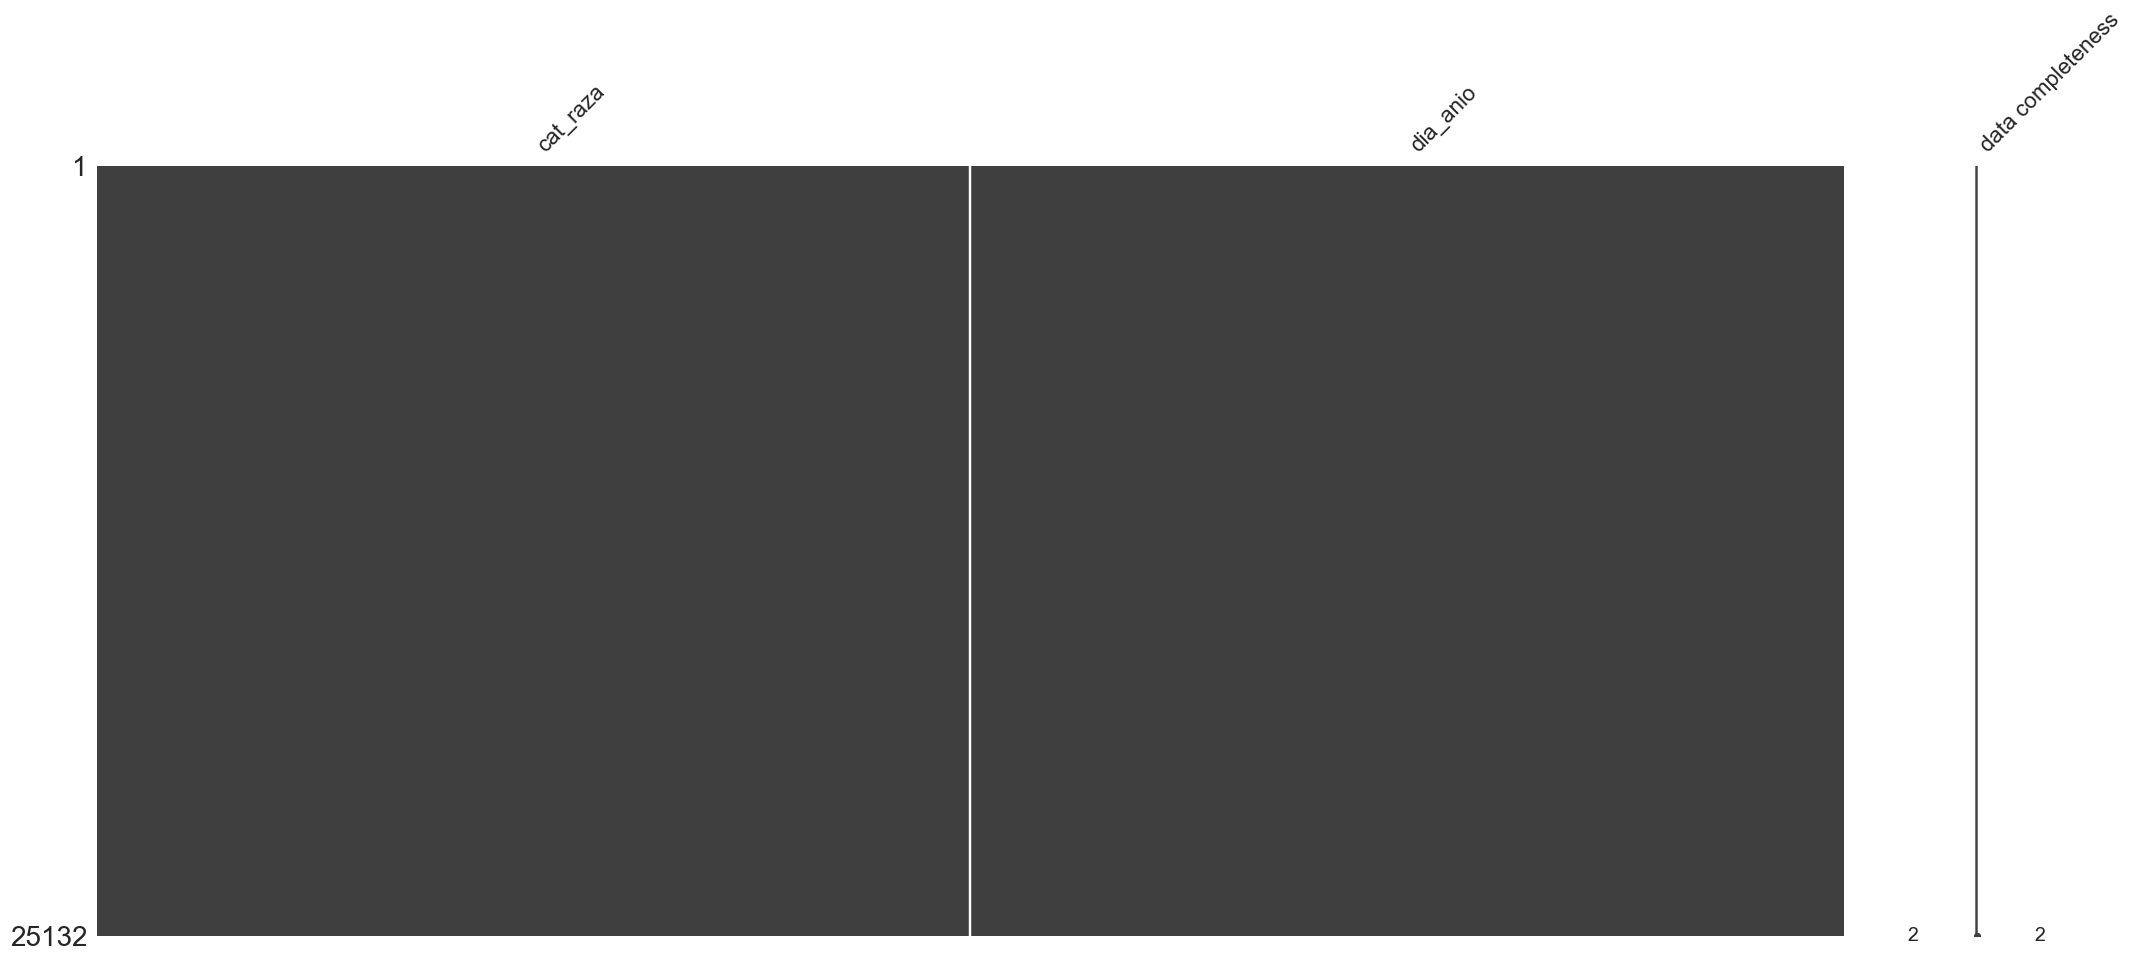

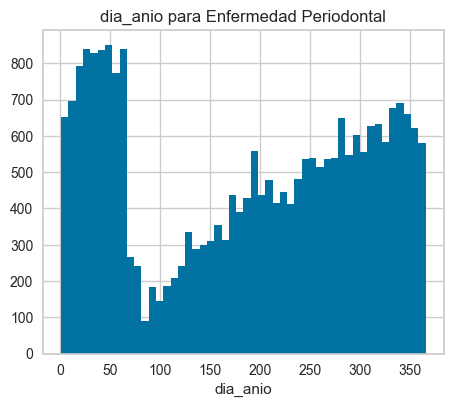

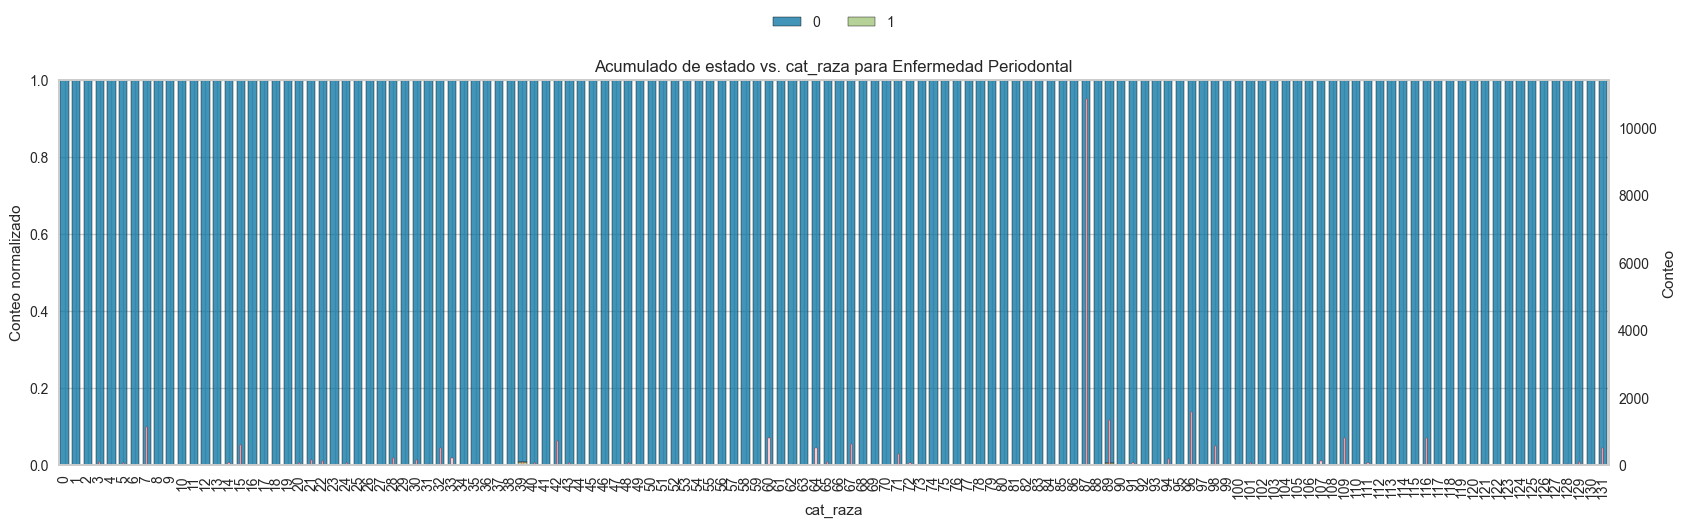

Hipersensibilidad Alimentaria
5


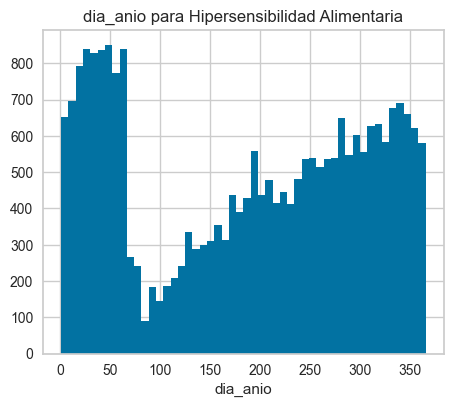

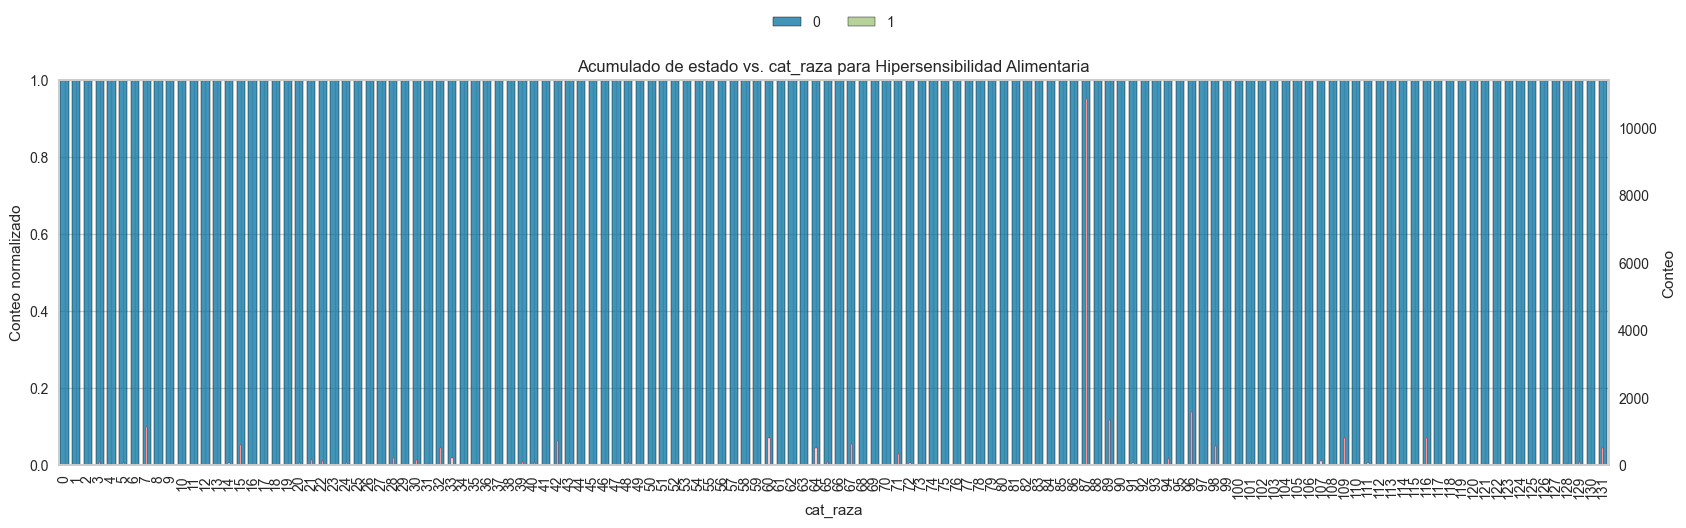

Urolitiasis/Cálculos Urinarios
30


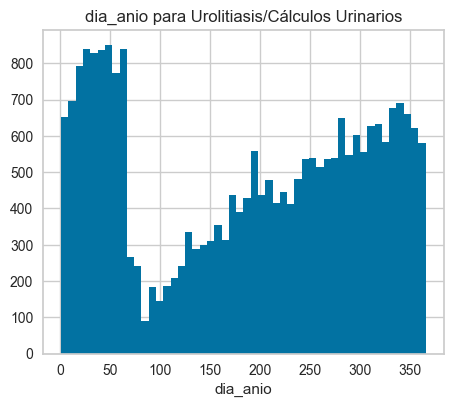

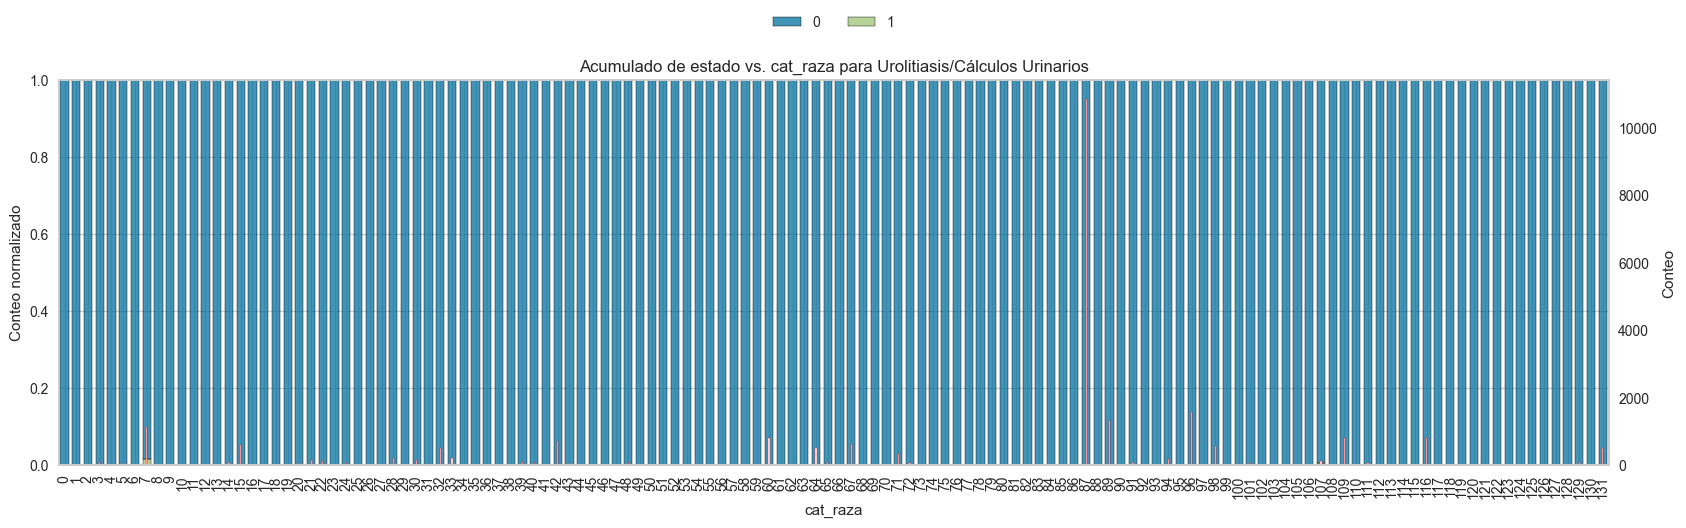

Otodectes (Ácaros en Oídos)
8


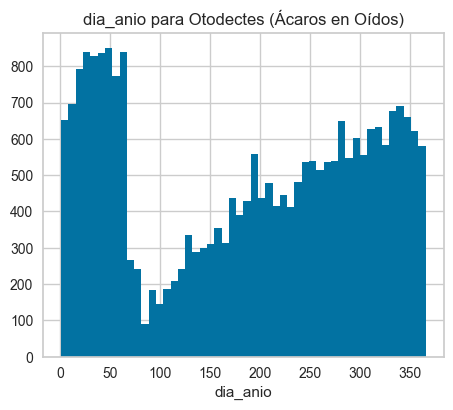

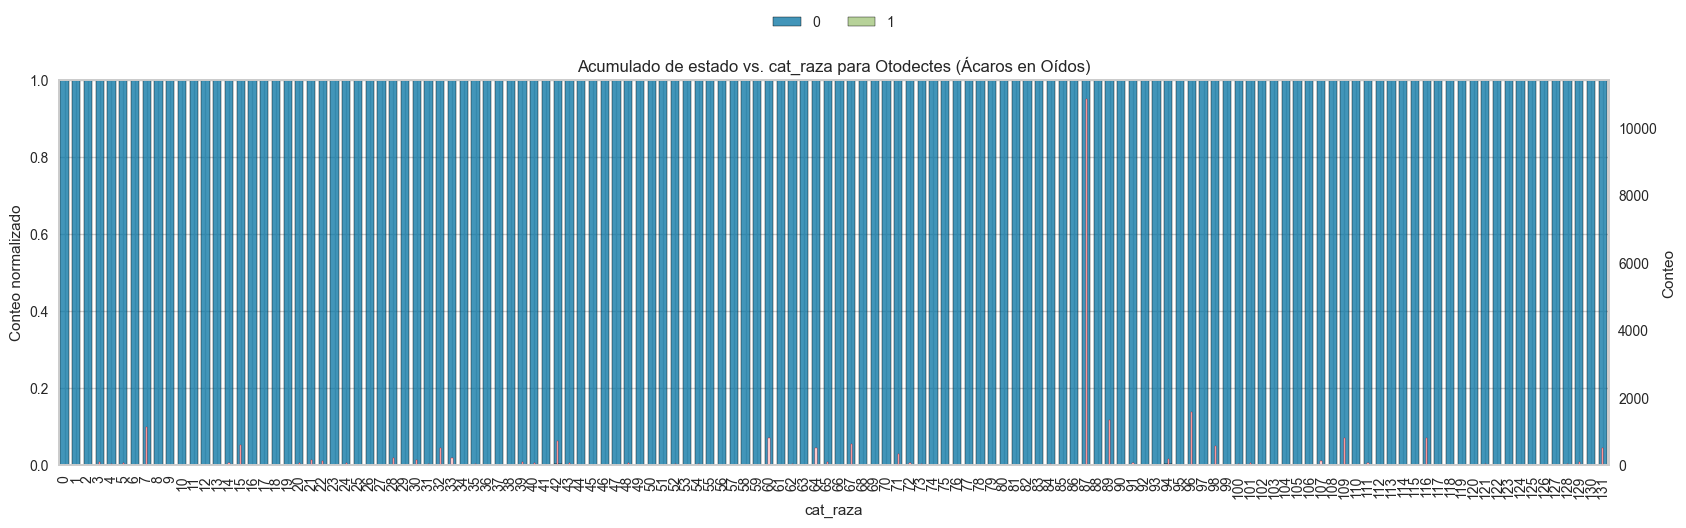

Vómito
31


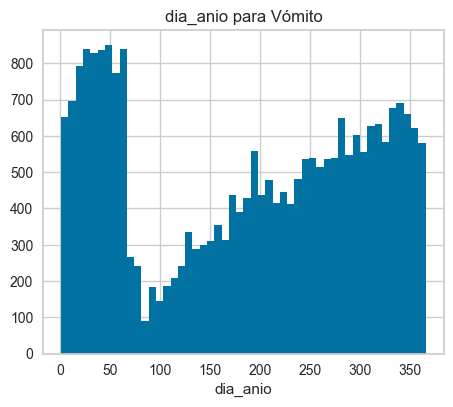

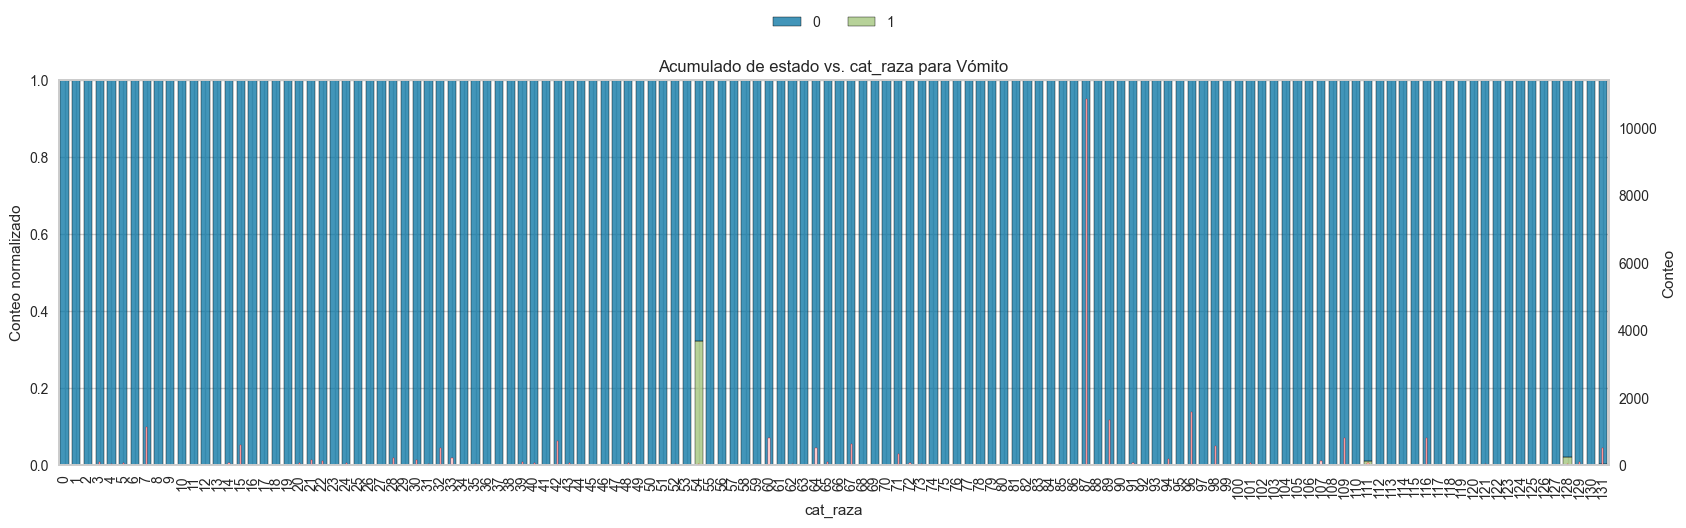

Bronquitis Aguda
7


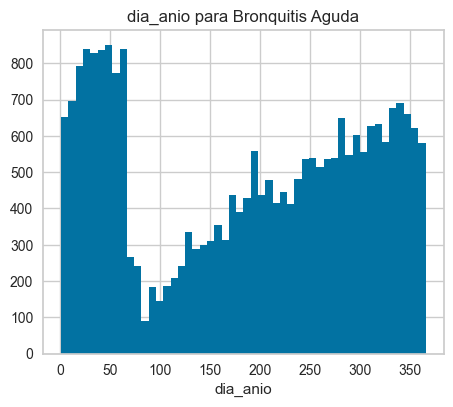

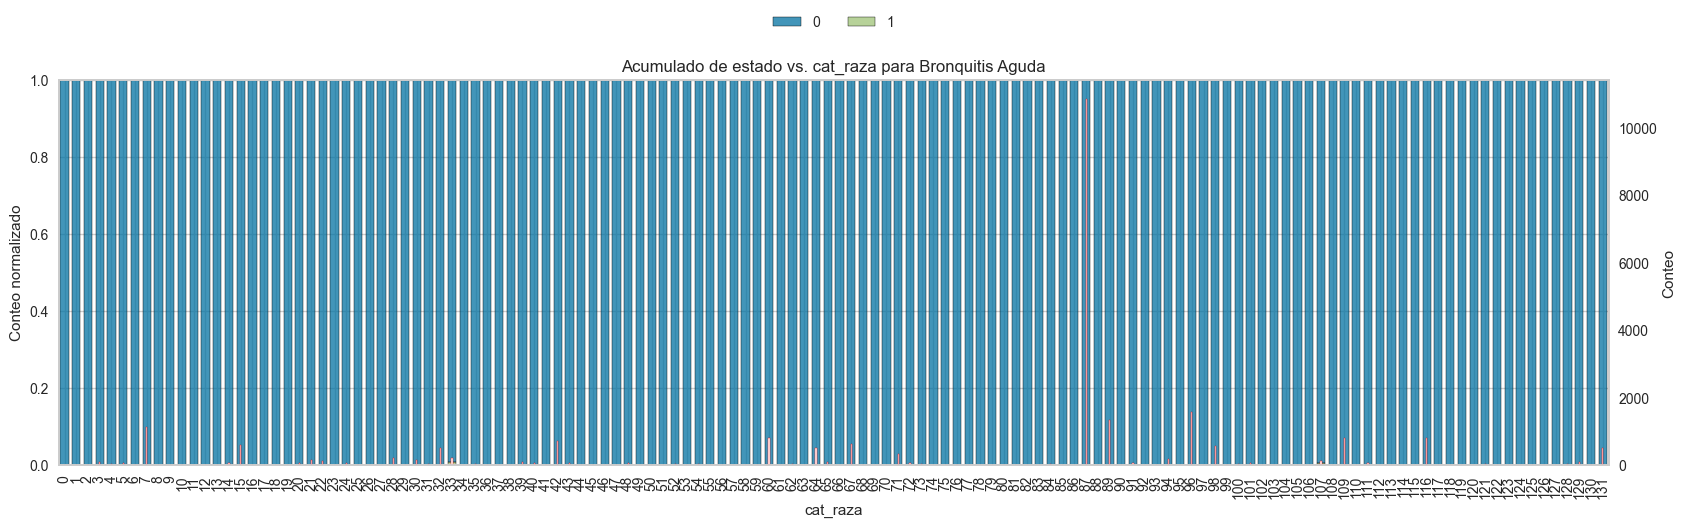

Estenosis Traqueal
8


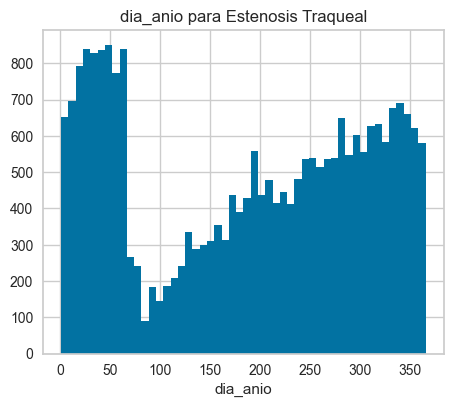

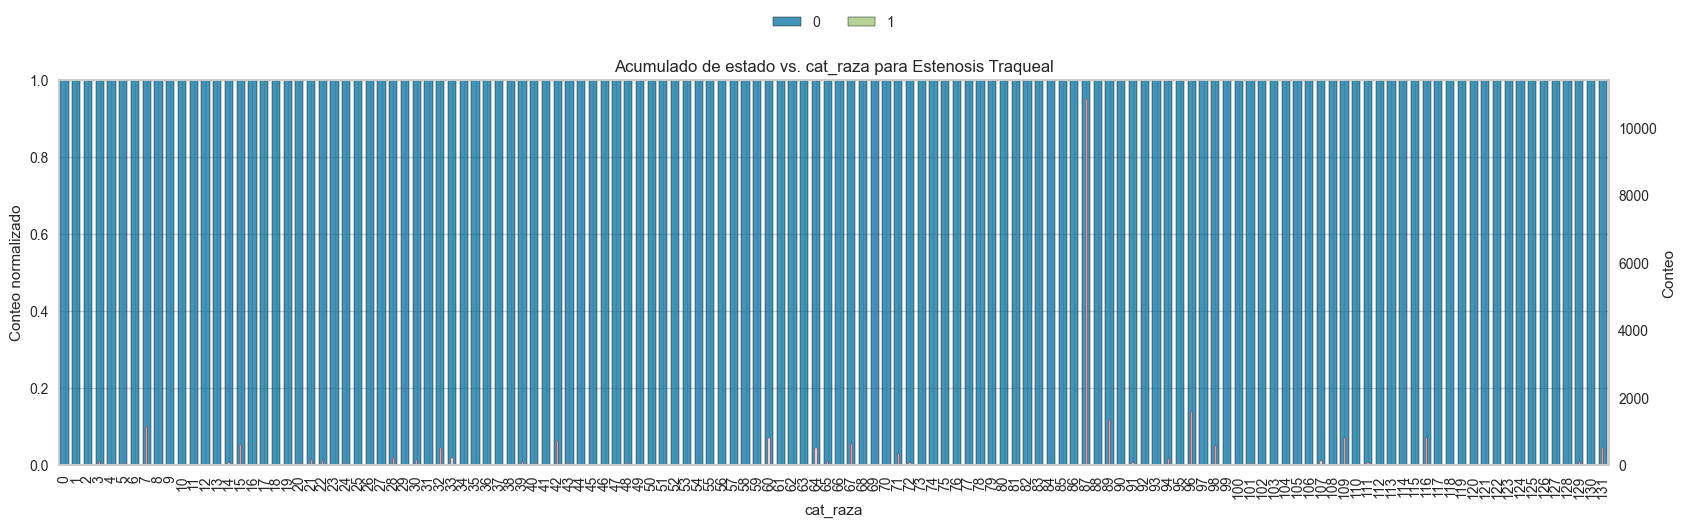

Enfermedad Renal Crónica (ERC) Estadio III
5


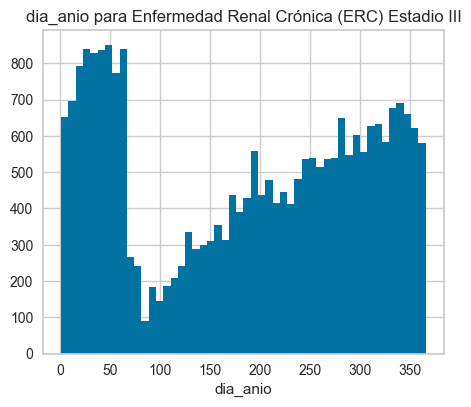

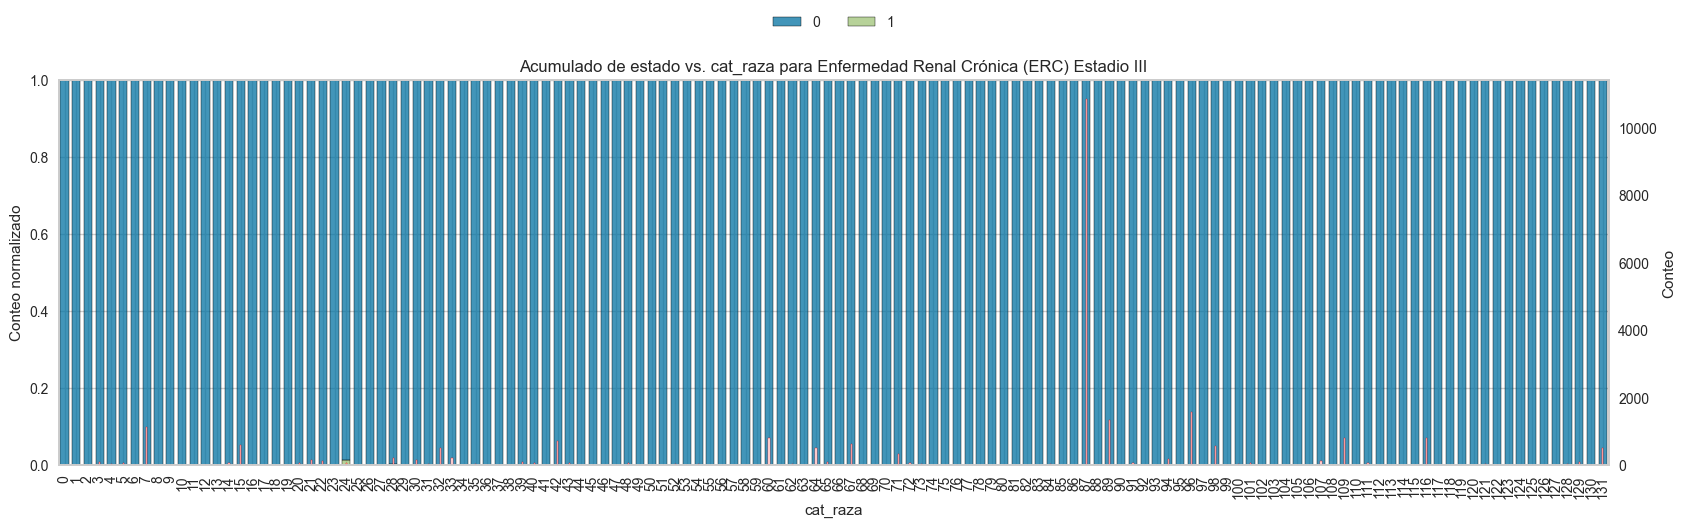

In [30]:
cols=['cat_raza', 'dia_anio']

# gráfico de nulos
msno.matrix(df2[cols], labels=True)

numeros=['dia_anio']

excluir=['enfermedades', 'raza', 'pronostico_normalizado', 'fecha',"target", "tipo"]

base1=df2[cols+['enfermedades']].fillna(-1)

categorias=[]
for i in cols:
    if i not in numeros:
        categorias.append(i)
        base1[i]=base1[i].astype("category")
        map={-1:"Sin datos"}
        base1 = base1.replace({i: map})
    else:
        map={'No Disponible':-1}
        base1 = base1.replace({i: map})
        base1[i]=base1[i].astype("float")

for k in resultados["enfermedad"].unique():
    base1["target"]=0
    base1["target"].loc[base1["enfermedades"]==k]=1
    df3=df2[df2["enfermedades"]==k].copy()
    print(k)
    print(len(df3))
    
    # graficar histograma números
    plt.figure(figsize=(30,100))
    for i, var in enumerate(numeros):
        plt.subplot(20,5,i+1)
        plt.hist(base1[var],50)
        title_string = var + " para " + k
        plt.title(title_string)
        plt.xlabel(var)
    plt.show()
    # graficar números vs variable
    #plt.figure(figsize=(20,120))
    colores=["#38B304","#FFD000","#0067B1","#D98F08","#2ADAC6","#E6BA02", "#85929E","#2ADAC6","#7E06F3", "#F20F8C"]
    for i, var in enumerate(numeros):
        fig = px.box(base1, x='target', y=var, color="target",color_discrete_sequence=colores) 
        fig.update_traces(boxpoints=False) 
        fig.update_layout(title=var + " para " + k)
        fig.show()



    # graficar categoricas

    for var in categorias:
        if var not in excluir:
            try:
                fig, ax = plt.subplots(figsize=(20,5))
                plot = sns.histplot(data=base1, x=var, hue='target', multiple="fill", shrink=.7, ax=ax )
                ax2 = ax.twinx()
                sns.countplot(x=var, data=base1, edgecolor = "red", facecolor = "white", width=0.1, ax=ax2)
                plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
                title_string = "Acumulado de estado vs. " + var + " para " + k
                sns.move_legend(
                    ax, "lower center",
                    bbox_to_anchor=(.5, 1.1), ncol=3, title=None, frameon=False,
                )
                ax2.grid(False)
                ax.set_ylabel('Conteo normalizado')
                ax2.set_ylabel('Conteo')
                plt.title(title_string)
                
            except:
                print("fallo ", var + " para " + k)
    plt.show()

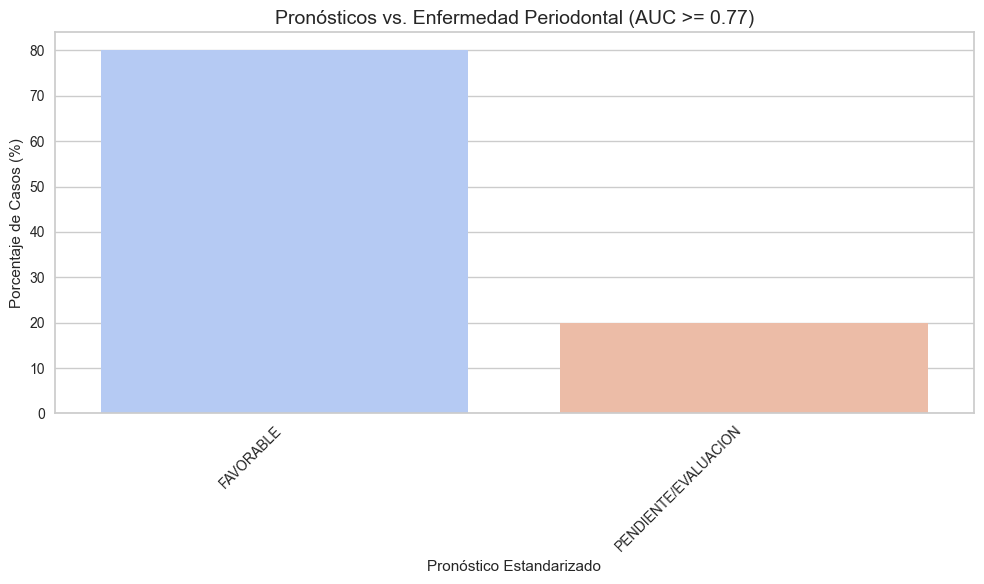

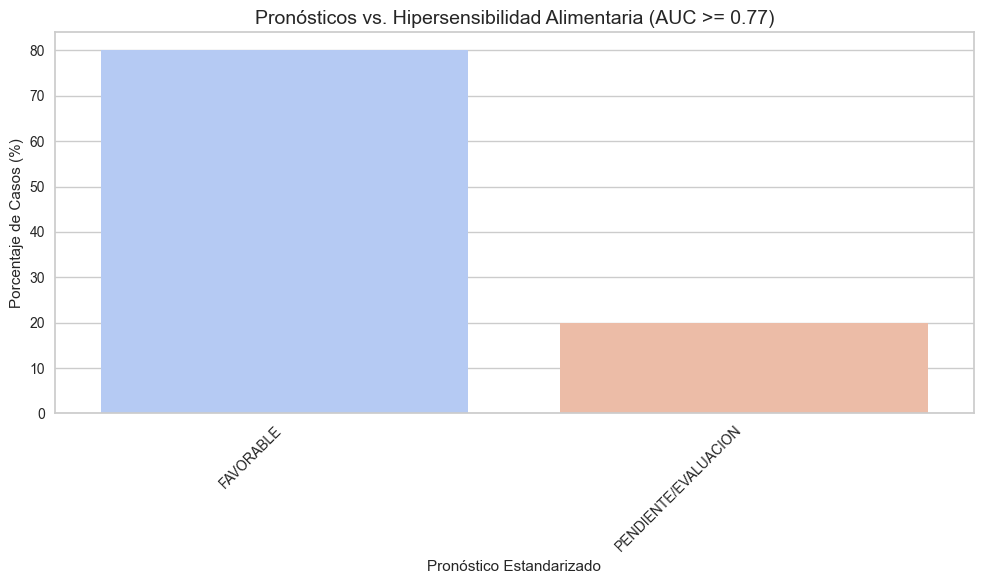

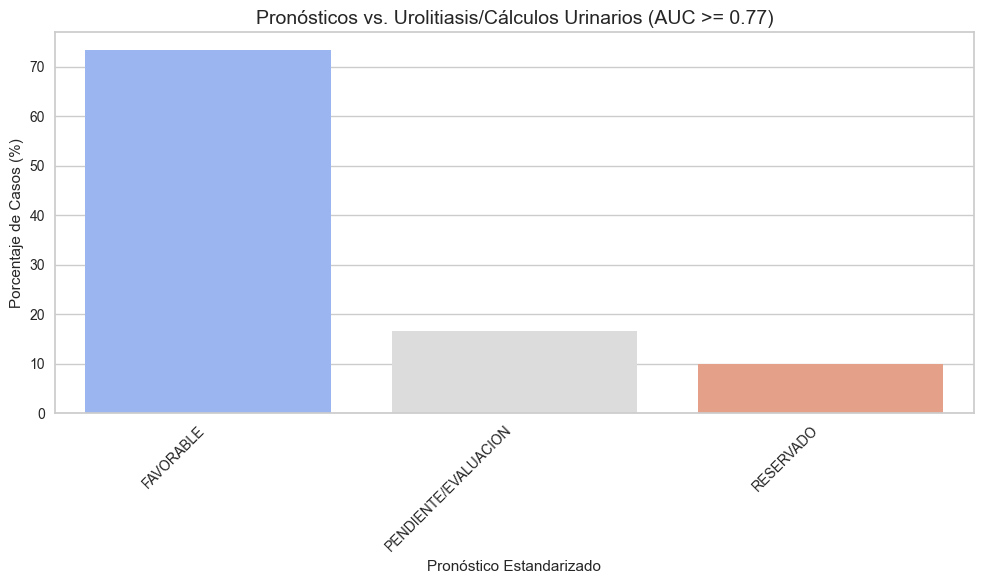

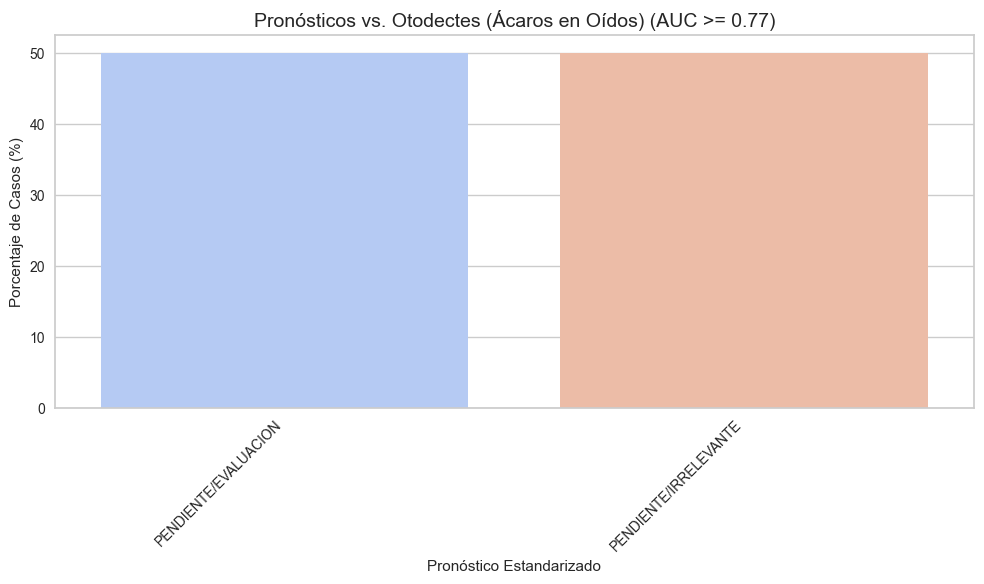

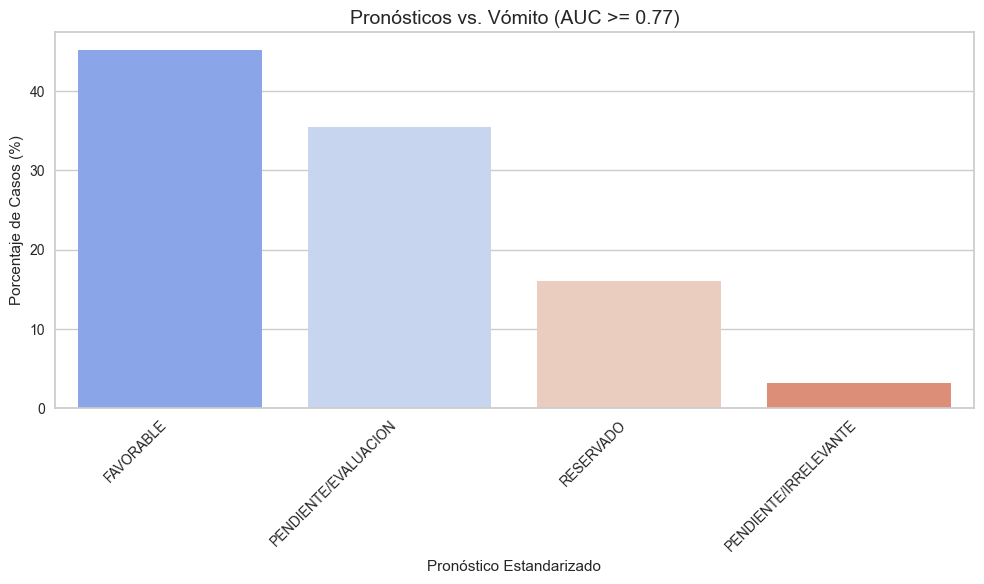

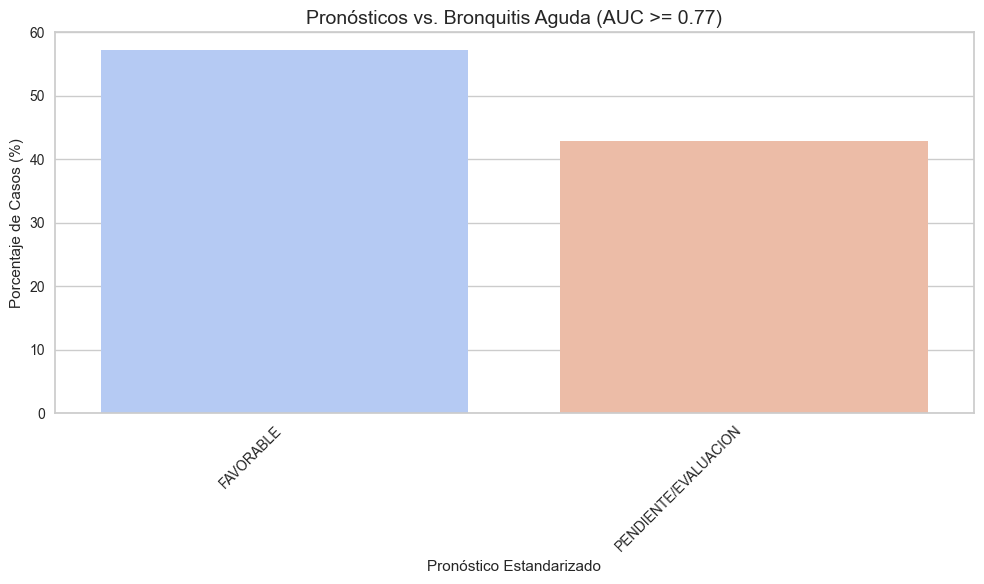

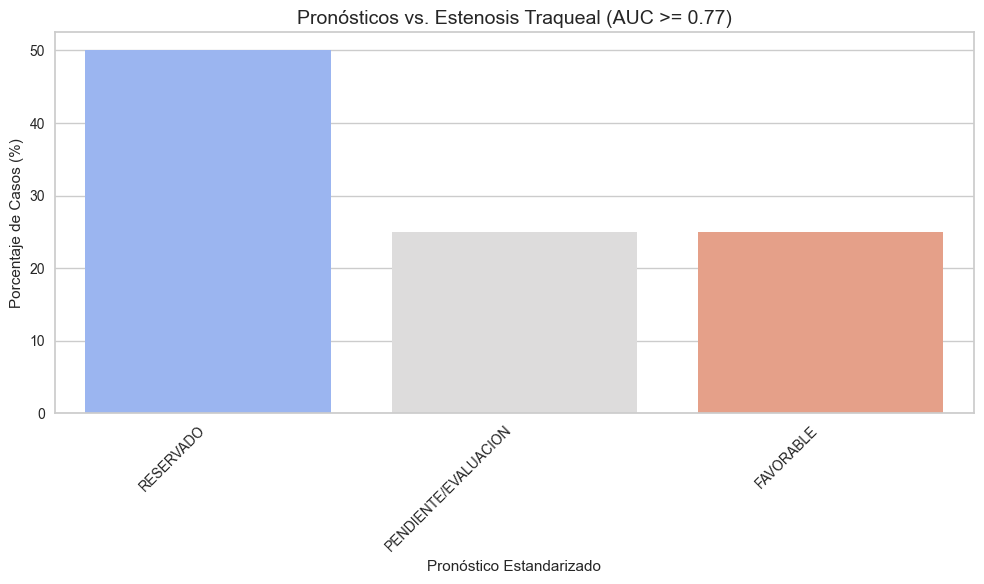

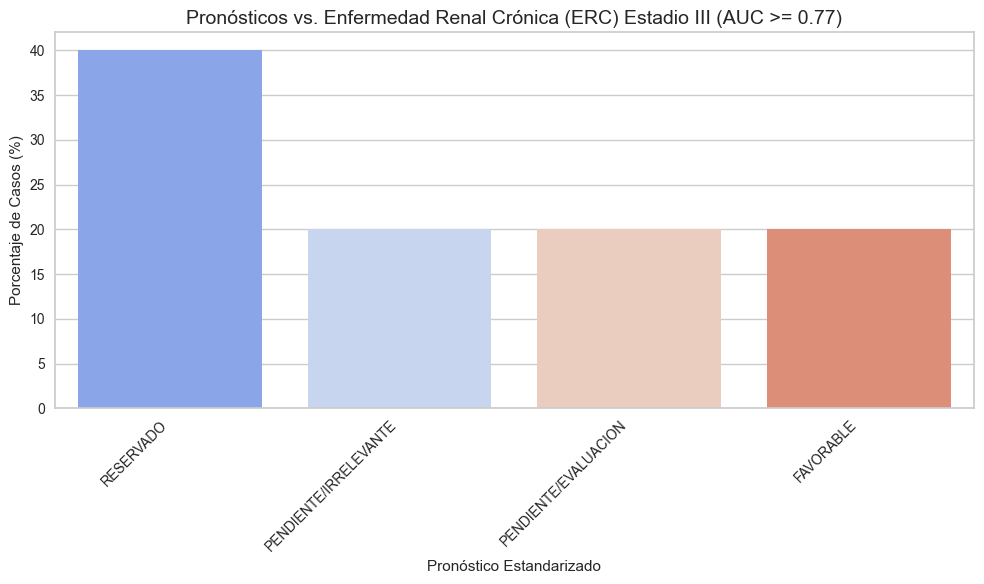

In [31]:
#2. Pronóstico vs. Enfermedad (Severidad) 🏥

# Iterar sobre las enfermedades con alto AUC
for enfermedad in resultados["enfermedad"].unique():
    # Crear la columna 'target'
    df2['target'] = 0
    df2.loc[df2["enfermedades"] == enfermedad, "target"] = 1
    
    # Filtrar solo los casos positivos y dropear los nulos en pronóstico
    df_target_positivo = df2[df2['target'] == 1].dropna(subset=['pronostico_normalizado']).copy()
    
    # Calcular la distribución de pronósticos (en porcentaje)
    pronostico_dist = df_target_positivo['pronostico_normalizado'].value_counts(normalize=True) * 100
    
    plt.figure(figsize=(10, 6))
    # 'coolwarm' ayuda a visualizar la polaridad (bueno/malo)
    sns.barplot(x=pronostico_dist.index, y=pronostico_dist.values, palette='coolwarm') 
    plt.title(f'Pronósticos vs. {enfermedad} (AUC >= 0.77)', fontsize=14)
    plt.xlabel('Pronóstico Estandarizado')
    plt.ylabel('Porcentaje de Casos (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

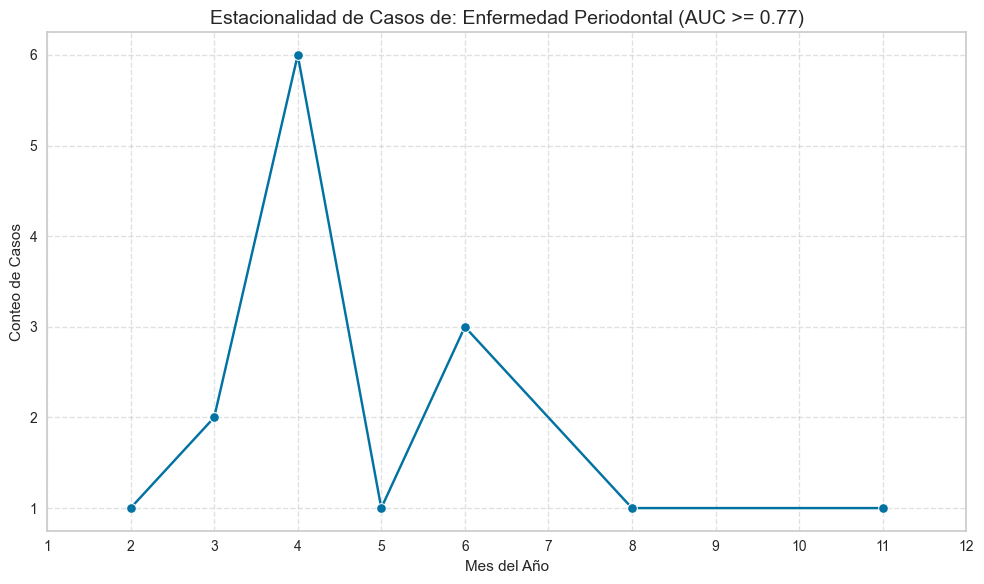

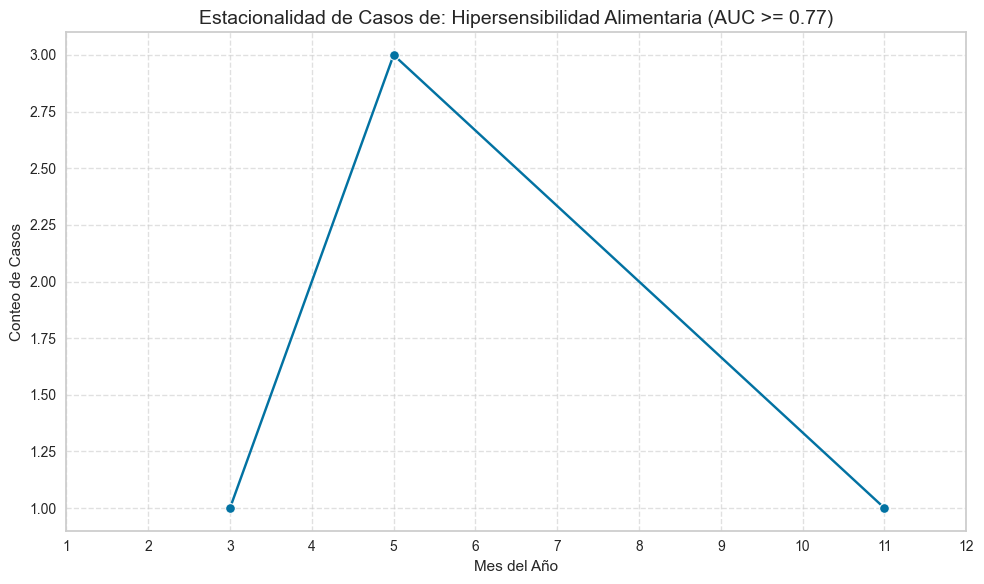

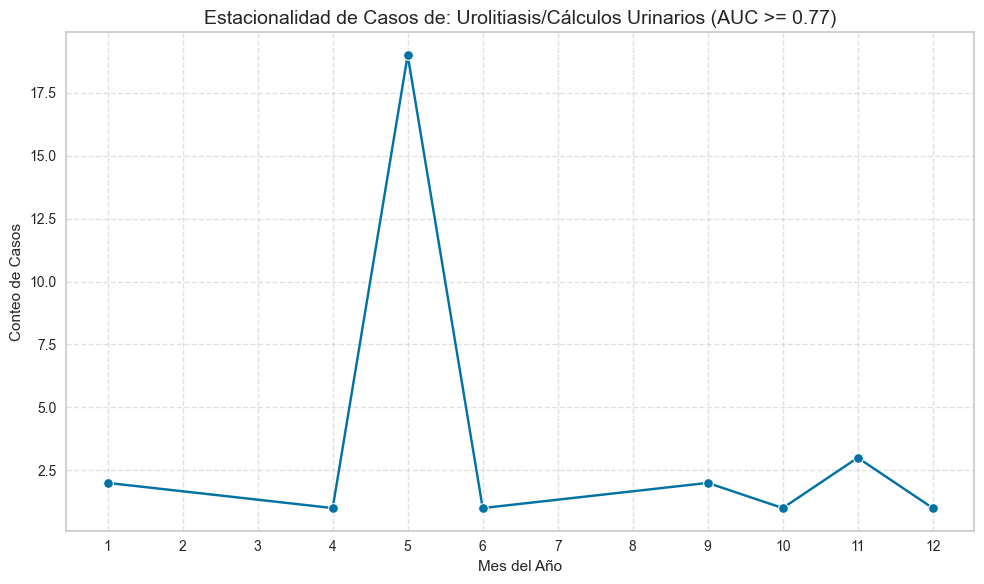

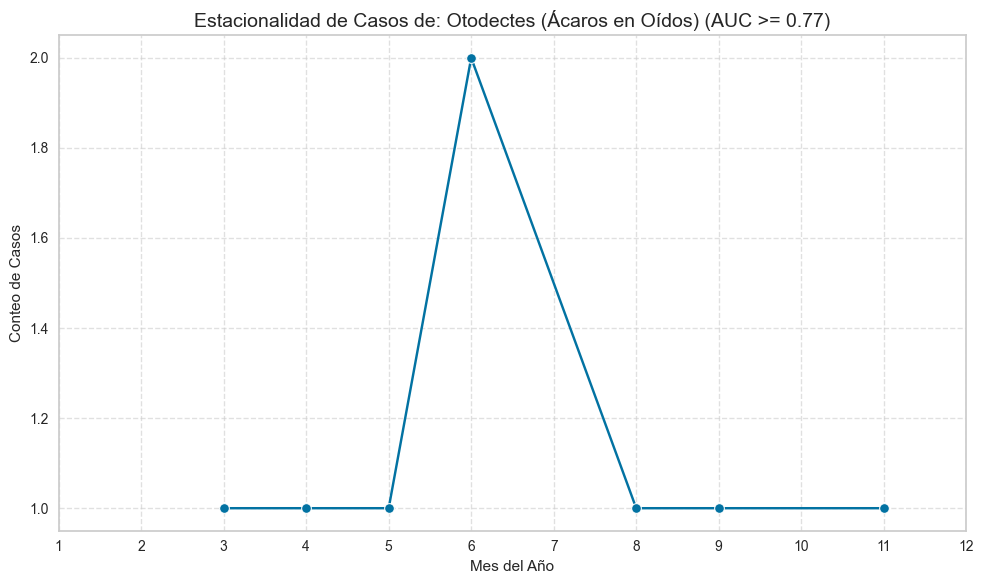

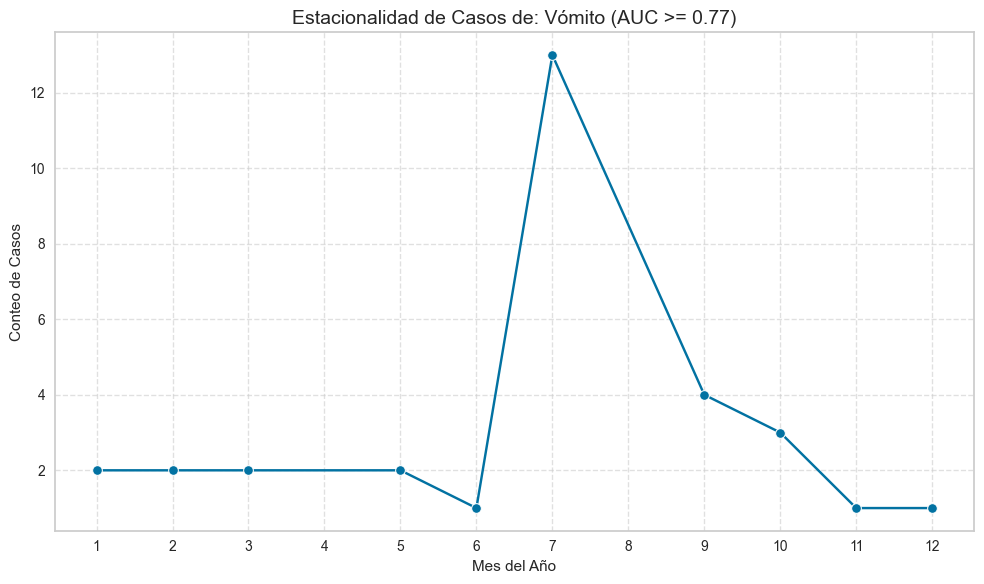

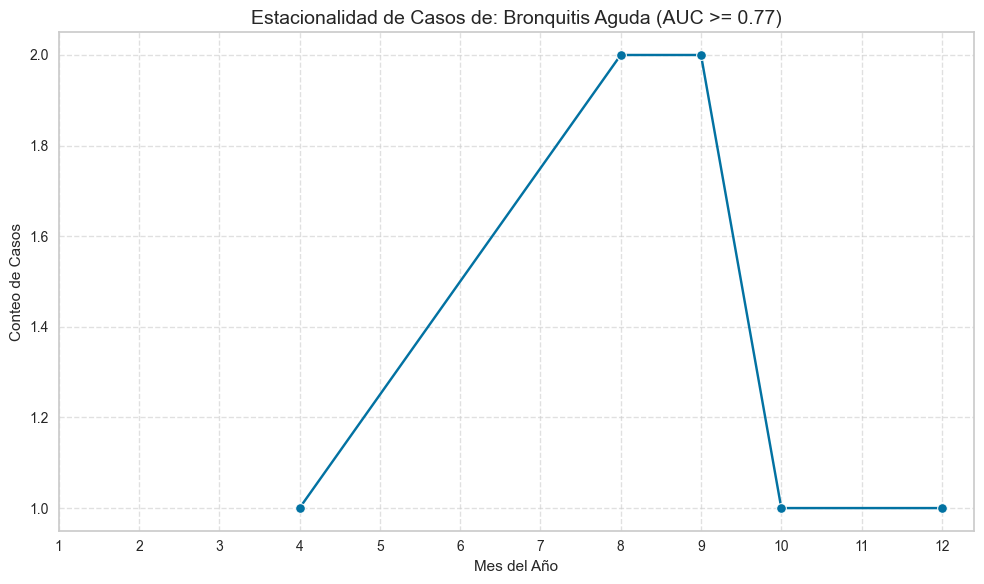

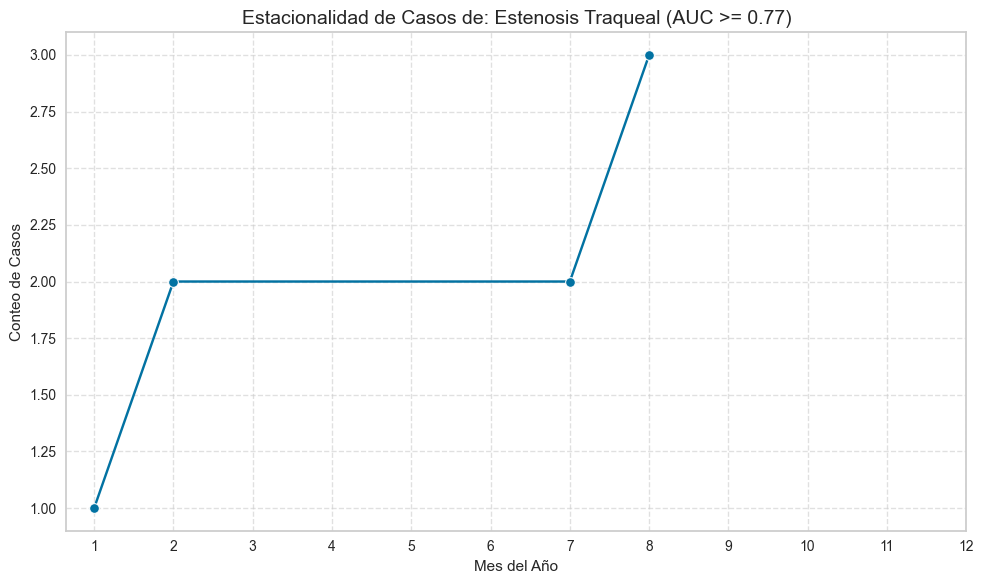

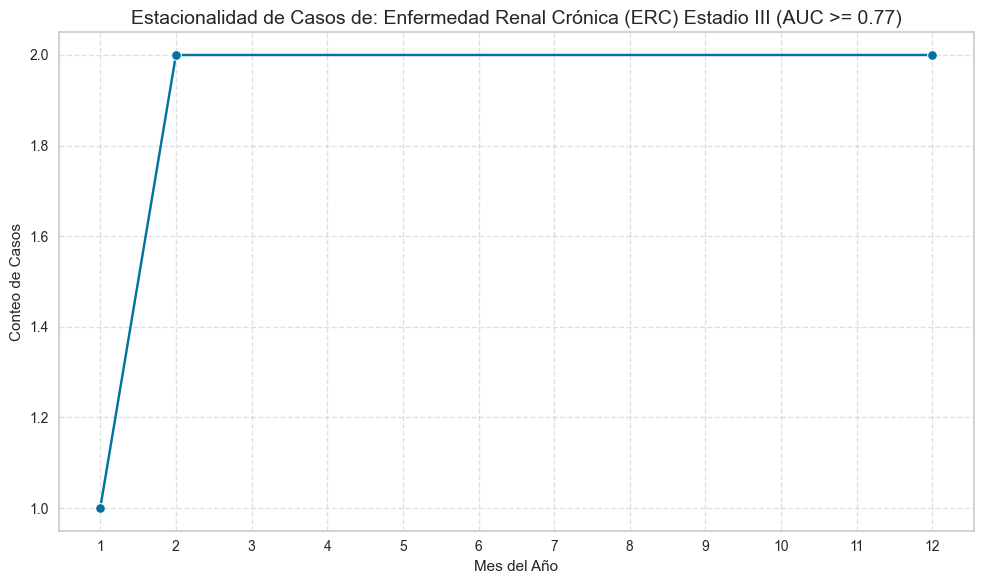

In [32]:
#3. Patrones Temporales vs. Enfermedad (Estacionalidad)

# Asegúrate de que la columna 'mes' esté creada:
if 'mes' not in df2.columns:
    df2['mes'] = df2['fecha'].dt.month

# Iterar sobre las enfermedades con alto AUC
for enfermedad in resultados["enfermedad"].unique():
    # Crear la columna 'target'
    df2['target'] = 0
    df2.loc[df2["enfermedades"] == enfermedad, "target"] = 1
    
    # Filtrar solo los casos positivos
    df_target_positivo = df2[df2['target'] == 1].copy()
    
    # Contar los casos por mes
    casos_por_mes = df_target_positivo['mes'].value_counts().sort_index()
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=casos_por_mes.index, y=casos_por_mes.values, marker='o')
    plt.title(f'Estacionalidad de Casos de: {enfermedad} (AUC >= 0.77)', fontsize=14)
    plt.xlabel('Mes del Año')
    plt.ylabel('Conteo de Casos')
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

#############################################
comienza: Enfermedad Periodontal
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20614, 3)"
5,Transformed train set shape,"(14205, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9995,0.4981,0.0000,0.0000,0.0000,nan,0.0000,0.1030
nb,Naive Bayes,0.9995,0.4934,0.0000,0.0000,0.0000,nan,0.0000,0.0970
lr,Logistic Regression,0.9995,0.4668,0.0000,0.0000,0.0000,nan,0.0000,0.6990
lda,Linear Discriminant Analysis,0.9995,0.4652,0.0000,0.0000,0.0000,nan,0.0000,0.1090
ada,Ada Boost Classifier,0.9995,0.4623,0.0000,0.0000,0.0000,nan,0.0000,0.1800
svm,SVM - Linear Kernel,0.9994,0.4611,0.0000,0.0000,0.0000,nan,-0.0001,0.1190
gbc,Gradient Boosting Classifier,0.9985,0.4535,0.0000,0.0000,0.0000,nan,-0.0004,0.2270
lightgbm,Light Gradient Boosting Machine,0.9993,0.4190,0.0000,0.0000,0.0000,nan,-0.0001,0.2220
dt,Decision Tree Classifier,0.9995,0.3496,0.1000,0.1500,0.1167,nan,0.1206,0.0970
et,Extra Trees Classifier,0.9996,0.3496,0.1000,0.2000,0.1333,nan,0.1414,0.1960


                                    Model  Accuracy     AUC  Recall  Prec.  \
qda       Quadratic Discriminant Analysis    0.9995  0.4981     0.0   0.00   
nb                            Naive Bayes    0.9995  0.4934     0.0   0.00   
lr                    Logistic Regression    0.9995  0.4668     0.0   0.00   
lda          Linear Discriminant Analysis    0.9995  0.4652     0.0   0.00   
ada                  Ada Boost Classifier    0.9995  0.4623     0.0   0.00   
svm                   SVM - Linear Kernel    0.9994  0.4611     0.0   0.00   
gbc          Gradient Boosting Classifier    0.9985  0.4535     0.0   0.00   
lightgbm  Light Gradient Boosting Machine    0.9993  0.4190     0.0   0.00   
dt               Decision Tree Classifier    0.9995  0.3496     0.1   0.15   
et                 Extra Trees Classifier    0.9996  0.3496     0.1   0.20   
rf               Random Forest Classifier    0.9996  0.3494     0.1   0.20   
knn                K Neighbors Classifier    0.9995  0.3493     

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.9702,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,0.9993,0.9903,0.0000,0.0000,0.0000,0.0000,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,0.9993,0.8594,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9993,0.5730,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9987,0.9961,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9987,0.5914,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: QuadraticDiscriminantAnalysis
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.9702     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       0.9993  0.9903     0.0    0.0  0.0    0.0  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       0.9993  0.8594     0.0    0.0  0.0    0.0  0.0
6       0.9993  0.5730     0.0    0.0  0.0    0.0  0.0
7       0.9987  0.9961     0.0    0.0  0.0    0.0  0.0
8       0.9987  0.5914     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9995  0.4981     0.0    0.0  0.0    NaN  0.0
Std     0.0005  0.4302     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.7656,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,0.9993,0.7065,0.0000,0.0000,0.0000,0.0000,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,0.9993,0.6794,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9993,0.9137,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9987,0.7430,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9987,0.8644,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.7656     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       0.9993  0.7065     0.0    0.0  0.0    0.0  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       0.9993  0.6794     0.0    0.0  0.0    0.0  0.0
6       0.9993  0.9137     0.0    0.0  0.0    0.0  0.0
7       0.9987  0.7430     0.0    0.0  0.0    0.0  0.0
8       0.9987  0.8644     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9995  0.4672     0.0    0.0  0.0    NaN  0.0
Std     0.0005  0.3870     0.0    0.0  0.0    NaN  0.0


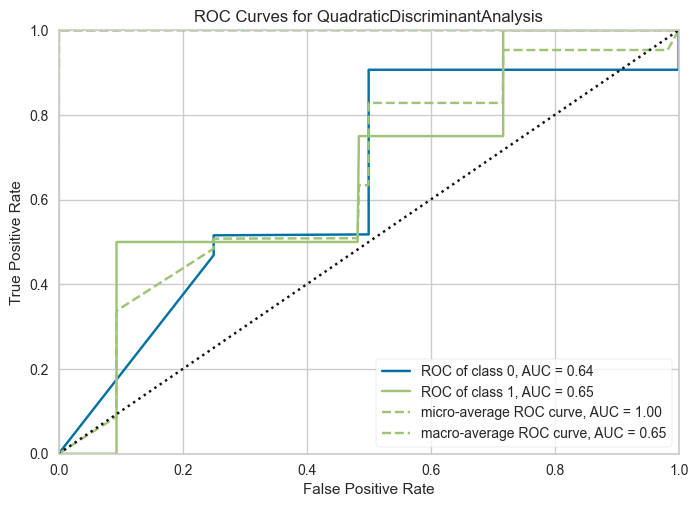

falló gráfico


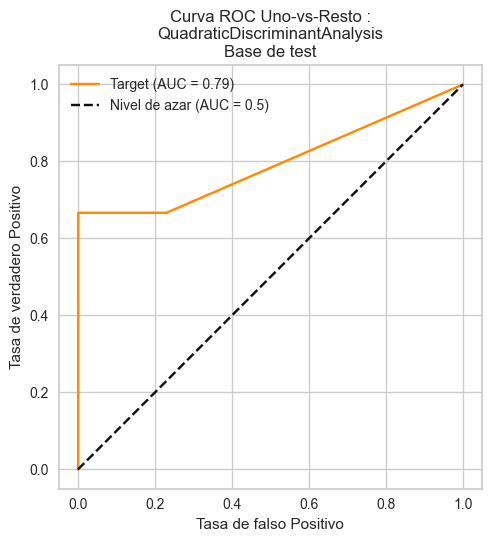

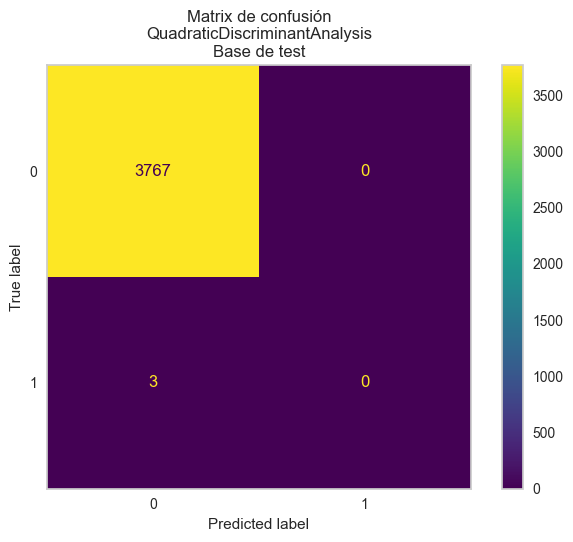

Confusion Matrix : 
 [[3767    0]
 [   3    0]]
Roc_auc_score modelo QuadraticDiscriminantAnalysis : 0.7944872135209273
GINI a 0.5 auc =  0.5889744270418547
Mejor Threshold: 0.0257 con Youden J statistic: 0.8162 para el modelo sklearn
FPR: 0.0008, TPR: 0.6667


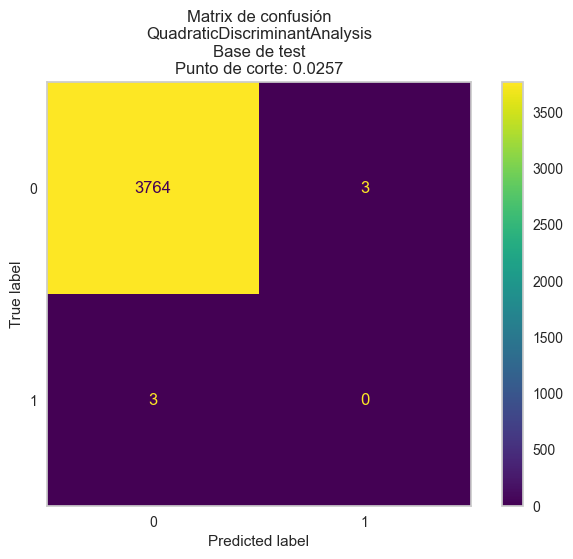

Confusion Matrix : 
 [[3764    3]
 [   3    0]]
KS sklearn a 0.0257: KstestResult(statistic=0.6658702769666401, pvalue=0.07473011622145281, statistic_location=0.0249, statistic_sign=1)
#############################################
#############################################
comienza: Hipersensibilidad Alimentaria
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20614, 3)"
5,Transformed train set shape,"(14205, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9998,0.1183,0.0000,0.0000,0.0000,nan,0.0000,0.1720
gbc,Gradient Boosting Classifier,0.9998,0.1001,0.0000,0.0000,0.0000,nan,0.0000,0.2560
dummy,Dummy Classifier,0.9998,0.1000,0.0000,0.0000,0.0000,nan,0.0000,0.1070
knn,K Neighbors Classifier,0.9998,0.0999,0.0000,0.0000,0.0000,nan,0.0000,0.1300
nb,Naive Bayes,0.6542,0.0999,0.0000,0.0000,0.0000,-0.0001,-0.0001,0.1140
dt,Decision Tree Classifier,0.9998,0.0999,0.0000,0.0000,0.0000,nan,0.0000,0.1020
rf,Random Forest Classifier,0.9998,0.0999,0.0000,0.0000,0.0000,nan,0.0000,0.2360
et,Extra Trees Classifier,0.9998,0.0999,0.0000,0.0000,0.0000,nan,0.0000,0.2020
lightgbm,Light Gradient Boosting Machine,0.9967,0.0890,0.0000,0.0000,0.0000,nan,0.0000,0.2100
svm,SVM - Linear Kernel,0.9998,0.0631,0.0000,0.0000,0.0000,nan,0.0000,0.0990


                                    Model  Accuracy     AUC  Recall   Prec.  \
ada                  Ada Boost Classifier    0.9998  0.1183     0.0  0.0000   
gbc          Gradient Boosting Classifier    0.9998  0.1001     0.0  0.0000   
dummy                    Dummy Classifier    0.9998  0.1000     0.0  0.0000   
knn                K Neighbors Classifier    0.9998  0.0999     0.0  0.0000   
nb                            Naive Bayes    0.6542  0.0999     0.0  0.0000   
dt               Decision Tree Classifier    0.9998  0.0999     0.0  0.0000   
rf               Random Forest Classifier    0.9998  0.0999     0.0  0.0000   
et                 Extra Trees Classifier    0.9998  0.0999     0.0  0.0000   
lightgbm  Light Gradient Boosting Machine    0.9967  0.0890     0.0  0.0000   
svm                   SVM - Linear Kernel    0.9998  0.0631     0.0  0.0000   
lr                    Logistic Regression    0.9998  0.0620     0.0  0.0000   
lda          Linear Discriminant Analysis    0.9998 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.5050,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
8,0.9987,0.6778,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: AdaBoostClassifier
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.5050     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
8       0.9987  0.6778     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.1183     0.0    0.0  0.0    NaN  0.0
Std     0.0004  0.2397     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.5050,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
8,0.9987,0.6778,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.5050     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
8       0.9987  0.6778     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.1183     0.0    0.0  0.0    NaN  0.0
Std     0.0004  0.2397     0.0    0.0  0.0    NaN  0.0


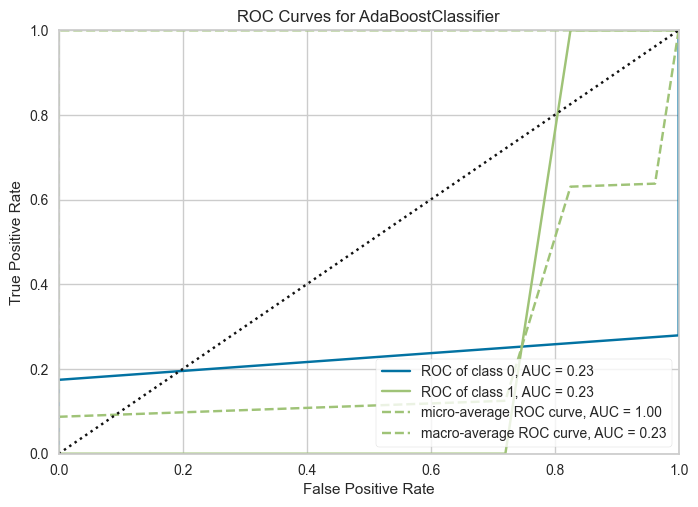

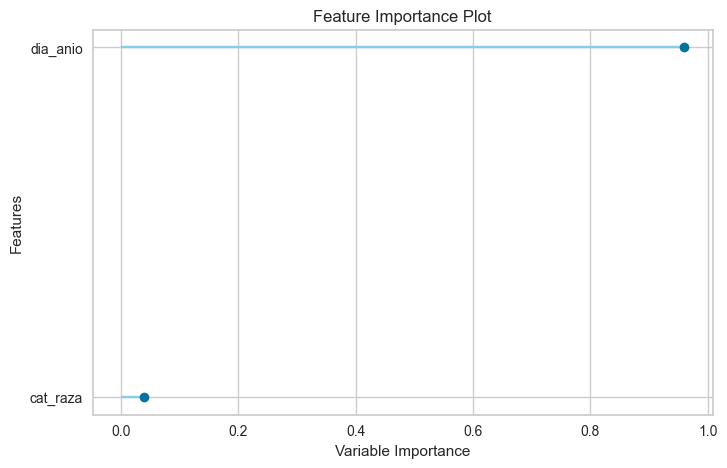

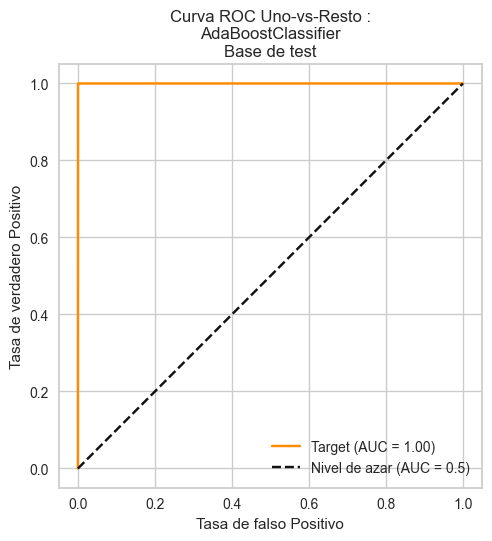

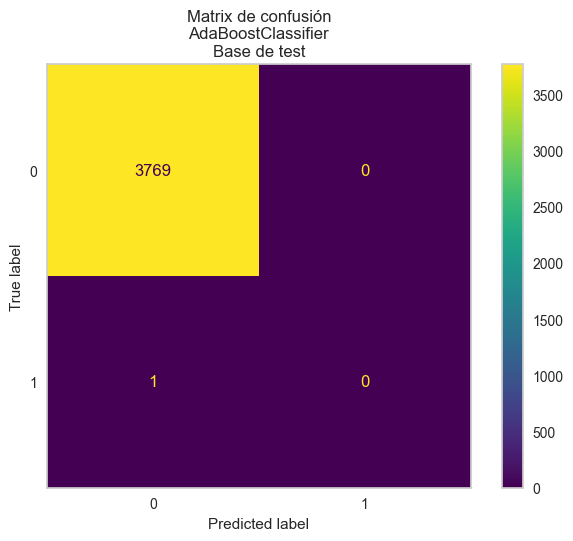

Confusion Matrix : 
 [[3769    0]
 [   1    0]]
Roc_auc_score modelo AdaBoostClassifier : 0.9998673388166622
GINI a 0.5 auc =  0.9997346776333245
Mejor Threshold: 0.4954 con Youden J statistic: 0.9999 para el modelo sklearn
FPR: 0.0003, TPR: 1.0


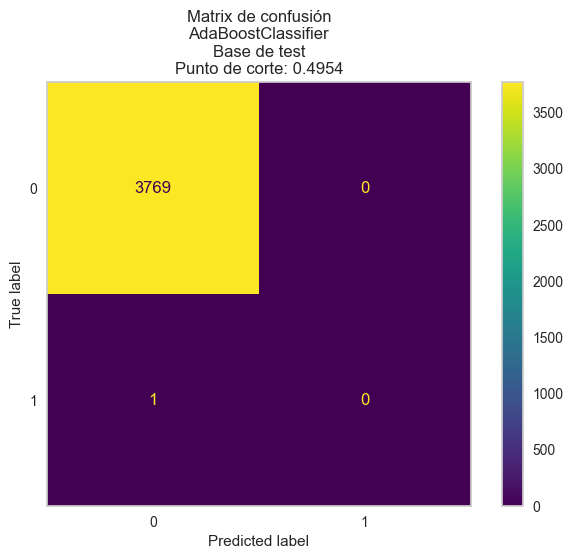

Confusion Matrix : 
 [[3769    0]
 [   1    0]]
KS sklearn a 0.4954: KstestResult(statistic=0.9997346776333245, pvalue=0.0010610079575596814, statistic_location=0.4828, statistic_sign=1)
#############################################
#############################################
comienza: Urolitiasis/Cálculos Urinarios
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20616, 3)"
5,Transformed train set shape,"(14207, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.9989,0.7767,0.0000,0.0000,0.0000,nan,0.0000,0.1020
lr,Logistic Regression,0.9989,0.7760,0.0000,0.0000,0.0000,nan,0.0000,0.1020
svm,SVM - Linear Kernel,0.9989,0.7744,0.0000,0.0000,0.0000,nan,0.0000,0.0970
nb,Naive Bayes,0.9989,0.7702,0.0000,0.0000,0.0000,nan,0.0000,0.1040
gbc,Gradient Boosting Classifier,0.9982,0.7649,0.6000,0.6452,0.5867,0.5862,0.6035,0.2710
qda,Quadratic Discriminant Analysis,0.9989,0.7569,0.0000,0.0000,0.0000,nan,0.0000,0.1160
knn,K Neighbors Classifier,0.9992,0.7497,0.6000,0.6583,0.5867,0.5864,0.6062,0.1690
dt,Decision Tree Classifier,0.9990,0.7496,0.6000,0.5417,0.5371,0.5367,0.5532,0.1030
et,Extra Trees Classifier,0.9993,0.7496,0.6000,0.6167,0.5767,nan,0.5918,0.2300
rf,Random Forest Classifier,0.9994,0.7493,0.6000,0.6667,0.5933,nan,0.6126,0.2530


                                    Model  Accuracy     AUC  Recall   Prec.  \
lda          Linear Discriminant Analysis    0.9989  0.7767  0.0000  0.0000   
lr                    Logistic Regression    0.9989  0.7760  0.0000  0.0000   
svm                   SVM - Linear Kernel    0.9989  0.7744  0.0000  0.0000   
nb                            Naive Bayes    0.9989  0.7702  0.0000  0.0000   
gbc          Gradient Boosting Classifier    0.9982  0.7649  0.6000  0.6452   
qda       Quadratic Discriminant Analysis    0.9989  0.7569  0.0000  0.0000   
knn                K Neighbors Classifier    0.9992  0.7497  0.6000  0.6583   
dt               Decision Tree Classifier    0.9990  0.7496  0.6000  0.5417   
et                 Extra Trees Classifier    0.9993  0.7496  0.6000  0.6167   
rf               Random Forest Classifier    0.9994  0.7493  0.6000  0.6667   
ada                  Ada Boost Classifier    0.9991  0.7228  0.1167  0.2000   
lightgbm  Light Gradient Boosting Machine    0.9990 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.9779,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9993,0.9157,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9987,0.9009,0.0000,0.0000,0.0000,0.0000,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,0.9993,0.9786,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9980,0.6962,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9980,0.8835,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9987,0.7683,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9980,0.6709,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: LinearDiscriminantAnalysis
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.9779     0.0    0.0  0.0    0.0  0.0
1       0.9993  0.9157     0.0    0.0  0.0    0.0  0.0
2       0.9987  0.9009     0.0    0.0  0.0    0.0  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       0.9993  0.9786     0.0    0.0  0.0    0.0  0.0
5       0.9980  0.6962     0.0    0.0  0.0    0.0  0.0
6       0.9980  0.8835     0.0    0.0  0.0    0.0  0.0
7       0.9987  0.7683     0.0    0.0  0.0    0.0  0.0
8       0.9980  0.6709     0.0    0.0  0.0    0.0  0.0
9       0.9993  0.9752     0.0    0.0  0.0    0.0  0.0
Mean    0.9989  0.7767     0.0    0.0  0.0    NaN  0.0
Std     0.0007  0.2807     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.9779,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9993,0.9157,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9987,0.9009,0.0000,0.0000,0.0000,0.0000,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,0.9993,0.9786,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9980,0.6966,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9980,0.8837,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9987,0.7693,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9980,0.6709,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.9779     0.0    0.0  0.0    0.0  0.0
1       0.9993  0.9157     0.0    0.0  0.0    0.0  0.0
2       0.9987  0.9009     0.0    0.0  0.0    0.0  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       0.9993  0.9786     0.0    0.0  0.0    0.0  0.0
5       0.9980  0.6966     0.0    0.0  0.0    0.0  0.0
6       0.9980  0.8837     0.0    0.0  0.0    0.0  0.0
7       0.9987  0.7693     0.0    0.0  0.0    0.0  0.0
8       0.9980  0.6709     0.0    0.0  0.0    0.0  0.0
9       0.9993  0.9752     0.0    0.0  0.0    0.0  0.0
Mean    0.9989  0.7769     0.0    0.0  0.0    NaN  0.0
Std     0.0007  0.2807     0.0    0.0  0.0    NaN  0.0


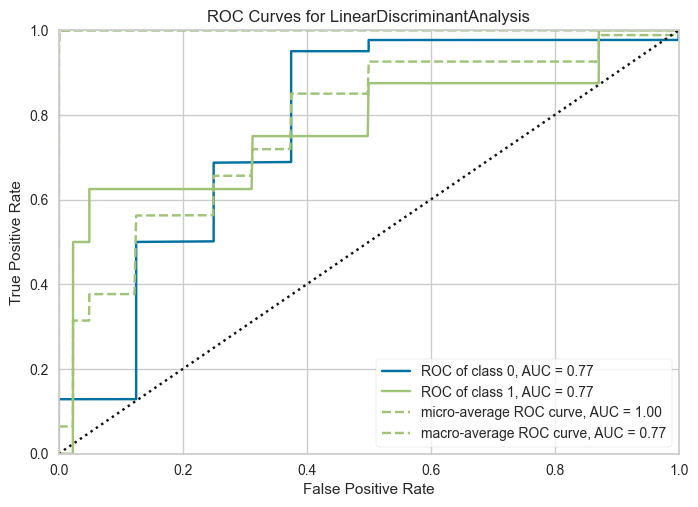

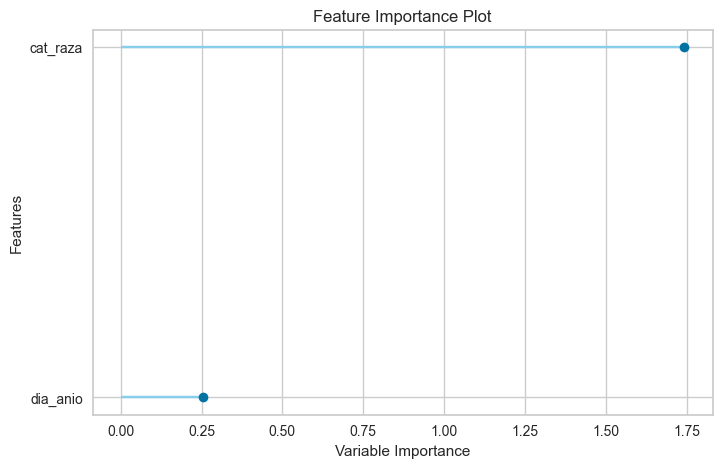

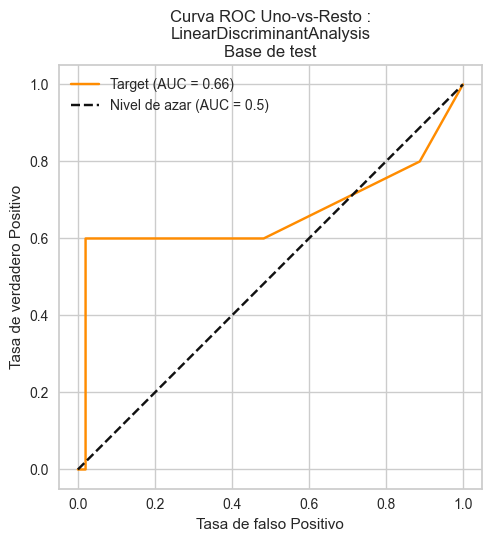

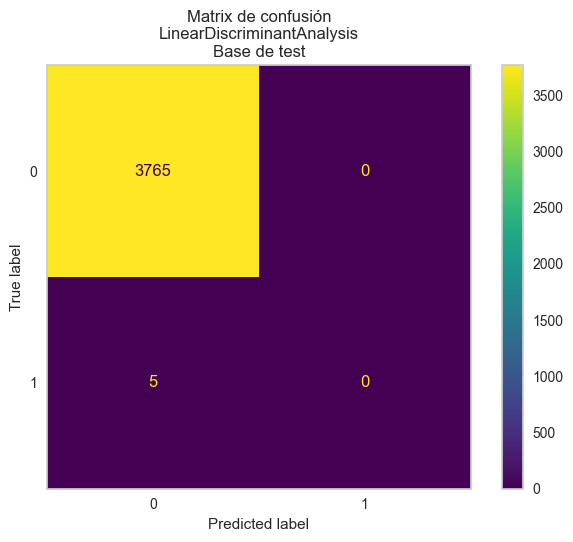

Confusion Matrix : 
 [[3765    0]
 [   5    0]]
Roc_auc_score modelo LinearDiscriminantAnalysis : 0.6622045152722443
GINI a 0.5 auc =  0.32440903054448866
Mejor Threshold: 0.0249 con Youden J statistic: 0.7668 para el modelo sklearn
FPR: 0.0199, TPR: 0.6


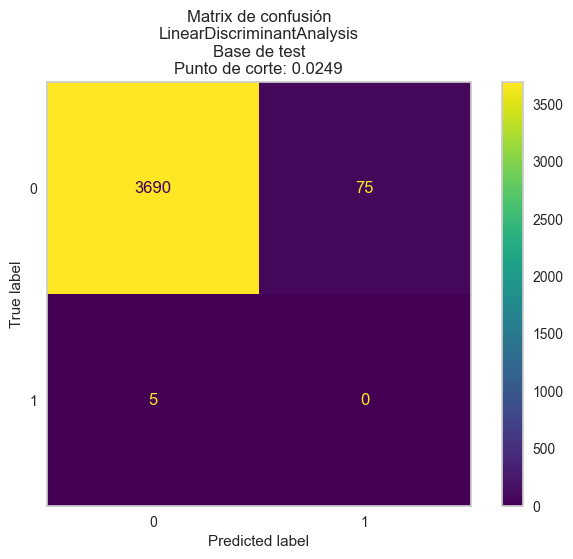

Confusion Matrix : 
 [[3690   75]
 [   5    0]]
KS sklearn a 0.0249: KstestResult(statistic=0.5800796812749004, pvalue=0.04003325613773464, statistic_location=0.0248, statistic_sign=1)
#############################################
#############################################
comienza: Otodectes (Ácaros en Oídos)
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20614, 3)"
5,Transformed train set shape,"(14205, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9996,0.2789,0.0000,0.0000,0.0000,nan,0.0000,0.1140
lightgbm,Light Gradient Boosting Machine,0.9994,0.2590,0.0000,0.0000,0.0000,nan,-0.0001,0.2630
gbc,Gradient Boosting Classifier,0.9942,0.2564,0.0000,0.0000,0.0000,-0.0003,-0.0009,0.2800
dummy,Dummy Classifier,0.9996,0.2500,0.0000,0.0000,0.0000,nan,0.0000,0.1180
dt,Decision Tree Classifier,0.9995,0.2497,0.0000,0.0000,0.0000,nan,0.0000,0.0960
knn,K Neighbors Classifier,0.9996,0.2495,0.0000,0.0000,0.0000,nan,0.0000,0.1350
et,Extra Trees Classifier,0.9995,0.2495,0.0000,0.0000,0.0000,nan,-0.0001,0.2590
rf,Random Forest Classifier,0.9994,0.2492,0.0000,0.0000,0.0000,nan,-0.0001,0.2170
nb,Naive Bayes,0.9996,0.2092,0.0000,0.0000,0.0000,nan,0.0000,0.0950
ada,Ada Boost Classifier,0.9995,0.1819,0.0000,0.0000,0.0000,nan,-0.0001,0.1820


                                    Model  Accuracy     AUC  Recall  Prec.  \
qda       Quadratic Discriminant Analysis    0.9996  0.2789     0.0    0.0   
lightgbm  Light Gradient Boosting Machine    0.9994  0.2590     0.0    0.0   
gbc          Gradient Boosting Classifier    0.9942  0.2564     0.0    0.0   
dummy                    Dummy Classifier    0.9996  0.2500     0.0    0.0   
dt               Decision Tree Classifier    0.9995  0.2497     0.0    0.0   
knn                K Neighbors Classifier    0.9996  0.2495     0.0    0.0   
et                 Extra Trees Classifier    0.9995  0.2495     0.0    0.0   
rf               Random Forest Classifier    0.9994  0.2492     0.0    0.0   
nb                            Naive Bayes    0.9996  0.2092     0.0    0.0   
ada                  Ada Boost Classifier    0.9995  0.1819     0.0    0.0   
lr                    Logistic Regression    0.9996  0.1342     0.0    0.0   
lda          Linear Discriminant Analysis    0.9996  0.1339     

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,0.9993,0.7893,0.0000,0.0000,0.0000,0.0000,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,0.9993,0.0147,0.0000,0.0000,0.0000,0.0000,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,0.9987,0.2364,0.0000,0.0000,0.0000,0.0000,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,0.9993,0.7999,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9993,0.9491,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: QuadraticDiscriminantAnalysis
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
1       0.9993  0.7893     0.0    0.0  0.0    0.0  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       0.9993  0.0147     0.0    0.0  0.0    0.0  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       0.9987  0.2364     0.0    0.0  0.0    0.0  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       0.9993  0.7999     0.0    0.0  0.0    0.0  0.0
8       0.9993  0.9491     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9996  0.2789     0.0    0.0  0.0    NaN  0.0
Std     0.0004  0.3797     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
1,0.9993,0.4963,0.0000,0.0000,0.0000,0.0000,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,0.9993,0.0080,0.0000,0.0000,0.0000,0.0000,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,0.9987,0.1309,0.0000,0.0000,0.0000,0.0000,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,0.9993,0.2517,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9993,0.5161,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
1       0.9993  0.4963     0.0    0.0  0.0    0.0  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       0.9993  0.0080     0.0    0.0  0.0    0.0  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       0.9987  0.1309     0.0    0.0  0.0    0.0  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       0.9993  0.2517     0.0    0.0  0.0    0.0  0.0
8       0.9993  0.5161     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9996  0.1403     0.0    0.0  0.0    NaN  0.0
Std     0.0004  0.1991     0.0    0.0  0.0    NaN  0.0


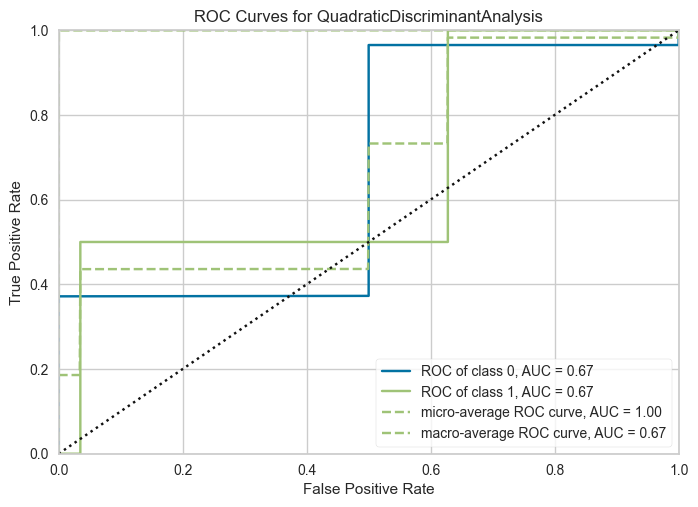

falló gráfico


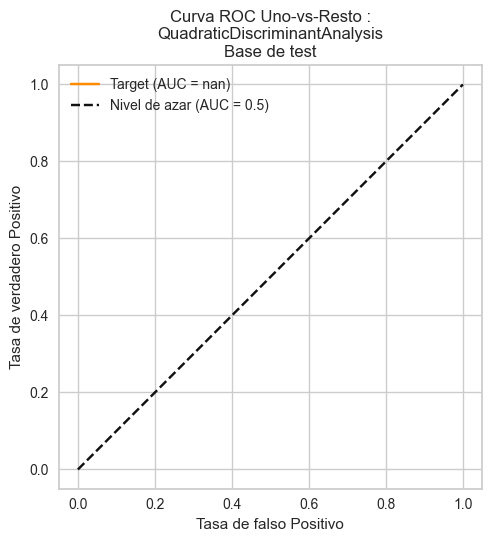

#############################################
#############################################
comienza: Vómito
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20615, 3)"
5,Transformed train set shape,"(14206, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9985,0.5669,0.2533,0.3333,0.2752,nan,0.2835,0.2610
ada,Ada Boost Classifier,0.9985,0.5611,0.0000,0.0000,0.0000,nan,-0.0001,0.1990
knn,K Neighbors Classifier,0.9991,0.5262,0.2533,0.5000,0.3167,nan,0.3437,0.1460
dt,Decision Tree Classifier,0.9989,0.5243,0.2533,0.4000,0.2900,nan,0.3059,0.1270
et,Extra Trees Classifier,0.9989,0.5241,0.2533,0.5000,0.3167,nan,0.3437,0.2070
rf,Random Forest Classifier,0.9989,0.5231,0.2533,0.5000,0.3167,nan,0.3437,0.2360
nb,Naive Bayes,0.9987,0.5045,0.0000,0.0000,0.0000,nan,0.0000,0.0980
qda,Quadratic Discriminant Analysis,0.9987,0.4940,0.0000,0.0000,0.0000,nan,0.0000,0.1070
gbc,Gradient Boosting Classifier,0.9989,0.4121,0.1500,0.2000,0.1667,nan,0.1707,0.2540
dummy,Dummy Classifier,0.9987,0.4000,0.0000,0.0000,0.0000,nan,0.0000,0.1010


                                    Model  Accuracy     AUC  Recall   Prec.  \
lightgbm  Light Gradient Boosting Machine    0.9985  0.5669  0.2533  0.3333   
ada                  Ada Boost Classifier    0.9985  0.5611  0.0000  0.0000   
knn                K Neighbors Classifier    0.9991  0.5262  0.2533  0.5000   
dt               Decision Tree Classifier    0.9989  0.5243  0.2533  0.4000   
et                 Extra Trees Classifier    0.9989  0.5241  0.2533  0.5000   
rf               Random Forest Classifier    0.9989  0.5231  0.2533  0.5000   
nb                            Naive Bayes    0.9987  0.5045  0.0000  0.0000   
qda       Quadratic Discriminant Analysis    0.9987  0.4940  0.0000  0.0000   
gbc          Gradient Boosting Classifier    0.9989  0.4121  0.1500  0.2000   
dummy                    Dummy Classifier    0.9987  0.4000  0.0000  0.0000   
lda          Linear Discriminant Analysis    0.9987  0.3398  0.0000  0.0000   
lr                    Logistic Regression    0.9987 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.8184,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9940,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9987,0.4945,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9993,0.5370,0.5000,1.0000,0.6667,0.6664,0.7069
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,0.9987,0.3669,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9967,0.6910,0.2000,0.5000,0.2857,0.2843,0.3148
7,0.9980,0.7574,0.3333,0.5000,0.4000,0.3990,0.4073
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


modelo seleccionado: LGBMClassifier
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.9993  0.8184  0.0000  0.0000  0.0000  0.0000  0.0000
1       0.9940  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
2       0.9987  0.4945  0.0000  0.0000  0.0000  0.0000  0.0000
3       0.9993  0.5370  0.5000  1.0000  0.6667  0.6664  0.7069
4       1.0000  0.0000  0.0000  0.0000  0.0000     NaN  0.0000
5       0.9987  0.3669  0.0000  0.0000  0.0000  0.0000  0.0000
6       0.9967  0.6910  0.2000  0.5000  0.2857  0.2843  0.3148
7       0.9980  0.7574  0.3333  0.5000  0.4000  0.3990  0.4073
8       1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
9       0.9980  0.9823  0.5000  0.3333  0.4000  0.3990  0.4073
Mean    0.9983  0.5647  0.2533  0.3333  0.2752     NaN  0.2836
Std     0.0017  0.3412  0.3177  0.3873  0.3299     NaN  0.3356


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.3201,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,0.9987,0.8698,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9993,0.5015,0.5000,1.0000,0.6667,0.6664,0.7069
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,0.9987,0.5559,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9973,0.4472,0.2000,1.0000,0.3333,0.3326,0.4466
7,0.9987,0.7156,0.3333,1.0000,0.5000,0.4995,0.5770
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
      Accuracy     AUC  Recall  Prec.      F1   Kappa     MCC
Fold                                                         
0       0.9993  0.3201  0.0000    0.0  0.0000  0.0000  0.0000
1       1.0000  0.0000  0.0000    0.0  0.0000     NaN  0.0000
2       0.9987  0.8698  0.0000    0.0  0.0000  0.0000  0.0000
3       0.9993  0.5015  0.5000    1.0  0.6667  0.6664  0.7069
4       1.0000  0.0000  0.0000    0.0  0.0000     NaN  0.0000
5       0.9987  0.5559  0.0000    0.0  0.0000  0.0000  0.0000
6       0.9973  0.4472  0.2000    1.0  0.3333  0.3326  0.4466
7       0.9987  0.7156  0.3333    1.0  0.5000  0.4995  0.5770
8       1.0000  1.0000  1.0000    1.0  1.0000  1.0000  1.0000
9       0.9993  0.9374  0.5000    1.0  0.6667  0.6664  0.7069
Mean    0.9991  0.5348  0.2533    0.5  0.3167     NaN  0.3437
Std     0.0008  0.3392  0.3177    0.5  0.3532     NaN  0.3674


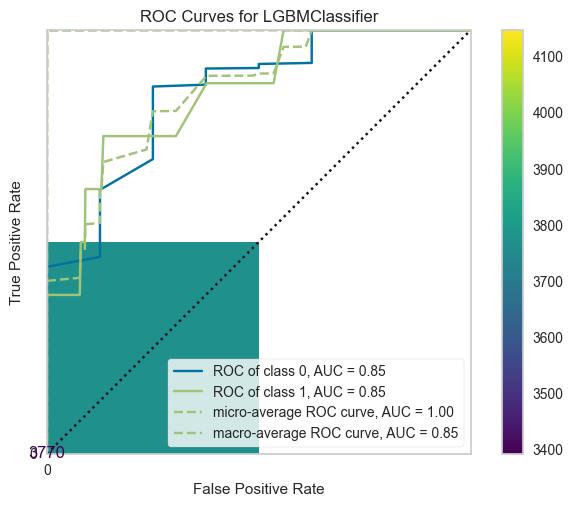

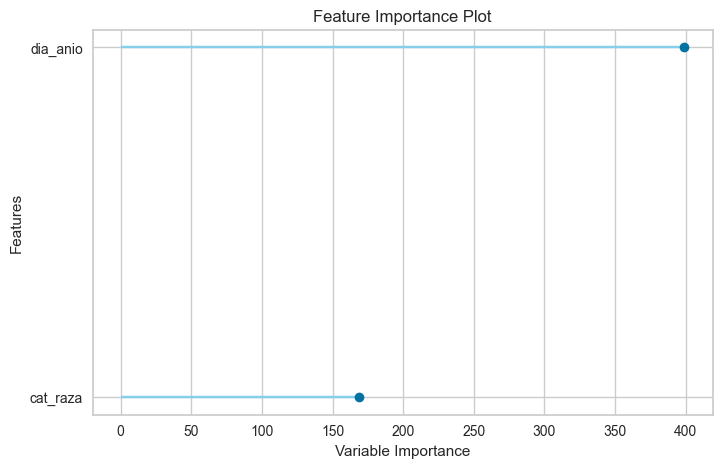

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


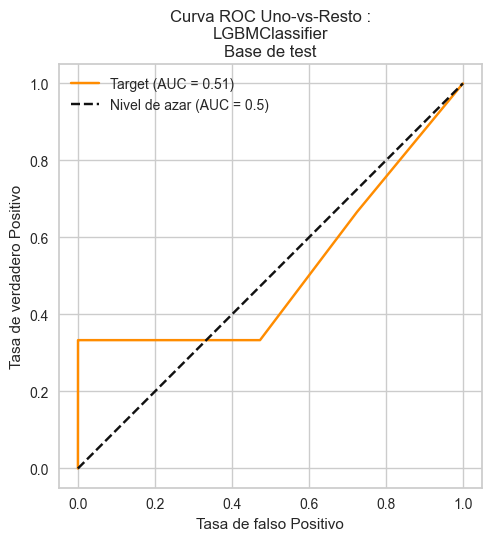

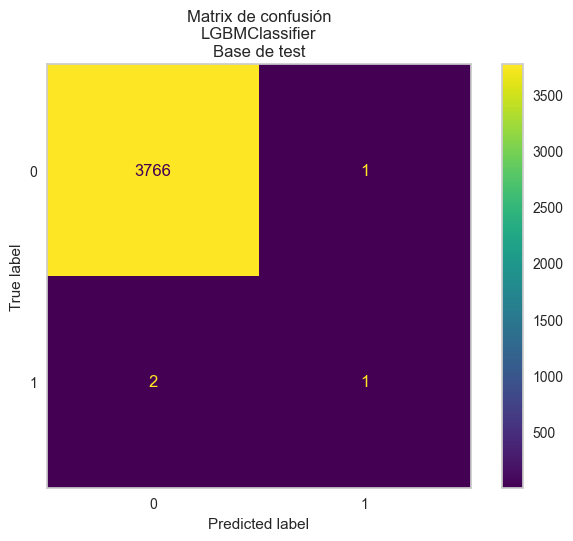

Confusion Matrix : 
 [[3766    1]
 [   2    1]]
Roc_auc_score modelo LGBMClassifier : 0.5126979913282009
GINI a 0.5 auc =  0.02539598265640186
Mejor Threshold: 0.8191 con Youden J statistic: 0.5773 para el modelo sklearn
FPR: 0.0003, TPR: 0.3333


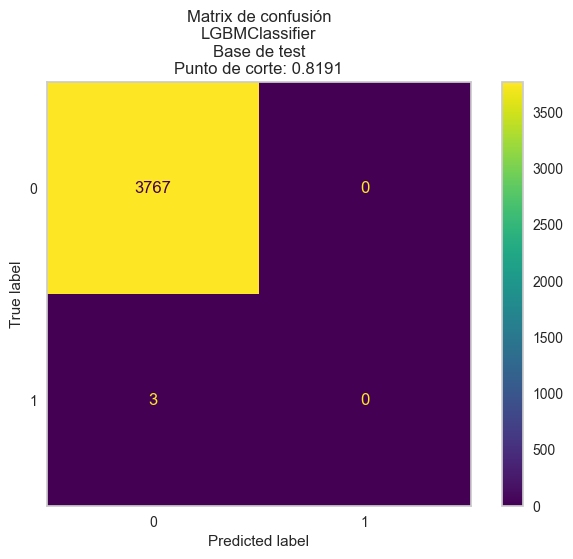

Confusion Matrix : 
 [[3767    0]
 [   3    0]]
KS sklearn a 0.8191: KstestResult(statistic=0.33306787009999117, pvalue=0.7793659449003842, statistic_location=0.1115, statistic_sign=1)
#############################################
#############################################
comienza: Bronquitis Aguda
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20614, 3)"
5,Transformed train set shape,"(14205, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.9998,0.1316,0.0000,0.0000,0.0000,nan,0.0000,0.1040
knn,K Neighbors Classifier,0.9998,0.1000,0.0000,0.0000,0.0000,nan,0.0000,0.1480
dt,Decision Tree Classifier,0.9998,0.1000,0.0000,0.0000,0.0000,nan,0.0000,0.1080
et,Extra Trees Classifier,0.9997,0.1000,0.0000,0.0000,0.0000,nan,0.0000,0.1910
dummy,Dummy Classifier,0.9998,0.1000,0.0000,0.0000,0.0000,nan,0.0000,0.1030
rf,Random Forest Classifier,0.9998,0.0999,0.0000,0.0000,0.0000,nan,0.0000,0.2160
lr,Logistic Regression,0.9998,0.0952,0.0000,0.0000,0.0000,nan,0.0000,0.1030
lda,Linear Discriminant Analysis,0.9998,0.0941,0.0000,0.0000,0.0000,nan,0.0000,0.0980
svm,SVM - Linear Kernel,0.9998,0.0938,0.0000,0.0000,0.0000,nan,0.0000,0.1040
gbc,Gradient Boosting Classifier,0.9997,0.0877,0.0000,0.0000,0.0000,nan,-0.0001,0.2570


                                    Model  Accuracy     AUC  Recall  Prec.  \
nb                            Naive Bayes    0.9998  0.1316     0.0    0.0   
knn                K Neighbors Classifier    0.9998  0.1000     0.0    0.0   
dt               Decision Tree Classifier    0.9998  0.1000     0.0    0.0   
et                 Extra Trees Classifier    0.9997  0.1000     0.0    0.0   
dummy                    Dummy Classifier    0.9998  0.1000     0.0    0.0   
rf               Random Forest Classifier    0.9998  0.0999     0.0    0.0   
lr                    Logistic Regression    0.9998  0.0952     0.0    0.0   
lda          Linear Discriminant Analysis    0.9998  0.0941     0.0    0.0   
svm                   SVM - Linear Kernel    0.9998  0.0938     0.0    0.0   
gbc          Gradient Boosting Classifier    0.9997  0.0877     0.0    0.0   
qda       Quadratic Discriminant Analysis    0.8999  0.0684     0.0    0.0   
lightgbm  Light Gradient Boosting Machine    0.9936  0.0620     

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.8164,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
8,0.9987,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: GaussianNB
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.8164     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
8       0.9987  0.5000     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.1316     0.0    0.0  0.0    NaN  0.0
Std     0.0004  0.2726     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.8164,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
8,0.9987,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.8164     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
8       0.9987  0.5000     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.1316     0.0    0.0  0.0    NaN  0.0
Std     0.0004  0.2726     0.0    0.0  0.0    NaN  0.0


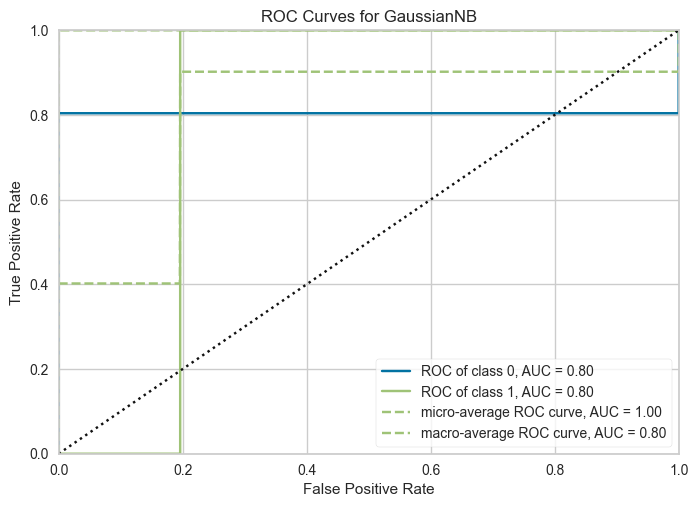

falló gráfico


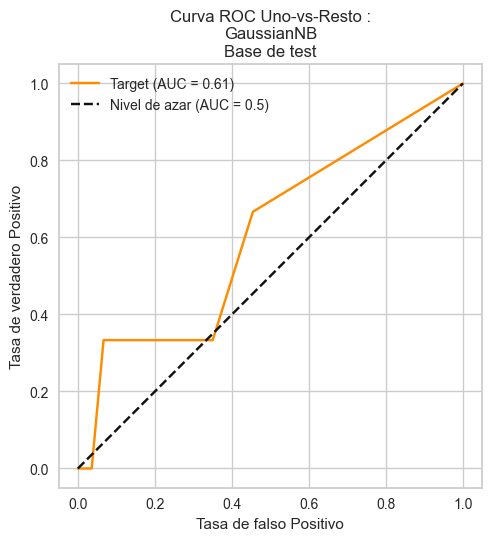

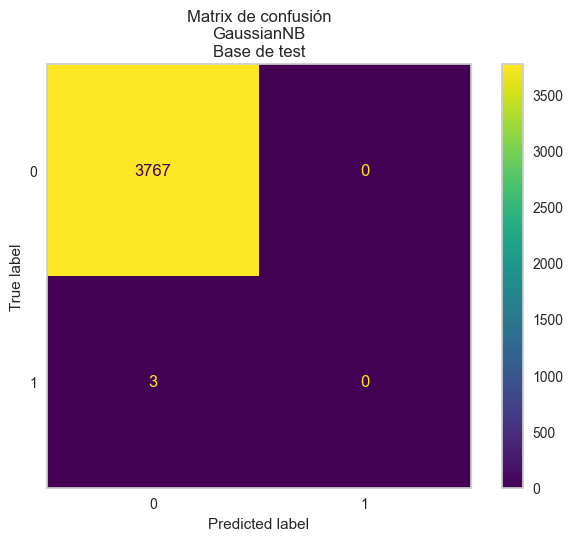

Confusion Matrix : 
 [[3767    0]
 [   3    0]]
Roc_auc_score modelo GaussianNB : 0.6064065126979914
GINI a 0.5 auc =  0.2128130253959828
Mejor Threshold: 0.0009 con Youden J statistic: 0.5578 para el modelo sklearn
FPR: 0.0666, TPR: 0.3333


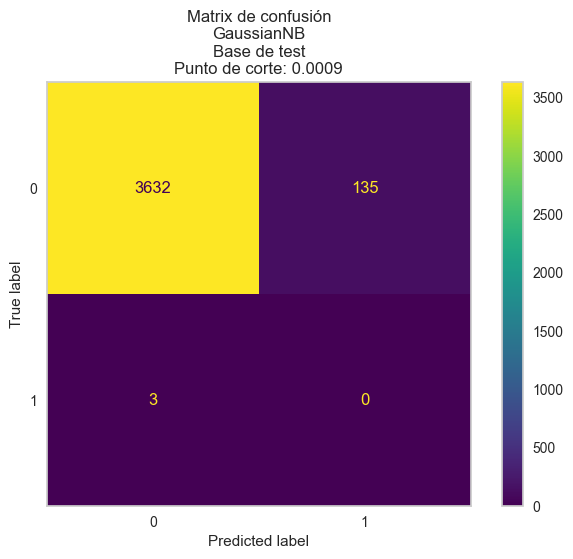

Confusion Matrix : 
 [[3632  135]
 [   3    0]]
KS sklearn a 0.0009: KstestResult(statistic=0.2667020617644456, pvalue=0.952089117896081, statistic_location=0.0008, statistic_sign=1)
#############################################
#############################################
comienza: Estenosis Traqueal
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20614, 3)"
5,Transformed train set shape,"(14205, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9998,0.2487,0.0000,0.0000,0.0000,nan,0.0000,0.2130
lightgbm,Light Gradient Boosting Machine,0.9998,0.2352,0.0000,0.0000,0.0000,nan,0.0000,0.2420
nb,Naive Bayes,0.6134,0.2157,0.2000,0.0003,0.0007,0.0003,0.0060,0.1000
gbc,Gradient Boosting Classifier,0.9985,0.1626,0.0000,0.0000,0.0000,nan,-0.0002,0.2670
dummy,Dummy Classifier,0.9998,0.1500,0.0000,0.0000,0.0000,nan,0.0000,0.1090
knn,K Neighbors Classifier,0.9998,0.1499,0.0000,0.0000,0.0000,nan,0.0000,0.1460
dt,Decision Tree Classifier,0.9998,0.1496,0.0000,0.0000,0.0000,nan,0.0000,0.1000
et,Extra Trees Classifier,0.9998,0.1496,0.0000,0.0000,0.0000,nan,0.0000,0.2090
rf,Random Forest Classifier,0.9998,0.1495,0.0000,0.0000,0.0000,nan,0.0000,0.2100
svm,SVM - Linear Kernel,0.9998,0.1332,0.0000,0.0000,0.0000,nan,0.0000,0.1060


                                    Model  Accuracy     AUC  Recall   Prec.  \
ada                  Ada Boost Classifier    0.9998  0.2487     0.0  0.0000   
lightgbm  Light Gradient Boosting Machine    0.9998  0.2352     0.0  0.0000   
nb                            Naive Bayes    0.6134  0.2157     0.2  0.0003   
gbc          Gradient Boosting Classifier    0.9985  0.1626     0.0  0.0000   
dummy                    Dummy Classifier    0.9998  0.1500     0.0  0.0000   
knn                K Neighbors Classifier    0.9998  0.1499     0.0  0.0000   
dt               Decision Tree Classifier    0.9998  0.1496     0.0  0.0000   
et                 Extra Trees Classifier    0.9998  0.1496     0.0  0.0000   
rf               Random Forest Classifier    0.9998  0.1495     0.0  0.0000   
svm                   SVM - Linear Kernel    0.9998  0.1332     0.0  0.0000   
lr                    Logistic Regression    0.9998  0.1327     0.0  0.0000   
lda          Linear Discriminant Analysis    0.9998 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.7043,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,0.9993,0.8799,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9993,0.9029,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: AdaBoostClassifier
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.7043     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       0.9993  0.8799     0.0    0.0  0.0    0.0  0.0
8       0.9993  0.9029     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.2487     0.0    0.0  0.0    NaN  0.0
Std     0.0003  0.3830     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.3759,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,0.9993,0.6630,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9993,0.8173,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.3759     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       0.9993  0.6630     0.0    0.0  0.0    0.0  0.0
8       0.9993  0.8173     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.1856     0.0    0.0  0.0    NaN  0.0
Std     0.0003  0.3007     0.0    0.0  0.0    NaN  0.0


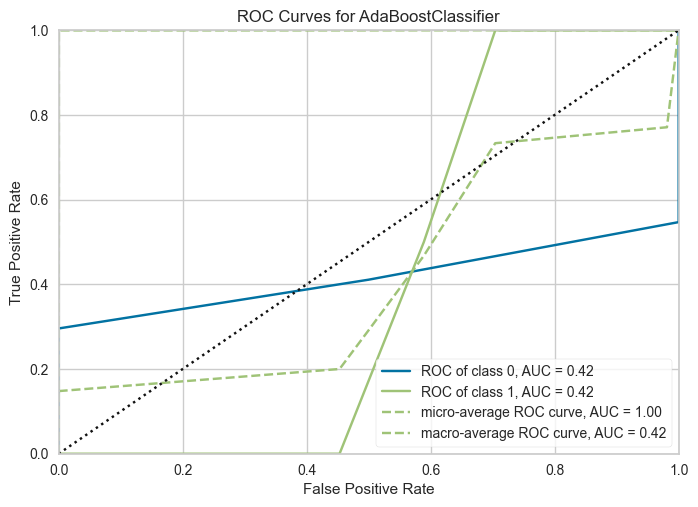

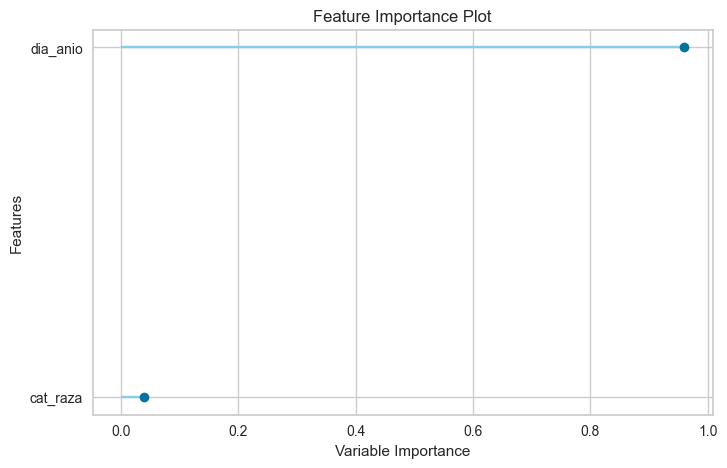

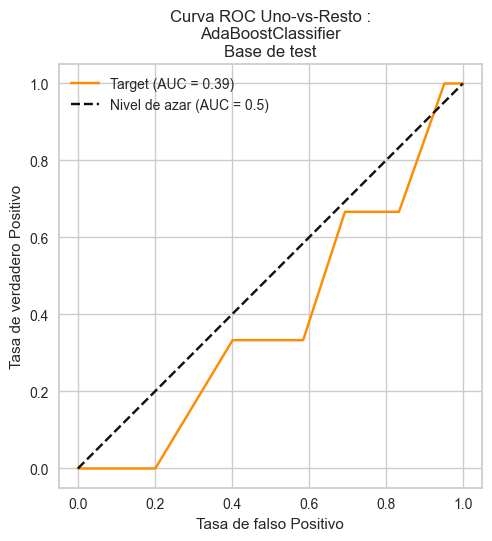

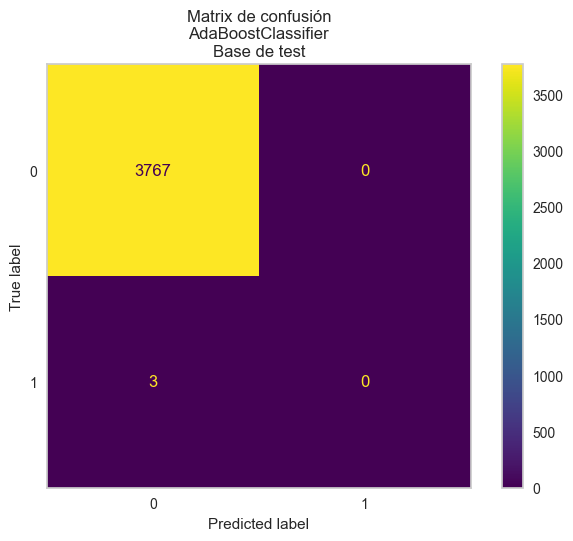

Confusion Matrix : 
 [[3767    0]
 [   3    0]]
Roc_auc_score modelo AdaBoostClassifier : 0.38877090522962565
GINI a 0.5 auc =  -0.2224581895407487
Mejor Threshold: 0.1799 con Youden J statistic: 0.2192 para el modelo sklearn
FPR: 0.952, TPR: 1.0


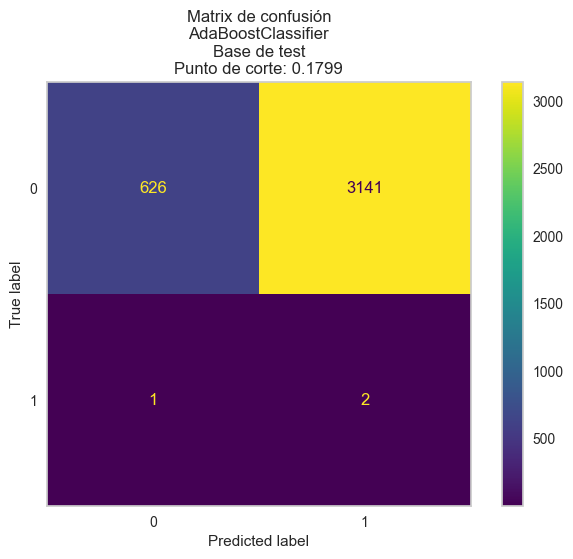

Confusion Matrix : 
 [[ 626 3141]
 [   1    2]]
KS sklearn a 0.1799: KstestResult(statistic=0.25174763295283603, pvalue=0.9705307623127276, statistic_location=0.2585, statistic_sign=-1)
#############################################
#############################################
comienza: Enfermedad Renal Crónica (ERC) Estadio III
#############################################


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(21362, 3)"
4,Transformed data shape,"(20615, 3)"
5,Transformed train set shape,"(14206, 3)"
6,Transformed test set shape,"(6409, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9998,0.2828,0.0000,0.0000,0.0000,nan,0.0000,0.1770
gbc,Gradient Boosting Classifier,0.9993,0.2500,0.2000,0.0367,0.0619,nan,0.0854,0.2160
dt,Decision Tree Classifier,0.9997,0.2497,0.0000,0.0000,0.0000,nan,0.0000,0.0960
rf,Random Forest Classifier,0.9998,0.2497,0.0000,0.0000,0.0000,nan,0.0000,0.2120
et,Extra Trees Classifier,0.9997,0.2497,0.0000,0.0000,0.0000,nan,0.0000,0.1840
lr,Logistic Regression,0.9998,0.2262,0.0000,0.0000,0.0000,nan,0.0000,0.1100
lda,Linear Discriminant Analysis,0.9998,0.2260,0.0000,0.0000,0.0000,nan,0.0000,0.1110
nb,Naive Bayes,0.9995,0.2249,0.0000,0.0000,0.0000,nan,-0.0001,0.1010
svm,SVM - Linear Kernel,0.9998,0.2247,0.0000,0.0000,0.0000,nan,0.0000,0.1020
qda,Quadratic Discriminant Analysis,0.7983,0.1999,0.3000,0.0834,0.1168,0.1166,0.1284,0.0980


                                    Model  Accuracy     AUC  Recall   Prec.  \
ada                  Ada Boost Classifier    0.9998  0.2828     0.0  0.0000   
gbc          Gradient Boosting Classifier    0.9993  0.2500     0.2  0.0367   
dt               Decision Tree Classifier    0.9997  0.2497     0.0  0.0000   
rf               Random Forest Classifier    0.9998  0.2497     0.0  0.0000   
et                 Extra Trees Classifier    0.9997  0.2497     0.0  0.0000   
lr                    Logistic Regression    0.9998  0.2262     0.0  0.0000   
lda          Linear Discriminant Analysis    0.9998  0.2260     0.0  0.0000   
nb                            Naive Bayes    0.9995  0.2249     0.0  0.0000   
svm                   SVM - Linear Kernel    0.9998  0.2247     0.0  0.0000   
qda       Quadratic Discriminant Analysis    0.7983  0.1999     0.3  0.0834   
lightgbm  Light Gradient Boosting Machine    0.9862  0.1791     0.0  0.0000   
dummy                    Dummy Classifier    0.9998 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.8294,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,0.9993,0.9997,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9993,0.9993,0.0000,0.0000,0.0000,0.0000,0.0000


modelo seleccionado: AdaBoostClassifier
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.8294     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       0.9993  0.9997     0.0    0.0  0.0    0.0  0.0
8       0.9993  0.9993     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.2828     0.0    0.0  0.0    NaN  0.0
Std     0.0003  0.4343     0.0    0.0  0.0    NaN  0.0


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9993,0.8803,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
5,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
6,1.0000,0.0000,0.0000,0.0000,0.0000,nan,0.0000
7,0.9993,0.9983,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9993,0.9983,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                                  
0       0.9993  0.8803     0.0    0.0  0.0    0.0  0.0
1       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
2       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
3       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
4       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
5       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
6       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
7       0.9993  0.9983     0.0    0.0  0.0    0.0  0.0
8       0.9993  0.9983     0.0    0.0  0.0    0.0  0.0
9       1.0000  0.0000     0.0    0.0  0.0    NaN  0.0
Mean    0.9998  0.2877     0.0    0.0  0.0    NaN  0.0
Std     0.0003  0.4405     0.0    0.0  0.0    NaN  0.0


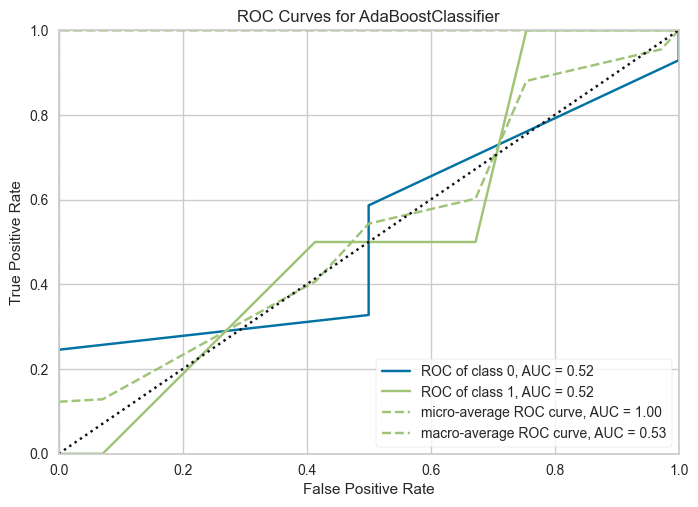

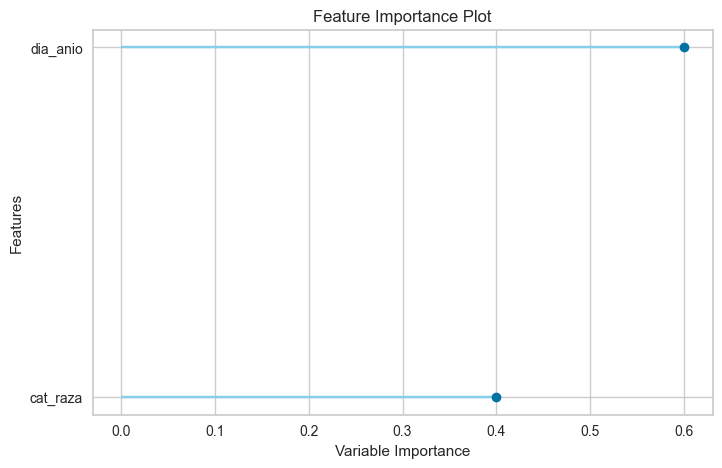

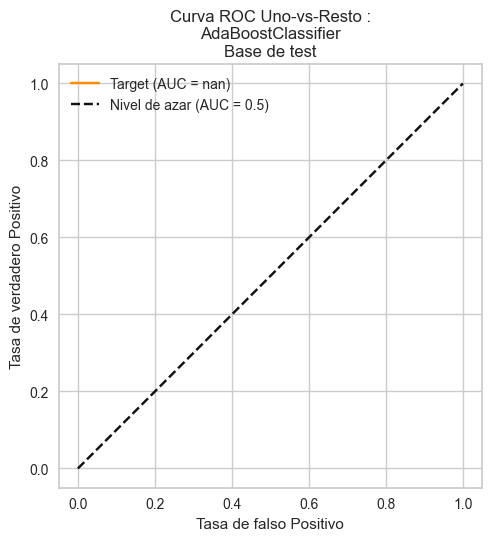

#############################################


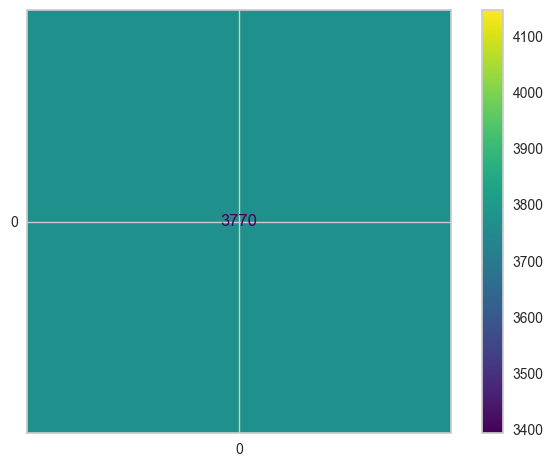

In [33]:
for k in resultados["enfermedad"].unique():
    try:
        df2["target"]=0
        df2["target"].loc[df2["enfermedades"]==k]=1
        print("#############################################")  
        print("comienza: " + k)
        print("#############################################")
        try: 
            res=optimizar(df2[cols],  df2["target"])
        except:
            pass
        resultados=[ "confusion_nn.png", "confusion_nn_opt.png", "confusion_sklearn.png", "confusion_sklearn_opt.png",
        "KS_nn_opt.png", "KS_sklearn_opt.png", "modelo_NN.h5", "modelo_optimizado_sklearn.pkl",
        "ROC_nn.png", "ROC_sklearn.png", "std_scaler_NN.bin"]
        for j in resultados:
            try:
                os.remove(k+"_"+j)
                os.rename(j, k+"_"+j)
            except:
                pass 
        print("#############################################")
    except:
        print("error: " + k)
        pass